# Invoice Audit — Meridian Health Assurance Group

Five hospitals bill a health insurer under five separately negotiated contracts.
Some invoices are wrong. Identify them, state what each should have totalled, and
say how confident you are.

**Scale.** 4,886 invoices, 61,211 line items, five contracts totalling 57,600 tokens.
Hospital 1 is labelled and used only for development. Hospitals 2–5 are scored.

**Result.** Precision 1.000, recall 1.000 on the development set across all eighteen
error categories, with expected totals exact on 909 of 913 invoices.

---

### Design

A language model reads English. Python does arithmetic. No value a model produces is
used until the deterministic engine reproduces the invoice totals from it.

| | |
|---|---|
| Four tabular contracts | parsed by regex |
| One prose contract (hospital 2) | extracted by a language model |
| 61,211 line items repriced | deterministic engine |
| Description → service resolution | contract-derived price index |
| Model selection | measured against a gold spec built for free |

### Contents

| | |
|---|---|
| 0 | Environment and package |
| 1 | Data |
| 2 | Checks requiring no contract |
| 3 | Reading the contracts |
| 4 | Resolving descriptions to services |
| 5 | Repricing engine |
| 6 | Evaluation on hospital 1 |
| 7 | Model selection |
| 8 | Hospital 2 |
| 9 | Submission |

---

## 0 · Setup

Three cells: locate the data, write the `src/` package, import everything.

The notebook builds the package it imports, so a fresh Colab session — which
downloads the notebook and nothing else — reproduces the whole project. The modules
themselves are best read as files in `src/`.

In [1]:
import os, sys, subprocess

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    if not os.path.exists('/content/insurance_auditing'):
        subprocess.run(['git', 'clone', '--depth', '1',
                        'https://github.com/majedzahrani3/insurance_auditing.git',
                        '/content/insurance_auditing'], check=True)
    PROJECT, DATA = '/content', '/content/insurance_auditing'
else:
    PROJECT = os.path.abspath('..')
    DATA = os.path.join(PROJECT, 'data')

for _folder in ('src', 'prompts', 'reports', 'runs'):
    os.makedirs(os.path.join(PROJECT, _folder), exist_ok=True)
if PROJECT not in sys.path:
    sys.path.insert(0, PROJECT)
os.chdir(PROJECT)

print(f'colab {IN_COLAB}   project {PROJECT}   data {DATA}')

colab False   project /Users/saudimaldini/Downloads/invoice-audit   data /Users/saudimaldini/Downloads/invoice-audit/data


In [ ]:
# Version floors, not pins: Colab runs Python 3.13 and older pinned releases have
# no wheel for it, so pip falls back to compiling tokenizers from Rust and fails.
# bitsandbytes is floored at the version current transformers requires for 4-bit.
if IN_COLAB:
    !pip install -q -U 'transformers>=4.46' 'accelerate>=1.0' 'bitsandbytes>=0.46.1' 'sentence-transformers>=3.1' 'outlines>=0.1' 'lm-format-enforcer>=0.10'
    print('\nRuntime > Restart session if this was the first install, then Run all.')

In [ ]:
# Package source. The notebook builds the src/ package it imports, so a fresh Colab
# session -- which downloads the notebook and nothing else -- reproduces the project.
# Read the modules as files in src/, not here. Collapse this cell.

PACKAGE = {
    "src/config.py": "\"\"\"Project-wide paths and constants.\n\nEvery monetary amount in this project is an integer number of cents.\nThere are no floats anywhere in the financial path \u2014 see `audit_engine`.\n\"\"\"\n\nfrom pathlib import Path\n\n# Resolve the repository root from this file, so the code runs identically\n# from a local clone and from a Colab checkout.\nROOT = Path(__file__).resolve().parents[1]\nDATA = ROOT / \"data\"\nCONTRACTS = DATA / \"contracts\"\nINVOICES = DATA / \"invoices\"\nLABELS = DATA / \"labels\"\nREPORTS = ROOT / \"reports\"\n\nHOSPITALS = [\"hospital_1\", \"hospital_2\", \"hospital_3\", \"hospital_4\", \"hospital_5\"]\nDEV_HOSPITAL = \"hospital_1\"            # labelled; used for development only\nSCORED_HOSPITALS = HOSPITALS[1:]       # hospitals 2-5 go in the submission\n\n# The 18 error categories used by the hospital_1 label file. We reuse this\n# vocabulary verbatim rather than inventing our own, so that per-category\n# performance on the development set is directly reportable.\nERROR_CATEGORIES = [\n    # --- detectable with no contract at all -------------------------------\n    \"line_total_arithmetic\",\n    \"invoice_total_mismatch\",\n    \"duplicate_invoice_id\",\n    \"cross_invoice_duplicate\",\n    \"service_date_after_invoice_date\",\n    \"malformed_service_date\",\n    # --- need only the contract header ------------------------------------\n    \"service_date_out_of_window\",\n    \"contract_number_mismatch\",\n    # --- need the rate table ----------------------------------------------\n    \"unit_price_mismatch\",\n    \"wrong_unit_basis\",\n    \"unknown_service\",\n    \"daily_cap_exceeded\",\n    # --- need the contract rules ------------------------------------------\n    \"premium_incorrectly_applied\",\n    \"premium_omitted\",\n    \"volume_discount_incorrectly_applied\",\n    \"volume_discount_omitted\",\n    \"bundle_not_applied\",\n    \"exclusion_window_violation\",\n]\n\n# Unit bases as written in contracts -> as written on invoices.\nUNIT_BASIS = {\n    \"per hour\": \"per_hour\",\n    \"per day of service\": \"per_day\",\n    \"per visit\": \"per_visit\",\n    \"per procedure\": \"per_procedure\",\n    \"per test\": \"per_test\",\n    \"per item supplied\": \"per_item\",\n    \"per night of occupancy\": \"per_night\",\n    \"per unit dispensed\": \"per_unit_dispensed\",\n    \"per hour, per item\": \"per_hour_per_item\",   # compound basis; absent from hospital_1\n}\n",
    "src/money.py": "\"\"\"Exact monetary arithmetic.\n\nAll contracts require half-up rounding to the cent after each adjustment step,\nnot once at the end. Decimal throughout; float is never used for money.\n\"\"\"\n\nfrom decimal import Decimal, ROUND_HALF_UP\n\nONE = Decimal(1)\n\n\ndef half_up(value):\n    \"\"\"Round a Decimal to the nearest whole cent, halves away from zero.\"\"\"\n    return int(Decimal(value).quantize(Decimal(1), rounding=ROUND_HALF_UP))\n\n\ndef apply(cents, factor):\n    \"\"\"One adjustment step: multiply and round half-up immediately.\"\"\"\n    return half_up(Decimal(cents) * Decimal(factor))\n\n\ndef uplift(cents, fraction):\n    \"\"\"Apply a premium of `fraction` (0.20 -> +20%).\"\"\"\n    return apply(cents, ONE + Decimal(fraction))\n\n\ndef discount(cents, fraction):\n    \"\"\"Apply a discount of `fraction` (0.10 -> -10%).\"\"\"\n    return apply(cents, ONE - Decimal(fraction))\n",
    "src/markdown_tables.py": "\"\"\"Read tables from the tabular contracts.\n\nColumns are matched by header text rather than position, since contracts order the\nsame columns differently.\n\"\"\"\n\nimport re\nfrom decimal import Decimal\n\n_HEADING = re.compile(r\"^#{2,3}\\s+(.*)$\", re.M)\n\n\ndef sections(text):\n    \"\"\"{heading: body} for every '##' or '###' heading in the document.\"\"\"\n    marks = [(m.start(), m.group(1).strip()) for m in _HEADING.finditer(text)]\n    out = {}\n    for i, (pos, title) in enumerate(marks):\n        end = marks[i + 1][0] if i + 1 < len(marks) else len(text)\n        out[title] = text[pos:end]\n    return out\n\n\ndef table(body):\n    \"\"\"Every data row of the markdown table(s) in `body`, as lists of cells.\n\n    The header row and the `|---|` separator are dropped. A cell of '\u2014' (the\n    em dash the contracts use for \"not applicable\") becomes None.\n    \"\"\"\n    rows, header = [], None\n    for line in body.splitlines():\n        line = line.strip()\n        if not line.startswith(\"|\"):\n            continue\n        if set(line) <= set(\"|-: \"):\n            continue\n        cells = [c.strip() for c in line.strip(\"|\").split(\"|\")]\n        if header is None:\n            header = cells                    # first row of a table is its header\n            continue\n        rows.append([None if c in {\"\u2014\", \"-\", \"\"} else c for c in cells])\n    return rows, header\n\n\ndef columns(rows, header, *names):\n    \"\"\"Pull named columns out of a table by header text, not by position.\n\n    Hospital 1's bundle table is `Service A | Service B | Rate A | Rate B`; hospital 5's\n    is `Service A | Rate A | Service B | Rate B`. Reading by position silently swaps a\n    service name for a price. Reading by header does not, and fails loudly if a column\n    is missing.\n\n    A name may list alternatives separated by `|`, because the five contracts label the\n    same column differently -- \"Not billable within\" and \"Window\" both mean the length\n    of an exclusion window. The first alternative that matches wins.\n    \"\"\"\n    idx = []\n    for want in names:\n        chosen = None\n        for alt in want.split(\"|\"):\n            matches = [i for i, h in enumerate(header) if alt.lower() in h.lower()]\n            if matches:\n                chosen = matches[0]\n                break\n        if chosen is None:\n            raise KeyError(f\"none of {want.split('|')!r} found in {header}\")\n        idx.append(chosen)\n    return [[r[i] for i in idx] for r in rows]\n\n\ndef decimal_val(text):\n    \"\"\"'1.08' -> Decimal('1.08'). Via str, never via float.\"\"\"\n    return Decimal(str(text).strip())\n\n\ndef find(secs, *keywords):\n    \"\"\"The body of the first section whose heading contains all keywords.\"\"\"\n    for title, body in secs.items():\n        low = title.lower()\n        if all(k.lower() in low for k in keywords):\n            return body\n    return None\n\n\ndef cents(text):\n    \"\"\"'GBP 1,301.25' -> 130125. Exact: parsed as Decimal, never as float.\"\"\"\n    digits = re.sub(r\"[^0-9.]\", \"\", text)\n    return int((Decimal(digits) * 100).to_integral_value())\n\n\ndef fraction(text):\n    \"\"\"'+20%' -> 0.20, '12%' -> 0.12. Returned as Decimal for exact arithmetic.\"\"\"\n    return Decimal(re.sub(r\"[^0-9.]\", \"\", text)) / Decimal(100)\n\n\ndef quantity(text):\n    \"\"\"'6 days', 'more than 10 items', '8 visits' -> 6, 10, 8.\"\"\"\n    m = re.search(r\"(\\d+)\", text)\n    return int(m.group(1)) if m else None\n",
    "src/contract_spec.py": "\"\"\"The contract representation every compiler produces.\n\nPlain dicts, so a spec is printable, comparable and JSON-serialisable \u2014 required for\ndiffing a model's extraction against a regex-built one.\n\"\"\"\n\n\ndef new_rate(cents, valid_from=None, valid_to=None):\n    \"\"\"A rate, optionally bounded in time.\n\n    Hospital 3's Amendment No. 1 substitutes rates from 1 January 2025 *by service\n    date*, so one service can hold several non-overlapping rates.\n    \"\"\"\n    return {\"cents\": int(cents), \"valid_from\": valid_from, \"valid_to\": valid_to}\n\n\ndef rate_covers(rate, on):\n    \"\"\"Is this rate in force on the given date?\"\"\"\n    if on is None:\n        return rate[\"valid_from\"] is None and rate[\"valid_to\"] is None\n    return ((rate[\"valid_from\"] is None or on >= rate[\"valid_from\"])\n            and (rate[\"valid_to\"] is None or on <= rate[\"valid_to\"]))\n\n\ndef rate_on(service, service_date):\n    \"\"\"The contracted rate in force for a service on a date, or None.\"\"\"\n    for rate in service[\"rates\"]:\n        if rate_covers(rate, service_date):\n            return rate[\"cents\"]\n    # A rate with no date bounds always applies; fall back to it.\n    for rate in service[\"rates\"]:\n        if rate[\"valid_from\"] is None and rate[\"valid_to\"] is None:\n            return rate[\"cents\"]\n    return None\n\n\ndef new_service(name, unit_basis, rates, daily_cap=None):\n    return {\"name\": name, \"unit_basis\": unit_basis, \"rates\": rates, \"daily_cap\": daily_cap}\n\n\ndef new_spec(hospital, contract_number, effective_from, effective_to):\n    \"\"\"An empty contract spec, ready for a compiler to fill.\"\"\"\n    return {\n        \"hospital\": hospital,\n        \"contract_number\": contract_number,\n        \"effective_from\": effective_from,\n        \"effective_to\": effective_to,\n        \"services\": {},               # name -> service dict\n        \"threshold_premiums\": {},     # name -> (threshold_qty, uplift_fraction)\n        \"nbd_uplifts\": {},            # name -> uplift_fraction\n        \"volume_discounts\": {},       # name -> [(threshold, fraction), ...] deepest first\n        \"bundles\": [],                # [(service_a, service_b, rate_a, rate_b), ...]\n        \"exclusions\": [],             # [(service, days, other_service), ...]\n        \"facility_multipliers\": {},   # name -> {facility_code: multiplier}\n        \"tier_multipliers\": {},       # name -> {plan_tier: multiplier}\n        \"provenance\": {},             # rule family -> where it came from\n        \"warnings\": [],               # anything we could not read cleanly\n    }\n\n\ndef bundle_partner(spec, service):\n    \"\"\"The service that must co-occur for a bundled rate, and the substituted rate.\"\"\"\n    for a, b, rate_a, rate_b in spec[\"bundles\"]:\n        if service == a:\n            return b, rate_a\n        if service == b:\n            return a, rate_b\n    return None, None\n\n\ndef summarise(spec):\n    \"\"\"One row describing a compiled spec, for eyeballing that it read correctly.\"\"\"\n    return {\n        \"hospital\": spec[\"hospital\"],\n        \"contract\": spec[\"contract_number\"],\n        \"services\": len(spec[\"services\"]),\n        \"priced_periods\": sum(len(s[\"rates\"]) for s in spec[\"services\"].values()),\n        \"daily_caps\": sum(s[\"daily_cap\"] is not None for s in spec[\"services\"].values()),\n        \"threshold_premiums\": len(spec[\"threshold_premiums\"]),\n        \"nbd_uplifts\": len(spec[\"nbd_uplifts\"]),\n        \"volume_discounts\": len(spec[\"volume_discounts\"]),\n        \"bundles\": len(spec[\"bundles\"]),\n        \"exclusions\": len(spec[\"exclusions\"]),\n        \"facility_multipliers\": len(spec[\"facility_multipliers\"]),\n        \"tier_multipliers\": len(spec[\"tier_multipliers\"]),\n        \"warnings\": len(spec[\"warnings\"]),\n    }\n",
    "src/contract_header.py": "\"\"\"Contract number and term, read by regex from the document header.\"\"\"\n\nimport glob\nimport os\nimport re\nfrom datetime import datetime\n\nNUMBER = re.compile(r'\\*\\*Contract number:\\*\\*\\s*(\\S+)')\nFROM   = re.compile(r'\\*\\*Effective from:\\*\\*\\s*(.+)')\nTO     = re.compile(r'\\*\\*Effective to:\\*\\*\\s*(.+)')\n\n\ndef read_header(data_root, hospital):\n    \"\"\"Return {contract_number, effective_from, effective_to} for one hospital.\n\n    Hospital 3's contract is three documents. Each repeats the same header, so we\n    read them all and require agreement \u2014 a disagreement becomes an error rather\n    than a silent first-match win.\n    \"\"\"\n    docs = sorted(glob.glob(f'{data_root}/contracts/{hospital}/*.md'))\n    seen = set()\n    for path in docs:\n        text = open(path).read()\n        num, frm, to = NUMBER.search(text), FROM.search(text), TO.search(text)\n        if not (num and frm and to):\n            continue\n        seen.add((num.group(1),\n                  datetime.strptime(frm.group(1).strip(), '%d %B %Y').date(),\n                  datetime.strptime(to.group(1).strip(), '%d %B %Y').date()))\n    if len(seen) != 1:\n        raise ValueError(f'{hospital}: headers disagree across documents: {seen}')\n    number, start, end = seen.pop()\n    return {'contract_number': number, 'effective_from': start,\n            'effective_to': end, 'documents': [os.path.basename(d) for d in docs]}\n",
    "src/data_loader.py": "\"\"\"Load invoice data and reconstruct the invoice key.\n\nMoney is read as integer cents. Dates are parsed non-destructively so unparseable\nvalues remain reportable. `invoice_id` is not unique \u2014 the `line_id` prefix is the\nreal key, and `build_invoice_units` restores it.\n\"\"\"\n\nimport pandas as pd\n\nMONEY = ['invoice_total_cents', 'unit_price_cents', 'line_total_cents']\n\n\ndef load_invoices(data_root, hospital):\n    \"\"\"One row per invoice row (note: not per invoice \u2014 see build_invoice_units).\"\"\"\n    df = pd.read_csv(f'{data_root}/invoices/{hospital}_invoices.csv', dtype=str)\n    df['invoice_total_cents'] = pd.to_numeric(df['invoice_total_cents']).astype('Int64')\n    for c in ['invoice_date', 'admission_date', 'discharge_date']:\n        df[c + '_raw'] = df[c]\n        df[c] = pd.to_datetime(df[c], format='%Y-%m-%d', errors='coerce')\n    return df\n\n\ndef load_line_items(data_root, hospital):\n    \"\"\"One row per line item, sorted the way the contracts require them counted.\n\n    Several rules are defined over line items 'in Service Date order, and where two\n    line items share a Service Date, in ascending order of line identifier'. We sort\n    once here so every later pass inherits that order.\n    \"\"\"\n    df = pd.read_csv(f'{data_root}/invoices/{hospital}_line_items.csv', dtype=str)\n    for c in ['quantity', 'unit_price_cents', 'line_total_cents']:\n        df[c] = pd.to_numeric(df[c]).astype('Int64')\n    df['service_date_raw'] = df['service_date']\n    df['service_date'] = pd.to_datetime(df['service_date'], format='%Y-%m-%d', errors='coerce')\n    df['source_seq'] = df['line_id'].str.split('-').str[1]      # 'H1-L00068-01' -> 'L00068'\n    return df.sort_values(['service_date', 'line_id'], na_position='last').reset_index(drop=True)\n\n\ndef build_invoice_units(invoices, line_items):\n    \"\"\"Attach the real invoice key (`source_seq`) to every invoice row.\n\n    Where an identifier is reused, the rows are paired with their line groups in\n    ascending order of both invoice date and line sequence. That pairing reproduces\n    the stated invoice totals exactly for all five reused identifiers on hospital 1,\n    and the label file always describes the *later* of the pair. So we treat the\n    earlier invoice as legitimate and flag the later one.\n    \"\"\"\n    groups = (line_items.groupby(['invoice_id', 'source_seq'])['line_total_cents']\n                        .sum().reset_index().sort_values(['invoice_id', 'source_seq']))\n    inv = invoices.sort_values(['invoice_id', 'invoice_date']).copy()\n\n    inv['_rank'] = inv.groupby('invoice_id').cumcount()\n    groups['_rank'] = groups.groupby('invoice_id').cumcount()\n    merged = inv.merge(groups[['invoice_id', 'source_seq', '_rank']],\n                       on=['invoice_id', '_rank'], how='left')\n    merged['reuses_id'] = merged['_rank'] > 0\n    return merged.drop(columns='_rank')\n\n\ndef load_labels(data_root, hospital='hospital_1'):\n    \"\"\"Ground truth for the development hospital. Categories are `|`-separated.\"\"\"\n    df = pd.read_csv(f'{data_root}/labels/{hospital}_labels.csv', dtype=str)\n    df['is_erroneous'] = df['is_erroneous'].astype(int)\n    df['expected_total_cents'] = pd.to_numeric(df['expected_total_cents']).astype('Int64')\n    df['categories'] = df['error_categories'].fillna('').apply(\n        lambda s: [c.strip() for c in s.split('|') if c.strip()])\n    return df\n",
    "src/structural_checks.py": "\"\"\"Checks requiring no rate table.\n\nSeven error categories are arithmetic or calendar facts, or need only the contract\nnumber and term. Operates on invoice units rather than `invoice_id`, which is not\nunique; findings are reported against `invoice_id`, the submission key.\n\"\"\"\n\nimport pandas as pd\n\nCOLUMNS = ['invoice_id', 'category', 'detail']\n\n\ndef _f(rows):\n    return pd.DataFrame(rows, columns=COLUMNS)\n\n\ndef check_line_total_arithmetic(line_items):\n    \"\"\"line_total_cents must equal quantity x unit_price_cents.\"\"\"\n    bad = line_items[line_items['line_total_cents']\n                     != line_items['quantity'] * line_items['unit_price_cents']]\n    return _f([(r.invoice_id, 'line_total_arithmetic',\n                f'{r.line_id}: {r.quantity} x {r.unit_price_cents} = '\n                f'{r.quantity * r.unit_price_cents}, billed {r.line_total_cents}')\n               for r in bad.itertuples()])\n\n\ndef check_invoice_total_mismatch(units, line_items):\n    \"\"\"invoice_total_cents must equal the sum of that unit's line totals as billed.\"\"\"\n    sums = line_items.groupby('source_seq')['line_total_cents'].sum()\n    u = units.assign(line_sum=units['source_seq'].map(sums))\n    bad = u[u['line_sum'].notna() & (u['line_sum'] != u['invoice_total_cents'])]\n    return _f([(r.invoice_id, 'invoice_total_mismatch',\n                f'{r.source_seq}: lines sum to {int(r.line_sum)}, '\n                f'invoice states {r.invoice_total_cents}')\n               for r in bad.itertuples()])\n\n\ndef check_duplicate_invoice_id(units):\n    \"\"\"An invoice identifier may not be reused.\n\n    We flag the *later* invoice of a reused pair, not both: the first use was\n    legitimate. On hospital 1 the label's expected total always describes this later\n    invoice, which is the evidence for that reading.\n    \"\"\"\n    bad = units[units['reuses_id']]\n    return _f([(r.invoice_id, 'duplicate_invoice_id',\n                f'{r.source_seq} dated {r.invoice_date.date()} reuses an identifier '\n                f'already in use')\n               for r in bad.itertuples()])\n\n\ndef check_malformed_service_date(line_items):\n    \"\"\"A service date that does not parse as a real calendar date.\"\"\"\n    bad = line_items[line_items['service_date'].isna()]\n    return _f([(r.invoice_id, 'malformed_service_date', f'{r.line_id}: {r.service_date_raw!r}')\n               for r in bad.itertuples()])\n\n\ndef check_service_date_after_invoice_date(units, line_items, header):\n    \"\"\"A service may not be dated after the invoice that bills it.\n\n    A date outside the contract term is also, usually, after the invoice date. The\n    hospital 1 labels do not double-label these: a service dated 2026-07-24 on an\n    invoice dated 2024-06-02 is labelled `service_date_out_of_window` alone. We follow\n    that precedence and raise this category only for dates inside the term.\n    \"\"\"\n    start, end = pd.Timestamp(header['effective_from']), pd.Timestamp(header['effective_to'])\n    dates = units.set_index('source_seq')['invoice_date']\n    li = line_items.assign(invoice_date=line_items['source_seq'].map(dates))\n    in_term = li['service_date'].between(start, end)\n    bad = li[li['service_date'].notna() & li['invoice_date'].notna() & in_term\n             & (li['service_date'] > li['invoice_date'])]\n    return _f([(r.invoice_id, 'service_date_after_invoice_date',\n                f'{r.line_id}: service {r.service_date.date()} > invoice {r.invoice_date.date()}')\n               for r in bad.itertuples()])\n\n\ndef check_service_date_out_of_window(line_items, header):\n    \"\"\"Every service date must fall inside the contract term.\"\"\"\n    start, end = pd.Timestamp(header['effective_from']), pd.Timestamp(header['effective_to'])\n    sd = line_items['service_date']\n    bad = line_items[sd.notna() & ((sd < start) | (sd > end))]\n    return _f([(r.invoice_id, 'service_date_out_of_window',\n                f'{r.line_id}: {r.service_date.date()} outside {start.date()}..{end.date()}')\n               for r in bad.itertuples()])\n\n\ndef check_contract_number_mismatch(units, header):\n    \"\"\"Each invoice must quote the contract number on the agreement.\"\"\"\n    expected = header['contract_number']\n    bad = units[units['contract_number'] != expected]\n    return _f([(r.invoice_id, 'contract_number_mismatch',\n                f'quotes {r.contract_number!r}, expected {expected!r}')\n               for r in bad.itertuples()])\n\n\ndef run_all(units, line_items, header):\n    \"\"\"Every check, as one row per (invoice_id, category).\"\"\"\n    out = pd.concat([\n        check_line_total_arithmetic(line_items),\n        check_invoice_total_mismatch(units, line_items),\n        check_duplicate_invoice_id(units),\n        check_malformed_service_date(line_items),\n        check_service_date_after_invoice_date(units, line_items, header),\n        check_service_date_out_of_window(line_items, header),\n        check_contract_number_mismatch(units, header),\n    ], ignore_index=True)\n    return out.groupby(['invoice_id', 'category'], as_index=False).agg(\n        detail=('detail', 'first'), n_lines=('detail', 'size'))\n",
    "src/compile_contract.py": "\"\"\"Compile a tabular contract into a spec.\n\nOne compiler per hospital over shared table readers. A rule naming a service absent\nfrom the rate schedule is recorded as a warning, never dropped silently.\n\"\"\"\n\nimport glob\nfrom datetime import date\n\nfrom src.config import UNIT_BASIS\nfrom src.contract_header import read_header\nfrom src.contract_spec import new_spec, new_service, new_rate\nfrom src.markdown_tables import (sections, table, find, columns, cents, fraction,\n                                 quantity, decimal_val)\n\n\ndef _check_known(spec, names, where):\n    \"\"\"Record any service named by a rule table that the rate schedule lacks.\"\"\"\n    for n in names:\n        if n not in spec[\"services\"]:\n            spec[\"warnings\"].append(f\"{where}: unknown service {n!r} not in rate schedule\")\n\n\ndef _read_rule_tables(spec, secs, *, premiums, nbd, discounts, bundles, exclusions,\n                      caps=None):\n    \"\"\"The rule families every contract states, in whatever section it states them.\n\n    Columns are matched by header text rather than by position: hospital 1's bundle\n    table is `Service A | Service B | Rate A | Rate B` while hospital 5's is\n    `Service A | Rate A | Service B | Rate B`. Reading by position would silently swap\n    a service name for a price.\n    \"\"\"\n    body = find(secs, *premiums)\n    if body:\n        rows, hdr = table(body)\n        for name, threshold, uplift in columns(rows, hdr, \"Service\", \"threshold|exceeds\", \"Uplift\"):\n            spec[\"threshold_premiums\"][name] = (quantity(threshold), fraction(uplift))\n\n    body = find(secs, *nbd)\n    if body:\n        rows, hdr = table(body)\n        if rows:\n            for name, uplift in columns(rows, hdr, \"Service\", \"Uplift\"):\n                spec[\"nbd_uplifts\"][name] = fraction(uplift)\n\n    body = find(secs, *discounts)\n    if body:\n        rows, hdr = table(body)\n        for name, threshold, disc in columns(rows, hdr, \"Service\", \"utilisation|exceeds\", \"Discount\"):\n            spec[\"volume_discounts\"].setdefault(name, []).append((quantity(threshold), fraction(disc)))\n        for name in spec[\"volume_discounts\"]:\n            spec[\"volume_discounts\"][name].sort(key=lambda t: -t[0])\n\n    body = find(secs, *bundles)\n    if body:\n        rows, hdr = table(body)\n        for a, b, ra, rb in columns(rows, hdr, \"Service A\", \"Service B\", \"rate A\", \"rate B\"):\n            spec[\"bundles\"].append((a, b, cents(ra), cents(rb)))\n\n    body = find(secs, *exclusions)\n    if body:\n        rows, hdr = table(body)\n        for svc, days, other in columns(rows, hdr, \"Service\", \"within|Window\", \"Of this Service|Excluded by\"):\n            spec[\"exclusions\"].append((svc, quantity(days), other))\n\n    if caps:\n        body = find(secs, *caps)\n        if body:\n            rows, hdr = table(body)\n            for name, cap in columns(rows, hdr, \"Service\", \"Maximum\"):\n                svc = spec[\"services\"].get(name)\n                q = quantity(cap)\n                if svc is None:\n                    spec[\"warnings\"].append(f\"caps: unknown service {name!r}\")\n                elif svc[\"daily_cap\"] is None:\n                    svc[\"daily_cap\"] = q\n                elif svc[\"daily_cap\"] != q:\n                    spec[\"warnings\"].append(\n                        f\"caps: disagrees with rate schedule for {name!r}: {svc['daily_cap']} vs {q}\")\n\n\ndef _validate(spec):\n    _check_known(spec, spec[\"threshold_premiums\"], \"premiums\")\n    _check_known(spec, spec[\"nbd_uplifts\"], \"nbd uplifts\")\n    _check_known(spec, spec[\"volume_discounts\"], \"volume discounts\")\n    _check_known(spec, [n for t in spec[\"bundles\"] for n in t[:2]], \"bundles\")\n    _check_known(spec, [n for t in spec[\"exclusions\"] for n in (t[0], t[2])], \"exclusions\")\n    _check_known(spec, spec[\"facility_multipliers\"], \"facility multipliers\")\n    _check_known(spec, spec[\"tier_multipliers\"], \"tier multipliers\")\n    return spec\n\n\ndef _rate_schedule(spec, body, provenance):\n    \"\"\"A `Service | Unit basis | Rate | Daily cap` table.\"\"\"\n    rows, hdr = table(body)\n    for row in columns(rows, hdr, \"Service\", \"Unit basis\", \"Rate\", \"Daily cap\"):\n        name, basis, rate, cap = row\n        spec[\"services\"][name] = new_service(name, UNIT_BASIS[basis], [new_rate(cents(rate))],\n                                             quantity(cap) if cap else None)\n    spec[\"provenance\"][\"services\"] = provenance\n\n\ndef _doc(data_root, hospital, stem):\n    return open(f\"{data_root}/contracts/{hospital}/{stem}.md\").read()\n\n\n# --------------------------------------------------------------------------\n# hospital 1 - a single document, one table per rule family\n# --------------------------------------------------------------------------\n\ndef compile_hospital_1(data_root, hospital=\"hospital_1\"):\n    hdr = read_header(data_root, hospital)\n    secs = sections(_doc(data_root, hospital, \"provider_services_agreement\"))\n    spec = new_spec(hospital, hdr[\"contract_number\"], hdr[\"effective_from\"], hdr[\"effective_to\"])\n\n    _rate_schedule(spec, find(secs, \"Rate Schedule\"), \"s4 Rate Schedule\")\n    _read_rule_tables(spec, secs,\n                      premiums=(\"Threshold Premiums\",), nbd=(\"Non-Business-Day\",),\n                      discounts=(\"Volume Discounts\",), bundles=(\"Bundled Services\",),\n                      exclusions=(\"Exclusion Windows\",), caps=(\"Daily Quantity Caps\",))\n    spec[\"provenance\"].update({\"premiums\": \"s5\", \"nbd\": \"s6\", \"discounts\": \"s7\",\n                               \"caps\": \"s4 + s8 (cross-checked)\", \"bundles\": \"s9\",\n                               \"exclusions\": \"s10\"})\n    return _validate(spec)\n\n\n# --------------------------------------------------------------------------\n# hospital 3 - three documents, and an amendment that reprices by service date\n# --------------------------------------------------------------------------\n\nAMENDMENT_START = date(2025, 1, 1)\n\ndef compile_hospital_3(data_root, hospital=\"hospital_3\"):\n    \"\"\"Base agreement + Appendix B rates + Amendment No. 1.\n\n    The amendment \"applies by Service Date. A line item whose Service Date falls on or\n    after the effective date is priced under this Amendment; a line item whose Service\n    Date falls before the effective date is priced under Appendix B. The date on which\n    an invoice is issued is irrelevant.\" So an amended service carries two rates, each\n    bounded in time, and the engine picks by service date.\n    \"\"\"\n    hdr = read_header(data_root, hospital)\n    base = sections(_doc(data_root, hospital, \"base_agreement\"))\n    appendix = sections(_doc(data_root, hospital, \"appendix_b_rate_schedule\"))\n    amendment = sections(_doc(data_root, hospital, \"amendment_no_1\"))\n\n    spec = new_spec(hospital, hdr[\"contract_number\"], hdr[\"effective_from\"], hdr[\"effective_to\"])\n    _rate_schedule(spec, find(appendix, \"B.1\", \"Rates\"), \"Appendix B.1 Rates\")\n\n    # A1.2 substitutes rates from 1 Jan 2025; both periods are stated explicitly.\n    rows, h = table(find(amendment, \"Substituted Rates\"))\n    for name, basis, before, after in columns(rows, h, \"Service\", \"Unit basis\",\n                                              \"to 31 December 2024\", \"from 1 January 2025\"):\n        if name not in spec[\"services\"]:\n            spec[\"warnings\"].append(f\"A1.2: substitutes unknown service {name!r}\")\n            continue\n        spec[\"services\"][name][\"rates\"] = [\n            new_rate(cents(before), valid_to=AMENDMENT_START.replace(year=2024, month=12, day=31)),\n            new_rate(cents(after), valid_from=AMENDMENT_START),\n        ]\n\n    # A1.3 adds services that \"are not billable in respect of earlier Service Dates\".\n    rows, h = table(find(amendment, \"Additional Services\"))\n    for name, basis, rate in columns(rows, h, \"Service\", \"Unit basis\", \"Rate\"):\n        spec[\"services\"][name] = new_service(name, UNIT_BASIS[basis],\n                                             [new_rate(cents(rate), valid_from=AMENDMENT_START)])\n    spec[\"provenance\"][\"amendment\"] = \"Amendment No. 1 A1.2/A1.3, applied by service date\"\n\n    _read_rule_tables(spec, base,\n                      premiums=(\"Threshold Premiums\",), nbd=(\"Non-Business-Day\",),\n                      discounts=(\"Volume Discounts\",), bundles=(\"Bundled Services\",),\n                      exclusions=(\"Exclusion Windows\",), caps=(\"Daily Quantity Caps\",))\n    spec[\"provenance\"].update({\"premiums\": \"base s4\", \"nbd\": \"base s5\", \"discounts\": \"base s6\",\n                               \"caps\": \"Appendix B.1 + base s7\", \"bundles\": \"base s8\",\n                               \"exclusions\": \"base s9\"})\n    return _validate(spec)\n\n\n# --------------------------------------------------------------------------\n# hospital 4 - single document; rates carry no cap column, caps are their own table\n# --------------------------------------------------------------------------\n\ndef compile_hospital_4(data_root, hospital=\"hospital_4\"):\n    hdr = read_header(data_root, hospital)\n    secs = sections(_doc(data_root, hospital, \"conditional_reimbursement_agreement\"))\n    spec = new_spec(hospital, hdr[\"contract_number\"], hdr[\"effective_from\"], hdr[\"effective_to\"])\n\n    rows, h = table(find(secs, \"Base Rates\"))\n    for name, basis, rate in columns(rows, h, \"Service\", \"Unit basis\", \"Base rate\"):\n        spec[\"services\"][name] = new_service(name, UNIT_BASIS[basis], [new_rate(cents(rate))])\n    spec[\"provenance\"][\"services\"] = \"s3 Base Rates\"\n\n    _read_rule_tables(spec, secs,\n                      premiums=(\"Threshold Premiums\",), nbd=(\"Non-Business-Day\",),\n                      discounts=(\"Discounts\",), bundles=(\"Bundled Delivery\",),\n                      exclusions=(\"Exclusion Windows\",), caps=(\"Daily Quantity Limits\",))\n    spec[\"provenance\"].update({\"premiums\": \"s5\", \"caps\": \"s6\", \"bundles\": \"s7\",\n                               \"discounts\": \"s8\", \"exclusions\": \"s9\",\n                               \"nbd\": \"s10 (states 'None.')\"})\n    return _validate(spec)\n\n\n# --------------------------------------------------------------------------\n# hospital 5 - a facility x plan-tier multiplier grid over a base rate table\n# --------------------------------------------------------------------------\n\ndef compile_hospital_5(data_root, hospital=\"hospital_5\"):\n    hdr = read_header(data_root, hospital)\n    secs = sections(_doc(data_root, hospital, \"network_reimbursement_agreement\"))\n    spec = new_spec(hospital, hdr[\"contract_number\"], hdr[\"effective_from\"], hdr[\"effective_to\"])\n\n    rows, h = table(find(secs, \"Table 1\"))\n    for name, basis, rate, cap in columns(rows, h, \"Service\", \"Unit basis\", \"Base rate\", \"Daily cap\"):\n        spec[\"services\"][name] = new_service(name, UNIT_BASIS[basis], [new_rate(cents(rate))],\n                                             quantity(cap) if cap else None)\n    spec[\"provenance\"][\"services\"] = \"s4 Table 1\"\n\n    for title, key in ((\"Table 2\", \"facility_multipliers\"), (\"Table 3\", \"tier_multipliers\")):\n        rows, h = table(find(secs, title))\n        names = h[1:]                       # the contract names its own columns\n        for row in rows:\n            spec[key][row[0]] = {k: decimal_val(v) for k, v in zip(names, row[1:])}\n        spec[\"provenance\"][key] = f\"s4 {title}\"\n\n    _read_rule_tables(spec, secs,\n                      premiums=(\"Threshold Premiums\",), nbd=(\"Non-Business-Day\",),\n                      discounts=(\"Volume Discounts\",), bundles=(\"Bundled Services\",),\n                      exclusions=(\"Exclusion Windows\",))\n    spec[\"provenance\"].update({\"premiums\": \"s5\", \"nbd\": \"s6\", \"bundles\": \"s7\",\n                               \"discounts\": \"s8\", \"exclusions\": \"s9\"})\n    return _validate(spec)\n\n\nCOMPILERS = {\n    \"hospital_1\": compile_hospital_1,\n    \"hospital_3\": compile_hospital_3,\n    \"hospital_4\": compile_hospital_4,\n    \"hospital_5\": compile_hospital_5,\n}\n\n\ndef compile_contract(data_root, hospital):\n    \"\"\"Compile one hospital's contract. Hospital 2 is prose and needs `llm_extract`.\"\"\"\n    if hospital not in COMPILERS:\n        raise NotImplementedError(f\"{hospital} has no table-based compiler (it is prose)\")\n    return COMPILERS[hospital](data_root, hospital)\n",
    "src/resolver.py": "\"\"\"Resolve free-text billing descriptions to contracted services.\n\nDescriptions are abbreviated, reordered and suffixed with noise codes, so lexical\nmatching alone is unreliable. A contract can only produce a small enumerable set of\nunit rates, so we match on the modal (unit_basis, unit_price_cents) of each\ndescription instead, and use character n-gram similarity only to break genuine price\ncollisions and to flag descriptions the price identifies but the text contradicts.\n\"\"\"\n\nimport collections\nfrom decimal import Decimal\n\nimport pandas as pd\nfrom sklearn.feature_extraction.text import TfidfVectorizer\nfrom sklearn.metrics.pairwise import cosine_similarity\n\nfrom src.contract_spec import bundle_partner\nfrom src.money import apply, uplift, discount\n\nONE = Decimal(1)\n\n\ndef derivable_prices(spec):\n    \"\"\"Every (unit_basis, unit_price_cents) the contract can legally produce.\n\n    Returns {(basis, cents): {service names}}. A key mapping to more than one\n    service is a genuine price collision and is handed to the text tie-break.\n    \"\"\"\n    index = collections.defaultdict(set)\n    for name, svc in spec[\"services\"].items():\n        _, bundled = bundle_partner(spec, name)\n        facs = list(spec[\"facility_multipliers\"].get(name, {1: ONE}).values()) or [ONE]\n        tiers = list(spec[\"tier_multipliers\"].get(name, {1: ONE}).values()) or [ONE]\n        prem = spec[\"threshold_premiums\"].get(name)\n        nbd = spec[\"nbd_uplifts\"].get(name)\n        discs = [d for _, d in spec[\"volume_discounts\"].get(name, [])]\n\n        starts = [rate[\"cents\"] for rate in svc[\"rates\"]] + ([bundled] if bundled else [])\n        for start in starts:\n            for f in set(facs):\n                a = apply(start, f)\n                for t in set(tiers):\n                    b = apply(a, t)\n                    ups = [b] + ([uplift(b, prem[1])] if prem else []) \\\n                              + ([uplift(b, nbd)] if nbd else [])\n                    for c in ups:\n                        for d in [None] + discs:\n                            price = c if d is None else discount(c, d)\n                            index[(svc[\"unit_basis\"], price)].add(name)\n    return index\n\n\ndef modal_price(line_items):\n    \"\"\"The most common (unit_basis, unit_price_cents) for each description.\n\n    The mode is what makes this robust: an injected error affects a minority of\n    a description's rows, so the majority still carries the contracted rate.\n    That assumption is stated explicitly because it is the one way this method\n    can fail silently \u2014 see the decision log.\n    \"\"\"\n    counts = collections.defaultdict(collections.Counter)\n    for r in line_items.itertuples():\n        counts[r.description][(r.unit_basis_as_billed, int(r.unit_price_cents))] += 1\n    return {d: (c.most_common(1)[0][0], c.most_common(1)[0][1], sum(c.values()))\n            for d, c in counts.items()}\n\n\nclass LexicalMatcher:\n    \"\"\"Character n-gram TF-IDF similarity between descriptions and service names.\n\n    Character n-grams rather than words, because the descriptions abbreviate\n    ('Compr Infectious Nursing' / 'Comprehensive Infectious Nursing Observation')\n    and reorder, both of which destroy word-level overlap but leave most\n    character trigrams intact.\n    \"\"\"\n\n    def __init__(self, service_names):\n        self.names = list(service_names)\n        self.vec = TfidfVectorizer(analyzer=\"char_wb\", ngram_range=(2, 4), lowercase=True)\n        self.matrix = self.vec.fit_transform(self.names)\n\n    def rank(self, description, among=None):\n        \"\"\"(service, score) pairs, best first, optionally restricted to `among`.\"\"\"\n        q = self.vec.transform([description])\n        sims = cosine_similarity(q, self.matrix)[0]\n        pairs = sorted(zip(self.names, sims), key=lambda t: -t[1])\n        if among is not None:\n            allowed = set(among)\n            pairs = [p for p in pairs if p[0] in allowed]\n        return pairs\n\n\n# Thresholds for treating a price match as coincidental rather than an alias.\n# Calibrated on hospital 1; the margin is reported per hospital.\nUNKNOWN_MAX_LEXICAL = 0.20\nUNKNOWN_MAX_ROWS = 2\n\n# Where a price matches more than one service, text decides -- but how decisively it\n# decided is itself information. A tie won by a wide margin is near-certain; one won by\n# a hair is a coin-flip, and reporting both at the same confidence is the failure the\n# task singles out. Confidence follows the margin, and below DECIDED_MIN the\n# description is reported as ambiguous rather than resolved, with both candidates named.\nDECISIVE_MARGIN = 0.30\nDECIDED_MIN = 0.10\n\n\ndef resolve(spec, line_items):\n    \"\"\"Resolve every distinct description to a contracted service.\n\n    Returns one row per description with the method that decided it, the\n    agreement between the two independent signals, and a confidence.\n    \"\"\"\n    index = derivable_prices(spec)\n    modes = modal_price(line_items)\n    lex = LexicalMatcher(spec[\"services\"])\n\n    rows = []\n    for desc, (mode, mode_n, total) in modes.items():\n        candidates = index.get(mode, set())\n        ranked = lex.rank(desc)\n        lex_best, lex_score = ranked[0]\n        margin, runner_up = None, None\n\n        if len(candidates) == 1:\n            service = next(iter(candidates))\n            agrees = service == lex_best\n            method, conf = \"price_unique\", (0.98 if agrees else 0.90)\n        elif len(candidates) > 1:\n            among = lex.rank(desc, among=candidates)\n            service, top_score = among[0]\n            runner_up, second_score = among[1] if len(among) > 1 else (None, 0.0)\n            margin = top_score - second_score\n            agrees = True\n            if margin >= DECISIVE_MARGIN:\n                method, conf = \"price_tiebreak_text\", 0.90\n            elif margin >= DECIDED_MIN:\n                method, conf = \"price_tiebreak_narrow\", 0.70\n            else:\n                # Neither signal separates the candidates. Naming one would be a guess\n                # presented as a finding; the pair is surfaced for review instead.\n                method, conf = \"ambiguous\", 0.40\n        else:\n            service, agrees = None, False\n            method, conf = \"unresolved\", 0.30\n\n        # How well does the text support the service the price picked?\n        chosen_score = float(dict(ranked)[service]) if service else 0.0\n        if (service is not None\n                and chosen_score < UNKNOWN_MAX_LEXICAL\n                and total <= UNKNOWN_MAX_ROWS):\n            service, method, conf = None, \"unknown_service\", 0.90\n\n        rows.append({\n            \"description\": desc, \"service\": service, \"method\": method,\n            \"tiebreak_margin\": round(margin, 3) if len(candidates) > 1 else None,\n            \"runner_up\": runner_up if len(candidates) > 1 else None,\n            \"n_candidates\": len(candidates), \"modal_basis\": mode[0], \"modal_price\": mode[1],\n            \"modal_share\": round(mode_n / total, 3), \"n_rows\": total,\n            \"lexical_best\": lex_best, \"lexical_score\": round(float(lex_score), 3),\n            \"score_of_chosen\": round(chosen_score, 3),\n            \"signals_agree\": agrees, \"confidence\": conf,\n        })\n    return pd.DataFrame(rows).sort_values([\"method\", \"description\"]).reset_index(drop=True)\n",
    "src/audit_engine.py": "\"\"\"Reprice a hospital's line items under its contract.\n\nA single ordered pass. Cumulative volume discounts depend on utilisation prior to\neach line, so invoices are not independent and cannot be parallelised. Per-patient\ndaily quantities, bundle co-occurrence and exclusion windows are precomputed.\n\nAdjustment order, identical across all contracts: bundle substitution, facility\nmultiplier, plan-tier multiplier, premium or uplift, cumulative volume discount,\nwith half-up rounding after each step.\n\"\"\"\n\nimport collections\nfrom decimal import Decimal\n\nimport pandas as pd\n\nfrom src.contract_spec import bundle_partner, rate_on\nfrom src.money import apply, uplift, discount\n\nONE = Decimal(1)\n\n\ndef _attach_context(units, line_items, resolution):\n    \"\"\"Give every line item its service, patient, facility and plan tier.\"\"\"\n    li = line_items.copy()\n    li[\"service\"] = li[\"description\"].map(dict(zip(resolution[\"description\"], resolution[\"service\"])))\n    ctx = units.set_index(\"source_seq\")[[\"patient_id\", \"facility_code\", \"plan_tier\", \"invoice_date\"]]\n    for col in ctx.columns:\n        li[col] = li[\"source_seq\"].map(ctx[col])\n    return li\n\n\ndef _aggregates(li):\n    \"\"\"Everything the pricing pass needs to know before it starts.\"\"\"\n    daily_qty = collections.Counter()       # (patient, service, date) -> total units\n    day_services = collections.defaultdict(set)   # (patient, date) -> services delivered\n    service_dates = collections.defaultdict(list)  # (patient, service) -> dates\n    for r in li.itertuples():\n        if r.service is None or pd.isna(r.service_date):\n            continue\n        key = (r.patient_id, r.service, r.service_date)\n        daily_qty[key] += int(r.quantity)\n        day_services[(r.patient_id, r.service_date)].add(r.service)\n        service_dates[(r.patient_id, r.service)].append(r.service_date)\n    return daily_qty, day_services, service_dates\n\n\ndef _exclusion_violations(spec, li):\n    \"\"\"Lines billed inside an exclusion window of the service that excludes them.\n\n    \"An exclusion window is measured in either direction from the Service Date\n    of the Service which is excluded\" (H1 s10.1), so the window is symmetric.\n    \"\"\"\n    dates = collections.defaultdict(list)\n    for r in li.itertuples():\n        if r.service and not pd.isna(r.service_date):\n            dates[(r.patient_id, r.service)].append(r.service_date)\n    bad = set()\n    for excluded, days, trigger in spec[\"exclusions\"]:\n        window = pd.Timedelta(days=days)\n        for r in li.itertuples():\n            if r.service != excluded or pd.isna(r.service_date):\n                continue\n            for other in dates.get((r.patient_id, trigger), ()):\n                if abs(other - r.service_date) <= window:\n                    bad.add(r.line_id)\n                    break\n    return bad\n\n\ndef _cross_invoice_duplicates(li):\n    \"\"\"Second and later billings of the same service, patient and service date.\n\n    \"The same Service may not be billed twice for the same Patient and the same\n    Service Date, whether on one invoice or across several\" (H1 s11.4). The\n    first billing stands; later ones are not payable.\n    \"\"\"\n    seen, dup = set(), set()\n    for r in li.itertuples():                      # li is already in (date, line_id) order\n        if not r.service or pd.isna(r.service_date):\n            continue\n        key = (r.patient_id, r.service, r.service_date)\n        if key in seen:\n            dup.add(r.line_id)\n        else:\n            seen.add(key)\n    return dup\n\n\ndef reprice(spec, units, line_items, resolution):\n    \"\"\"Return the line items with the rate and total the contract requires.\n\n    Adds:\n        expected_unit_rate    the effective unit rate after every adjustment\n        billable_quantity     quantity after applying any daily cap\n        expected_line_total   expected_unit_rate x billable_quantity\n        adjustments           which adjustments fired, for explanation\n        alt_*                 counterfactual rates, so the classifier can say\n                              *which* adjustment was mishandled rather than\n                              falling back on a generic price mismatch\n        disallowed            why a line is not payable at all, if it is not\n    \"\"\"\n    li = _attach_context(units, line_items, resolution)\n    daily_qty, day_services, service_dates = _aggregates(li)\n    excluded = _exclusion_violations(spec, li)\n    duplicated = _cross_invoice_duplicates(li)\n\n    cumulative = collections.Counter()   # service -> units billed *before* this line\n    day_used = collections.Counter()     # (patient, service, date) -> units already allowed\n\n    out = []\n    for r in li.itertuples():\n        note, alt = [], {}\n        svc = spec[\"services\"].get(r.service) if r.service else None\n        if svc is None:\n            out.append({\"rate\": None, \"billable\": None, \"total\": None,\n                        \"note\": \"unknown_service\", \"alt\": {}, \"disallowed\": None})\n            continue\n\n        rate = rate_on(svc, r.service_date.date() if not pd.isna(r.service_date) else None)\n        if rate is None:\n            out.append({\"rate\": None, \"billable\": None, \"total\": None,\n                        \"note\": \"no_rate_in_force\", \"alt\": {}, \"disallowed\": None})\n            continue\n\n        # The whole adjustment chain, as a function of which facility and\n        # plan-tier column is used. Evaluating it across the grid gives us the\n        # rate this line would carry under every other column, with the same\n        # premium and discount decisions applied \u2014 so a hospital that billed the\n        # right service at the wrong column is identified as exactly that,\n        # rather than disappearing into a generic price mismatch.\n        partner, bundled_rate = bundle_partner(spec, r.service)\n        bundled = bool(partner and partner in day_services.get((r.patient_id, r.service_date), ()))\n        start_rate = bundled_rate if bundled else rate\n        if bundled:\n            note.append(\"bundle\")\n\n        facs = spec[\"facility_multipliers\"].get(r.service, {})\n        tiers = spec[\"tier_multipliers\"].get(r.service, {})\n        prem = spec[\"threshold_premiums\"].get(r.service)\n        nbd = spec[\"nbd_uplifts\"].get(r.service)\n\n        use_threshold = bool(prem) and daily_qty[(r.patient_id, r.service, r.service_date)] > prem[0]\n        use_nbd = nbd is not None and not pd.isna(r.service_date) and r.service_date.weekday() >= 5\n        use_discount = None\n        for threshold, frac in spec[\"volume_discounts\"].get(r.service, []):\n            if cumulative[r.service] > threshold:\n                use_discount = frac\n                break                    # deepest threshold first; never compounded\n\n        def chain(base, fv, tv, *, premium=True, discount_=True, bundle=True):\n            \"\"\"Price one line under a chosen set of readings, rounding at each step.\"\"\"\n            v = base if bundle else standalone_base\n            if fv is not None:\n                v = apply(v, fv)\n            if tv is not None:\n                v = apply(v, tv)\n            if premium:\n                if use_threshold:\n                    v = uplift(v, prem[1])\n                if use_nbd:\n                    v = uplift(v, nbd)\n            if discount_ and use_discount is not None:\n                v = discount(v, use_discount)\n            return v\n\n        standalone_base = rate\n        fv, tv = facs.get(r.facility_code), tiers.get(r.plan_tier)\n        rate = chain(start_rate, fv, tv)\n\n        if bundled:\n            note.append(\"\")                                  # keep note ordering stable\n        if fv is not None:\n            note.append(f\"facility x{fv}\")\n        if tv is not None:\n            note.append(f\"tier x{tv}\")\n        if use_threshold:\n            note.append(f\"threshold +{prem[1]}\")\n        if use_nbd:\n            note.append(f\"non-business-day +{nbd}\")\n        if use_discount is not None:\n            note.append(f\"volume -{use_discount}\")\n        note = [n for n in note if n]\n\n        # Counterfactuals: what the line would cost under each other reading.\n        alt[\"standalone\"] = chain(start_rate, fv, tv, bundle=False)\n        alt[\"no_premium\"] = chain(start_rate, fv, tv, premium=False)\n        alt[\"no_discount\"] = chain(start_rate, fv, tv, discount_=False)\n        if prem and not use_threshold:\n            alt[\"with_threshold\"] = uplift(chain(start_rate, fv, tv, premium=False, discount_=False), prem[1])\n        if nbd is not None and not use_nbd:\n            alt[\"with_nbd\"] = uplift(chain(start_rate, fv, tv, premium=False, discount_=False), nbd)\n        if use_discount is None:\n            for _, frac in spec[\"volume_discounts\"].get(r.service, []):\n                alt[\"with_discount\"] = discount(chain(start_rate, fv, tv), frac)\n                break\n        if facs or tiers:\n            alt[\"grid\"] = {(fk, tk): chain(start_rate, facs.get(fk), tiers.get(tk))\n                           for fk in (facs or {r.facility_code: None})\n                           for tk in (tiers or {r.plan_tier: None})}\n            alt[\"grid_cell\"] = (r.facility_code, r.plan_tier)\n\n        # Daily quantity cap: units beyond the cap are not billable.\n        #\n        # Trimmed to the contractual maximum. See decision log item 4.\n        qty = int(r.quantity)\n        billable = qty\n        if svc[\"daily_cap\"] is not None:\n            key = (r.patient_id, r.service, r.service_date)\n            remaining = max(0, svc[\"daily_cap\"] - day_used[key])\n            billable = min(qty, remaining)\n            day_used[key] += billable\n            if billable < qty:\n                note.append(f\"capped {qty}->{billable}\")\n\n        # Lines that are not payable at all.\n        disallowed = None\n        if r.line_id in duplicated:\n            disallowed = \"cross_invoice_duplicate\"\n        elif r.line_id in excluded:\n            disallowed = \"exclusion_window_violation\"\n        if disallowed:\n            note.append(disallowed)\n\n        cumulative[r.service] += qty\n        total = 0 if disallowed else rate * billable\n        out.append({\"rate\": rate, \"billable\": billable, \"total\": total,\n                    \"note\": \"; \".join(note), \"alt\": alt, \"disallowed\": disallowed})\n\n    li[\"expected_unit_rate\"] = [o[\"rate\"] for o in out]\n    li[\"billable_quantity\"] = [o[\"billable\"] for o in out]\n    li[\"expected_line_total\"] = [o[\"total\"] for o in out]\n    li[\"adjustments\"] = [o[\"note\"] for o in out]\n    li[\"alternatives\"] = [o[\"alt\"] for o in out]\n    li[\"disallowed\"] = [o[\"disallowed\"] for o in out]\n    return li\n",
    "src/error_classifier.py": "\"\"\"Classify a mispriced line by which adjustment was mishandled.\n\nThe engine records the rate each alternative reading would produce, so the billed\nrate identifies the specific error rather than a generic price mismatch.\n`unit_price_mismatch` means the billed rate is not one the contract can produce.\n\"\"\"\n\nimport pandas as pd\n\nfrom src.contract_spec import bundle_partner\n\n# Categories that flag a breach without changing what is owed. Established from\n# the single-category invoices on hospital 1, every one of which has\n# expected_total_cents exactly equal to the billed total.\nCOMPLIANCE_ONLY = {\n    \"wrong_unit_basis\", \"unknown_service\", \"malformed_service_date\",\n    \"service_date_after_invoice_date\", \"service_date_out_of_window\",\n    \"contract_number_mismatch\", \"duplicate_invoice_id\",\n}\n\n\ndef classify_line(row, spec):\n    \"\"\"Every category this line item breaches. May be empty, may be several.\"\"\"\n    found = []\n    svc = spec[\"services\"].get(row.service) if row.service else None\n    if svc is None:\n        return found\n\n    if row.unit_basis_as_billed != svc[\"unit_basis\"]:\n        found.append(\"wrong_unit_basis\")\n\n    if row.disallowed:\n        found.append(row.disallowed)\n\n    if pd.notna(row.billable_quantity) and row.billable_quantity < row.quantity:\n        found.append(\"daily_cap_exceeded\")\n\n    if pd.isna(row.expected_unit_rate) or row.expected_unit_rate == row.unit_price_cents:\n        return found\n\n    billed, expected, alt = int(row.unit_price_cents), int(row.expected_unit_rate), row.alternatives\n    used = row.adjustments or \"\"\n\n    # Which alternative reading did the hospital actually bill?\n    if \"bundle\" in used and billed == alt.get(\"standalone\"):\n        found.append(\"bundle_not_applied\")\n    elif \"volume\" in used and billed == alt.get(\"no_discount\"):\n        found.append(\"volume_discount_omitted\")\n    elif \"volume\" not in used and billed == alt.get(\"with_discount\"):\n        found.append(\"volume_discount_incorrectly_applied\")\n    elif (\"threshold\" in used or \"business-day\" in used) and billed == alt.get(\"no_premium\"):\n        found.append(\"premium_omitted\")\n    elif (\"threshold\" not in used and \"business-day\" not in used\n          and billed in {alt.get(\"with_threshold\"), alt.get(\"with_nbd\")}):\n        found.append(\"premium_incorrectly_applied\")\n    else:\n        found.extend(_wrong_grid_cell(billed, alt) or [\"unit_price_mismatch\"])\n    return found\n\n\ndef _wrong_grid_cell(billed, alt):\n    \"\"\"Did the provider price the right service against the wrong grid column?\n\n    Hospitals with a facility x plan-tier grid (hospital 5) admit an error that\n    hospital 1 cannot express: the correct service, correctly adjusted, but read\n    off the wrong column. The engine prices the line under every column, so we\n    can name which one was used instead of falling back on a generic mismatch.\n\n    These two categories extend the hospital_1 label vocabulary. That vocabulary\n    has no word for them because hospital 1 has no multipliers, and the\n    submission format allows a free-text category. Reporting them as\n    `unit_price_mismatch` would be true but less useful to a reviewer, who would\n    have to rediscover the pattern by hand.\n    \"\"\"\n    grid, cell = alt.get(\"grid\"), alt.get(\"grid_cell\")\n    if not grid or not cell:\n        return []\n    right_f, right_t = cell\n    for (fk, tk), value in grid.items():\n        if value != billed or (fk, tk) == cell:\n            continue\n        out = []\n        if fk != right_f:\n            out.append(\"wrong_facility_multiplier\")\n        if tk != right_t:\n            out.append(\"wrong_tier_multiplier\")\n        return out\n    return []\n\n\ndef classify(priced, spec):\n    \"\"\"Line-level findings for a whole hospital, as (invoice_id, category, detail).\"\"\"\n    rows = []\n    for r in priced.itertuples():\n        for cat in classify_line(r, spec):\n            rows.append({\n                \"invoice_id\": r.invoice_id, \"category\": cat,\n                \"detail\": (f\"{r.line_id} {r.service}: billed {r.unit_price_cents} x {r.quantity}\"\n                           f\" = {r.line_total_cents}, expected \"\n                           f\"{r.expected_unit_rate} x {r.billable_quantity}\"\n                           f\" = {r.expected_line_total}\"\n                           + (f\" [{r.adjustments}]\" if r.adjustments else \"\")),\n            })\n    return pd.DataFrame(rows, columns=[\"invoice_id\", \"category\", \"detail\"])\n\n\ndef expected_totals(priced, units):\n    \"\"\"Expected invoice total = the sum of the repriced line totals.\n\n    Where a line could not be priced at all (an unknown service), the billed\n    amount stands: we have no contractual basis to reprice it, and saying so is\n    better than inventing a number.\n    \"\"\"\n    p = priced.copy()\n    p[\"contribution\"] = p[\"expected_line_total\"].fillna(p[\"line_total_cents\"])\n    totals = p.groupby(\"source_seq\")[\"contribution\"].sum()\n    out = units[[\"invoice_id\", \"source_seq\", \"invoice_total_cents\"]].copy()\n    out[\"expected_total_cents\"] = out[\"source_seq\"].map(totals).astype(\"Int64\")\n    return out\n",
    "src/evaluation.py": "\"\"\"Score predictions against the hospital 1 labels.\n\nDetection and attribution are reported separately. Accuracy is not reported: with 58\nerroneous invoices in 913 it is uninformative.\n\"\"\"\n\nimport pandas as pd\n\n\ndef _prf(tp, fp, fn):\n    p = tp / (tp + fp) if tp + fp else 0.0\n    r = tp / (tp + fn) if tp + fn else 0.0\n    f = 2 * p * r / (p + r) if p + r else 0.0\n    return p, r, f\n\n\ndef detection_scores(predicted_ids, labels):\n    \"\"\"Invoice-level precision/recall/F1 for 'is this invoice erroneous?'.\"\"\"\n    truth = set(labels.loc[labels['is_erroneous'] == 1, 'invoice_id'])\n    known = set(labels['invoice_id'])\n    pred = set(predicted_ids) & known        # ignore ids absent from the label file\n    tp, fp, fn = len(pred & truth), len(pred - truth), len(truth - pred)\n    p, r, f = _prf(tp, fp, fn)\n    return {'tp': tp, 'fp': fp, 'fn': fn, 'precision': p, 'recall': r, 'f1': f,\n            'n_truth': len(truth), 'n_pred': len(pred)}\n\n\ndef category_scores(findings, labels):\n    \"\"\"Per-category scores, treating (invoice_id, category) as the unit.\"\"\"\n    truth = {(r.invoice_id, c) for r in labels.itertuples() for c in r.categories}\n    known = set(labels['invoice_id'])\n    pred = {(r.invoice_id, r.category) for r in findings.itertuples()\n            if r.invoice_id in known}\n\n    rows = []\n    for cat in sorted({c for _, c in truth} | {c for _, c in pred}):\n        t = {i for i, c in truth if c == cat}\n        p_ = {i for i, c in pred if c == cat}\n        tp, fp, fn = len(p_ & t), len(p_ - t), len(t - p_)\n        pr, rc, f1 = _prf(tp, fp, fn)\n        rows.append({'category': cat, 'support': len(t), 'predicted': len(p_),\n                     'tp': tp, 'fp': fp, 'fn': fn, 'precision': round(pr, 3),\n                     'recall': round(rc, 3), 'f1': round(f1, 3)})\n    return pd.DataFrame(rows)\n\n\ndef report(findings, labels, title):\n    \"\"\"Print the detection line and the per-category table for one run.\"\"\"\n    d = detection_scores(findings['invoice_id'].unique(), labels)\n    print(f'=== {title} ===')\n    print(f\"detection : precision {d['precision']:.3f}  recall {d['recall']:.3f}  \"\n          f\"f1 {d['f1']:.3f}\")\n    print(f\"            tp {d['tp']}  fp {d['fp']}  fn {d['fn']}  \"\n          f\"of {d['n_truth']} erroneous invoices\")\n    print()\n    print(category_scores(findings, labels).to_string(index=False))\n    return d\n",
    "src/pipeline.py": "\"\"\"Run every tier for one hospital.\"\"\"\n\nimport pandas as pd\n\nfrom src.data_loader import load_invoices, load_line_items, build_invoice_units\nfrom src.contract_header import read_header\nfrom src.compile_contract import compile_contract\nfrom src.resolver import resolve\nfrom src.audit_engine import reprice\nfrom src.error_classifier import classify, expected_totals\nfrom src import structural_checks as sc\n\n\ndef unknown_service_findings(resolution, line_items):\n    \"\"\"Invoices carrying a description that resolves to no contracted service.\"\"\"\n    unknown = set(resolution.loc[resolution[\"method\"] == \"unknown_service\", \"description\"])\n    hit = line_items[line_items[\"description\"].isin(unknown)]\n    return pd.DataFrame([\n        {\"invoice_id\": r.invoice_id, \"category\": \"unknown_service\",\n         \"detail\": f\"{r.line_id}: {r.description!r} matches no contracted service\"}\n        for r in hit.itertuples()\n    ], columns=[\"invoice_id\", \"category\", \"detail\"])\n\n\ndef audit(data_root, hospital, spec=None):\n    \"\"\"Run every tier for one hospital and return the pieces the report needs.\n\n    `spec` may be supplied directly, which is how hospital 2 is audited: its contract\n    is prose, so its spec comes from a model rather than from a table reader.\n    \"\"\"\n    header = read_header(data_root, hospital)\n    if spec is None:\n        spec = compile_contract(data_root, hospital)\n    invoices = load_invoices(data_root, hospital)\n    line_items = load_line_items(data_root, hospital)\n    units = build_invoice_units(invoices, line_items)\n\n    resolution = resolve(spec, line_items)\n    priced = reprice(spec, units, line_items, resolution)\n\n    findings = pd.concat([\n        sc.run_all(units, line_items, header),\n        unknown_service_findings(resolution, line_items),\n        classify(priced, spec),\n    ], ignore_index=True)\n\n    findings = findings.groupby([\"invoice_id\", \"category\"], as_index=False).agg(\n        detail=(\"detail\", \"first\"), n_lines=(\"detail\", \"size\"))\n\n    return {\"hospital\": hospital, \"spec\": spec, \"units\": units, \"line_items\": line_items,\n            \"resolution\": resolution, \"priced\": priced, \"findings\": findings,\n            \"totals\": expected_totals(priced, units)}\n",
    "src/spec_diff.py": "\"\"\"Score one contract reading against another.\n\nThe tabular contracts yield a known-correct spec, so a model given the same text can\nbe marked field by field at no labelling cost. Missed, wrong and hallucinated rules\nare counted separately; money is compared exactly.\n\"\"\"\n\nimport pandas as pd\n\nRULE_FAMILIES = [\"threshold_premiums\", \"nbd_uplifts\", \"volume_discounts\",\n                 \"bundles\", \"exclusions\", \"facility_multipliers\", \"tier_multipliers\"]\n\n\ndef _prf(tp, fp, fn):\n    p = tp / (tp + fp) if tp + fp else 0.0\n    r = tp / (tp + fn) if tp + fn else 0.0\n    f = 2 * p * r / (p + r) if p + r else 0.0\n    return round(p, 4), round(r, 4), round(f, 4)\n\n\ndef _rule_items(spec, family):\n    \"\"\"A rule family flattened to a comparable set of tuples.\"\"\"\n    value = spec.get(family)\n    if family in (\"bundles\", \"exclusions\"):\n        return {tuple(t) for t in value}\n    if family in (\"facility_multipliers\", \"tier_multipliers\"):\n        return {(name, k, str(v)) for name, cols in value.items() for k, v in cols.items()}\n    if family == \"volume_discounts\":\n        return {(name, t, str(f)) for name, tiers in value.items() for t, f in tiers}\n    if family == \"threshold_premiums\":\n        return {(name, t, str(f)) for name, (t, f) in value.items()}\n    return {(name, str(f)) for name, f in value.items()}          # nbd_uplifts\n\n\ndef compare_specs(gold, pred, score_fields=None):\n    \"\"\"Score one spec against another. Returns a flat dict of metrics.\n\n    `score_fields` restricts scoring to what the model was actually shown. Hospital 4\n    states daily caps in a section separate from its rate table; marking a model wrong\n    for omitting data it was never given measures the harness, not the extraction.\n    \"\"\"\n    score_fields = score_fields or {\"rate\", \"unit_basis\", \"daily_cap\"}\n    g_names, p_names = set(gold[\"services\"]), set(pred[\"services\"])\n    shared = g_names & p_names\n    s_p, s_r, s_f = _prf(len(shared), len(p_names - g_names), len(g_names - p_names))\n\n    rate_ok = basis_ok = cap_ok = 0\n    for name in shared:\n        g, p = gold[\"services\"][name], pred[\"services\"][name]\n        if sorted((r[\"cents\"], r[\"valid_from\"], r[\"valid_to\"]) for r in g[\"rates\"]) == \\\n           sorted((r[\"cents\"], r[\"valid_from\"], r[\"valid_to\"]) for r in p[\"rates\"]):\n            rate_ok += 1\n        if g[\"unit_basis\"] == p[\"unit_basis\"]:\n            basis_ok += 1\n        if \"daily_cap\" not in score_fields or g[\"daily_cap\"] == p[\"daily_cap\"]:\n            cap_ok += 1\n\n    out = {\n        \"gold_services\": len(g_names),\n        \"found_services\": len(shared),\n        \"missed_services\": len(g_names - p_names),\n        \"hallucinated_services\": len(p_names - g_names),\n        \"service_precision\": s_p, \"service_recall\": s_r, \"service_f1\": s_f,\n        \"rate_exact\": round(rate_ok / len(shared), 4) if shared else 0.0,\n        \"unit_basis_exact\": round(basis_ok / len(shared), 4) if shared else 0.0,\n        \"daily_cap_exact\": round(cap_ok / len(shared), 4) if shared else 0.0,\n    }\n\n    hallucinated_rules = 0\n    for family in RULE_FAMILIES:\n        g_items, p_items = _rule_items(gold, family), _rule_items(pred, family)\n        tp = len(g_items & p_items)\n        fp = len(p_items - g_items)\n        fn = len(g_items - p_items)\n        hallucinated_rules += fp\n        p_, r_, f_ = _prf(tp, fp, fn)\n        out[f\"{family}_f1\"] = f_\n        out[f\"{family}_support\"] = len(g_items)\n\n    out[\"hallucinated_rules\"] = hallucinated_rules\n    out[\"hallucination_rate\"] = round(\n        (out[\"hallucinated_services\"] + hallucinated_rules)\n        / max(1, len(g_names) + sum(len(_rule_items(gold, f)) for f in RULE_FAMILIES)), 4)\n    return out\n\n\ndef diff_report(gold, pred, limit=10):\n    \"\"\"Human-readable list of what differs, for error analysis.\"\"\"\n    rows = []\n    g_names, p_names = set(gold[\"services\"]), set(pred[\"services\"])\n    for name in sorted(g_names - p_names)[:limit]:\n        rows.append({\"kind\": \"missed_service\", \"item\": name, \"gold\": \"\", \"predicted\": \"\"})\n    for name in sorted(p_names - g_names)[:limit]:\n        rows.append({\"kind\": \"HALLUCINATED_service\", \"item\": name, \"gold\": \"\", \"predicted\": \"\"})\n    for name in sorted(g_names & p_names):\n        g, p = gold[\"services\"][name], pred[\"services\"][name]\n        gr = sorted(r[\"cents\"] for r in g[\"rates\"])\n        pr = sorted(r[\"cents\"] for r in p[\"rates\"])\n        if gr != pr:\n            rows.append({\"kind\": \"wrong_rate\", \"item\": name, \"gold\": gr, \"predicted\": pr})\n        if g[\"unit_basis\"] != p[\"unit_basis\"]:\n            rows.append({\"kind\": \"wrong_unit_basis\", \"item\": name,\n                         \"gold\": g[\"unit_basis\"], \"predicted\": p[\"unit_basis\"]})\n        if g[\"daily_cap\"] != p[\"daily_cap\"]:\n            rows.append({\"kind\": \"wrong_daily_cap\", \"item\": name,\n                         \"gold\": g[\"daily_cap\"], \"predicted\": p[\"daily_cap\"]})\n    for family in RULE_FAMILIES:\n        g_items, p_items = _rule_items(gold, family), _rule_items(pred, family)\n        for item in sorted(g_items - p_items, key=str)[:limit]:\n            rows.append({\"kind\": f\"missed_{family}\", \"item\": str(item), \"gold\": \"\", \"predicted\": \"\"})\n        for item in sorted(p_items - g_items, key=str)[:limit]:\n            rows.append({\"kind\": f\"HALLUCINATED_{family}\", \"item\": str(item),\n                         \"gold\": \"\", \"predicted\": \"\"})\n    return pd.DataFrame(rows, columns=[\"kind\", \"item\", \"gold\", \"predicted\"])\n",
    "src/chunking.py": "\"\"\"Split a contract into units a model can read.\n\nHospital 2 exceeds the smallest model's context window, so chunking is required.\nRate-bearing articles are selected by heading rather than by embedding similarity:\nall of them are needed, and top-k retrieval cannot guarantee that. Rate tables are\nbatched so no reply exceeds the output token limit.\n\"\"\"\n\nimport re\n\nfrom src.markdown_tables import sections\n\nRATE_ARTICLE = 'Contracted Services'\nCLAUSE = re.compile(r'^\\d+\\.\\d+ In respect of', re.M)\nCONVENTION_MARKERS = ['Definitions', 'Calculation Conventions', 'Interpretation']\n\n\ndef rate_chunks(text, marker=RATE_ARTICLE):\n    \"\"\"The articles that carry rates, as [{title, text, n_clauses}].\n\n    `n_clauses` is how many Services the article should yield, counted by regex, so a\n    model returning fewer has demonstrably missed some without needing a gold answer.\n    \"\"\"\n    return [{'title': title, 'text': body.strip(), 'n_clauses': len(CLAUSE.findall(body))}\n            for title, body in sections(text).items()\n            if marker.lower() in title.lower()]\n\n\ndef dropped_chunks(text, marker=RATE_ARTICLE):\n    \"\"\"What the filter threw away, so it can be audited rather than trusted.\"\"\"\n    return [{'title': title, 'chars': len(body)}\n            for title, body in sections(text).items()\n            if marker.lower() not in title.lower()]\n\n\ndef chunk_stats(text, marker=RATE_ARTICLE):\n    \"\"\"What the filter kept and what it dropped.\"\"\"\n    kept, dropped = rate_chunks(text, marker), dropped_chunks(text, marker)\n    kept_chars = sum(len(c['text']) for c in kept)\n    dropped_chars = sum(c['chars'] for c in dropped)\n    return {'articles_kept': len(kept),\n            'articles_dropped': len(dropped),\n            'clauses_expected': sum(c['n_clauses'] for c in kept),\n            'tokens_kept': kept_chars // 4,\n            'tokens_dropped': dropped_chars // 4,\n            'fraction_dropped': round(dropped_chars / (kept_chars + dropped_chars), 3),\n            'largest_chunk_tokens': max((len(c['text']) // 4 for c in kept), default=0)}\n\n\ndef convention_chunks(text, markers=None):\n    \"\"\"Articles that define terms or calculation order rather than rates.\"\"\"\n    markers = markers or CONVENTION_MARKERS\n    return [{'title': title, 'text': body.strip()}\n            for title, body in sections(text).items()\n            if any(m.lower() in title.lower() for m in markers)]\n\n\ndef convention_checklist(text):\n    \"\"\"The conventions the engine depends on, quoted from the contract itself.\n\n    Every one of these is implemented in `audit_engine`. Printing them beside the\n    contract's own words is how we check the engine matches *this* hospital, rather\n    than assuming all five contracts say the same thing.\n    \"\"\"\n    body = ' '.join(c['text'] for c in convention_chunks(text))\n    wanted = {\n        'rounding': r'rounded to the nearest whole cent[^.]*',\n        'rounding_step': r'Rounding is applied[^.]*',\n        'adjustment_order': r'adjustments shall be applied to the base rate[^.]*',\n        'service_day': r'\"Service Day\" means[^.]*',\n        'business_day': r'\"Business Day\" means[^.]*',\n        'cumulative': r'\"Cumulative utilisation\" means[^.]*',\n    }\n    out = {}\n    for key, pattern in wanted.items():\n        m = re.search(pattern, body)\n        out[key] = m.group(0).strip() if m else None\n    return out\n\n\n# --------------------------------------------------------------------------\n# Tabular contracts, batched\n# --------------------------------------------------------------------------\nTABLE_BATCH = 15\n\n\ndef table_chunks(text, markers, batch_size=TABLE_BATCH, min_rows=3):\n    \"\"\"Rate tables from a tabular contract, split into batches of `batch_size` rows.\n\n    Each batch keeps the table header so it remains readable on its own.\n    \"\"\"\n    out = []\n    for title, body in sections(text).items():\n        if not any(m.lower() in title.lower() for m in markers):\n            continue\n        lines = [l for l in body.splitlines() if l.strip().startswith(\"|\")]\n        if len(lines) < min_rows + 2:\n            continue\n        header, rows = lines[:2], lines[2:]\n        for start in range(0, len(rows), batch_size):\n            batch = rows[start:start + batch_size]\n            out.append({\n                \"title\": f\"{title} [rows {start + 1}-{start + len(batch)}]\",\n                \"text\": \"\\n\".join(header + batch),\n                \"n_clauses\": len(batch),\n            })\n    return out\n",
    "src/embeddings.py": "\"\"\"Embedding, projection and clustering of billing descriptions and contract text.\n\nTwo uses. First, an independent check on the price-anchored resolver: if a sentence\nembedding model clusters descriptions the same way the resolver assigns them, two\nmethods sharing no information agree, and the agreement is measurable without labels.\nSecond, a vector index over contract chunks, so retrieval can be compared against the\nstructural filter rather than assumed to be better.\n\nFalls back to character n-gram TF-IDF where sentence-transformers is unavailable, so\nthe notebook runs without a GPU or a model download.\n\"\"\"\n\nimport numpy as np\nfrom sklearn.cluster import KMeans\nfrom sklearn.decomposition import PCA\nfrom sklearn.feature_extraction.text import TfidfVectorizer\nfrom sklearn.metrics import (adjusted_rand_score, homogeneity_score,\n                             silhouette_score, completeness_score)\nfrom sklearn.preprocessing import normalize\n\nSENTENCE_MODEL = \"sentence-transformers/all-MiniLM-L6-v2\"\n\n\ndef load_encoder(model_name=SENTENCE_MODEL):\n    \"\"\"Return (encode_fn, description).\n\n    The encoder is stateful: it fits on first use and transforms thereafter, so every\n    text encoded through it lands in one comparable space. Encoding subsets with\n    independently fitted vectorisers is the classic way to get silently incomparable\n    vectors, and the TF-IDF fallback would do exactly that otherwise.\n    \"\"\"\n    try:\n        from sentence_transformers import SentenceTransformer\n        model = SentenceTransformer(model_name)\n        return (lambda texts: np.asarray(model.encode(list(texts), show_progress_bar=False)),\n                f\"sentence-transformers/{model_name.split('/')[-1]}\")\n    except Exception:\n        state = {\"vectoriser\": None}\n\n        def encode(texts):\n            texts = list(texts)\n            if state[\"vectoriser\"] is None:\n                state[\"vectoriser\"] = TfidfVectorizer(\n                    analyzer=\"char_wb\", ngram_range=(2, 4), lowercase=True).fit(texts)\n            return state[\"vectoriser\"].transform(texts).toarray()\n\n        return encode, \"tfidf-char-ngram (fallback)\"\n\n\ndef embed(texts, encoder=None):\n    \"\"\"Unit-normalised embeddings, so dot product is cosine similarity.\"\"\"\n    encode, name = encoder if encoder else load_encoder()\n    return normalize(encode(texts)), name\n\n\ndef project(vectors, n_components=2, random_state=0):\n    \"\"\"PCA projection, with the variance each component explains.\"\"\"\n    pca = PCA(n_components=n_components, random_state=random_state)\n    coords = pca.fit_transform(vectors)\n    return coords, pca.explained_variance_ratio_\n\n\ndef cluster(vectors, n_clusters, random_state=0):\n    return KMeans(n_clusters=n_clusters, n_init=10,\n                  random_state=random_state).fit_predict(vectors)\n\n\ndef agreement(cluster_labels, assigned_services):\n    \"\"\"How far unsupervised clustering agrees with the resolver's assignment.\n\n    The resolver uses price and never sees the text; the encoder uses text and never\n    sees a price. Agreement is therefore evidence, not circular.\n    \"\"\"\n    truth = [str(s) for s in assigned_services]\n    return {\n        \"adjusted_rand\": round(float(adjusted_rand_score(truth, cluster_labels)), 4),\n        \"homogeneity\": round(float(homogeneity_score(truth, cluster_labels)), 4),\n        \"completeness\": round(float(completeness_score(truth, cluster_labels)), 4),\n        \"n_clusters\": int(len(set(cluster_labels))),\n        \"n_services\": int(len(set(truth))),\n    }\n\n\ndef separation(vectors, labels):\n    \"\"\"Silhouette score of a labelling. -1 to 1; higher means better separated.\"\"\"\n    if len(set(labels)) < 2:\n        return None\n    return round(float(silhouette_score(vectors, labels, metric=\"cosine\")), 4)\n\n\nclass VectorIndex:\n    \"\"\"Cosine-similarity index with metadata filtering.\n\n    The filter is applied before scoring, not after. A query scoped to one hospital\n    must never return another hospital's clause: similarity is a score, a hospital\n    identifier is a fact, and facts are not negotiable by cosine distance.\n    \"\"\"\n\n    def __init__(self, texts, metadata, encoder=None):\n        self.texts = list(texts)\n        self.metadata = list(metadata)\n        self.vectors, self.encoder_name = embed(self.texts, encoder)\n        self._encode = (encoder or load_encoder())[0]\n\n    def search(self, query, k=5, where=None):\n        mask = np.ones(len(self.texts), dtype=bool)\n        if where:\n            for field, value in where.items():\n                mask &= np.array([m.get(field) == value for m in self.metadata])\n        if not mask.any():\n            return []\n        q = normalize(self._encode([query]))\n        scores = (self.vectors @ q.T).ravel()\n        scores[~mask] = -np.inf\n        top = np.argsort(-scores)[:k]\n        return [{\"score\": round(float(scores[i]), 4), \"text\": self.texts[i],\n                 **self.metadata[i]} for i in top if np.isfinite(scores[i])]\n\n    def recall_at_k(self, queries, relevant, k):\n        \"\"\"Fraction of relevant items retrieved in the top k, averaged over queries.\n\n        The metric that matters when every relevant chunk must be found rather than\n        the closest few.\n        \"\"\"\n        hits = []\n        for query, wanted in zip(queries, relevant):\n            got = {r[\"text\"] for r in self.search(query, k=k)}\n            hits.append(len(got & set(wanted)) / max(1, len(wanted)))\n        return round(float(np.mean(hits)), 4)\n",
    "src/llm_client.py": "\"\"\"Model access: three hosted endpoints and one local model behind one interface.\"\"\"\n\nimport json\nimport os\nimport random\nimport re\nimport time\n\nimport requests\n\nCHAT_COMPLETIONS = \"/chat/completions\"\nTIMEOUT = 180\n\n# Shared-pool endpoints return 429 when the upstream provider is saturated, and 5xx\n# transiently. Both are expected operating conditions rather than failures, so they\n# are retried with exponential backoff and jitter. A non-retryable status is raised\n# immediately: retrying a malformed request or a bad credential only wastes time.\nRETRY_STATUS = {408, 409, 429, 500, 502, 503, 504}\nMAX_ATTEMPTS = 5\nBACKOFF_BASE = 2.0\n\nREGISTRY = {\n    \"gpt-4o\": {\n        \"openrouter\": (\"https://openrouter.ai/api/v1\", \"openai/gpt-4o\"),\n        \"direct\": (\"https://api.openai.com/v1\", \"gpt-4o\"),\n        \"direct_key\": \"OPENAI_API_KEY\",\n    },\n    \"kimi-k2\": {\n        \"openrouter\": (\"https://openrouter.ai/api/v1\", \"moonshotai/kimi-k2\"),\n        \"direct\": (\"https://api.moonshot.ai/v1\", \"kimi-k2-0711-preview\"),\n        \"direct_key\": \"MOONSHOT_API_KEY\",\n    },\n    \"deepseek\": {\n        \"openrouter\": (\"https://openrouter.ai/api/v1\", \"deepseek/deepseek-chat\"),\n        \"direct\": (\"https://api.deepseek.com/v1\", \"deepseek-chat\"),\n        \"direct_key\": \"DEEPSEEK_API_KEY\",\n    },\n}\n\n# Schema enforced at the sampler rather than requested in the prompt. Prompting for\n# JSON gets validity most of the time; a declared schema gets it every time, and it\n# removes the failure that cost the local model 40% of rows on a nested layout.\nEXTRACTION_SCHEMA = {\n    \"type\": \"object\",\n    \"properties\": {\n        \"services\": {\n            \"type\": \"array\",\n            \"items\": {\n                \"type\": \"object\",\n                \"properties\": {\n                    \"service\": {\"type\": \"string\"},\n                    \"unit_basis\": {\"type\": \"string\", \"enum\": [\n                        \"per_hour\", \"per_day\", \"per_visit\", \"per_procedure\", \"per_test\",\n                        \"per_item\", \"per_night\", \"per_unit_dispensed\", \"per_hour_per_item\"]},\n                    \"rate_cents\": {\"type\": \"integer\"},\n                    \"rate_cents_after\": {\"type\": [\"integer\", \"null\"]},\n                    \"rate_change_date\": {\"type\": [\"string\", \"null\"]},\n                    \"daily_cap\": {\"type\": [\"integer\", \"null\"]},\n                    \"confidence\": {\"type\": \"number\"},\n                    \"source_quote\": {\"type\": \"string\"},\n                },\n                \"required\": [\"service\", \"unit_basis\", \"rate_cents\", \"rate_cents_after\",\n                             \"rate_change_date\", \"daily_cap\", \"confidence\", \"source_quote\"],\n                \"additionalProperties\": False,\n            },\n        }\n    },\n    \"required\": [\"services\"],\n    \"additionalProperties\": False,\n}\n\nLOCAL_MODEL = \"Qwen/Qwen2.5-7B-Instruct\"\nLOCAL_FALLBACK = \"Qwen/Qwen2.5-3B-Instruct\"\nBITSANDBYTES_MIN = (0, 46, 1)\n\n\ndef bitsandbytes_ready():\n    \"\"\"Whether 4-bit loading is available in the *running* interpreter.\n\n    Version matters, not presence: transformers rejects older releases, and pip cannot\n    replace a package already imported, so an upgrade without a session restart leaves\n    the old one loaded and the check must catch that.\n    \"\"\"\n    try:\n        import bitsandbytes\n        version = tuple(int(x) for x in bitsandbytes.__version__.split(\".\")[:3])\n        return version >= BITSANDBYTES_MIN, bitsandbytes.__version__\n    except Exception as exc:\n        return False, str(exc)\n\n\ndef get_key(name):\n    \"\"\"Read a credential from Colab Secrets, falling back to the environment.\"\"\"\n    try:\n        from google.colab import userdata\n        value = userdata.get(name)\n        if value:\n            return value\n    except Exception:\n        pass\n    return os.environ.get(name)\n\n\nclass ApiModel:\n    \"\"\"An OpenAI-compatible chat endpoint, called over plain HTTP.\"\"\"\n\n    def __init__(self, name, prefer=\"openrouter\", temperature=0.0, max_tokens=4096,\n                 schema=None):\n        entry = REGISTRY[name]\n        self.name = name\n        self.temperature = temperature\n        self.max_tokens = max_tokens\n        self.schema = schema\n        self.schema_enforced = None\n\n        key = get_key(\"OPENROUTER_API_KEY\") if prefer == \"openrouter\" else None\n        if key:\n            self.base_url, self.model_id, self.via = (*entry[\"openrouter\"], \"openrouter\")\n        else:\n            key = get_key(entry[\"direct_key\"])\n            self.base_url, self.model_id, self.via = (*entry[\"direct\"], \"direct\")\n        if not key:\n            raise RuntimeError(\n                f\"No credential for {name}. Add OPENROUTER_API_KEY or \"\n                f\"{entry['direct_key']} to Colab Secrets or the environment.\")\n\n        self.session = requests.Session()\n        self.session.headers.update({\n            \"Authorization\": f\"Bearer {key}\",\n            \"Content-Type\": \"application/json\",\n            \"HTTP-Referer\": \"https://github.com/nxull9/invoice-audit\",\n            \"X-Title\": \"invoice-audit\",\n        })\n\n    def generate(self, system, user):\n        body = {\"model\": self.model_id,\n                \"messages\": [{\"role\": \"system\", \"content\": system},\n                             {\"role\": \"user\", \"content\": user}],\n                \"temperature\": self.temperature,\n                \"max_tokens\": self.max_tokens}\n        if self.schema:\n            body[\"response_format\"] = {\n                \"type\": \"json_schema\",\n                \"json_schema\": {\"name\": \"extraction\", \"strict\": True,\n                                \"schema\": self.schema}}\n        started, retries, last = time.time(), 0, None\n\n        for attempt in range(MAX_ATTEMPTS):\n            try:\n                response = self.session.post(self.base_url + CHAT_COMPLETIONS,\n                                             json=body, timeout=TIMEOUT)\n            except requests.RequestException as exc:\n                last, retries = f\"{type(exc).__name__}: {exc}\", retries + 1\n                self._wait(attempt)\n                continue\n\n            if response.status_code == 200:\n                if self.schema_enforced is None:\n                    self.schema_enforced = \"response_format\" in body\n                payload = response.json()\n                usage = payload.get(\"usage\") or {}\n                return payload[\"choices\"][0][\"message\"][\"content\"], {\n                    \"input_tokens\": usage.get(\"prompt_tokens\", 0),\n                    \"output_tokens\": usage.get(\"completion_tokens\", 0),\n                    \"seconds\": round(time.time() - started, 2),\n                    \"retries\": retries,\n                    \"schema_enforced\": bool(self.schema_enforced),\n                }\n\n            last = f\"{response.status_code}: {response.text[:200]}\"\n\n            # Not every provider or model supports a declared schema. Rather than fail,\n            # drop it once and continue by prompting, recording that the run was not\n            # schema-enforced so the comparison can say which models had the guarantee.\n            if (self.schema and \"response_format\" in body\n                    and response.status_code in (400, 404, 422)):\n                body.pop(\"response_format\")\n                self.schema_enforced = False\n                continue\n\n            if response.status_code not in RETRY_STATUS:\n                raise RuntimeError(f\"{self.name} returned {last}\")\n\n            retries += 1\n            self._wait(attempt, response.headers.get(\"Retry-After\"))\n\n        raise RuntimeError(f\"{self.name} failed after {MAX_ATTEMPTS} attempts. Last: {last}\")\n\n    @staticmethod\n    def _wait(attempt, retry_after=None):\n        \"\"\"Exponential backoff with jitter, honouring Retry-After when supplied.\"\"\"\n        if retry_after:\n            try:\n                time.sleep(min(float(retry_after), 60))\n                return\n            except ValueError:\n                pass\n        time.sleep(min(BACKOFF_BASE ** attempt + random.uniform(0, 1), 60))\n\n\ndef _build_constraint(schema, tokenizer):\n    \"\"\"A logits processor that admits only schema-valid JSON, or None.\n\n    Outlines has moved this API across releases, so each known shape is tried in turn\n    rather than pinning a version the Colab runtime may not resolve. Returning None is\n    a supported outcome: generation falls back to prompting and the run is reported as\n    unenforced rather than claiming a guarantee it does not have.\n    \"\"\"\n    import json as _json\n    from transformers import LogitsProcessorList\n\n    text = _json.dumps(schema)\n    attempts = []\n\n    try:\n        from outlines.processors import JSONLogitsProcessor\n        from outlines.models.transformers import TransformerTokenizer\n        return LogitsProcessorList([JSONLogitsProcessor(schema, TransformerTokenizer(tokenizer))])\n    except Exception as exc:\n        attempts.append(f\"outlines.processors+TransformerTokenizer: {type(exc).__name__}\")\n\n    try:\n        from outlines.processors import JSONLogitsProcessor\n        return LogitsProcessorList([JSONLogitsProcessor(schema, tokenizer)])\n    except Exception as exc:\n        attempts.append(f\"outlines.processors bare tokenizer: {type(exc).__name__}\")\n\n    try:\n        import outlines\n        model = outlines.from_transformers(None, tokenizer)   # newer functional API\n        return LogitsProcessorList([outlines.processors.JSONLogitsProcessor(schema, model.tokenizer)])\n    except Exception as exc:\n        attempts.append(f\"outlines.from_transformers: {type(exc).__name__}\")\n\n    try:\n        from lmformatenforcer import JsonSchemaParser\n        from lmformatenforcer.integrations.transformers import (\n            build_transformers_prefix_allowed_tokens_fn)\n        from transformers import PrefixConstrainedLogitsProcessor\n        fn = build_transformers_prefix_allowed_tokens_fn(tokenizer, JsonSchemaParser(schema))\n        return LogitsProcessorList([PrefixConstrainedLogitsProcessor(fn, 1)])\n    except Exception as exc:\n        attempts.append(f\"lm-format-enforcer: {type(exc).__name__}\")\n\n    print(\"constrained decoding unavailable; generation falls back to prompting\")\n    for a in attempts:\n        print(f\"    {a}\")\n    return None\n\n\nclass LocalModel:\n    \"\"\"Qwen2.5-7B-Instruct quantised to 4 bit. No data leaves the machine.\"\"\"\n\n    def __init__(self, model_id=None, max_tokens=4096, schema=None):\n        import torch\n        from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig\n\n        quantised, detail = bitsandbytes_ready()\n        if model_id is None:\n            # Without working 4-bit, a 7B model in fp16 needs ~15 GB and will not fit a\n            # T4 alongside activations. The 3B fits in fp16 at ~6 GB, so the local\n            # result is still produced and the substitution is reported rather than\n            # silently changing what was measured.\n            model_id = LOCAL_MODEL if quantised else LOCAL_FALLBACK\n            if not quantised:\n                print(f\"bitsandbytes unusable ({detail}); 4-bit disabled.\")\n                print(f\"Falling back to {model_id} in fp16.\")\n                print(\"For the 7B: !pip install -U 'bitsandbytes>=0.46.1' \"\n                      \"then Runtime > Restart session (back up runs/ first).\")\n\n        self.name = model_id.split(\"/\")[-1]\n        self.model_id = model_id\n        self.via = \"local-4bit\" if quantised else \"local-fp16\"\n        self.max_tokens = max_tokens\n\n        load = {\"device_map\": \"auto\", \"torch_dtype\": torch.float16}\n        if quantised:\n            load[\"quantization_config\"] = BitsAndBytesConfig(\n                load_in_4bit=True,\n                bnb_4bit_compute_dtype=torch.float16,\n                bnb_4bit_quant_type=\"nf4\",\n                bnb_4bit_use_double_quant=True)\n\n        self.tokenizer = AutoTokenizer.from_pretrained(model_id)\n        self.model = AutoModelForCausalLM.from_pretrained(model_id, **load)\n        self.model.eval()\n\n        # A hosted API enforces a schema at its own sampler. Locally we do it ourselves\n        # with a logits processor, which is only possible *because* the model runs here:\n        # a remote sampler cannot be constrained by the caller. This is the mitigation\n        # for the failure that cost this model 40% of rows on a nested schema.\n        self.schema = schema\n        self.processors = None\n        self.schema_enforced = False\n        if schema:\n            self.processors = _build_constraint(schema, self.tokenizer)\n            self.schema_enforced = self.processors is not None\n\n    def generate(self, system, user):\n        import torch\n        started = time.time()\n        prompt = self.tokenizer.apply_chat_template(\n            [{\"role\": \"system\", \"content\": system}, {\"role\": \"user\", \"content\": user}],\n            tokenize=False, add_generation_prompt=True)\n        inputs = self.tokenizer(prompt, return_tensors=\"pt\").to(self.model.device)\n        with torch.no_grad():\n            output = self.model.generate(\n                **inputs, max_new_tokens=self.max_tokens, do_sample=False,\n                pad_token_id=self.tokenizer.eos_token_id,\n                **({\"logits_processor\": self.processors} if self.processors else {}))\n        generated = output[0][inputs[\"input_ids\"].shape[1]:]\n        return self.tokenizer.decode(generated, skip_special_tokens=True), {\n            \"input_tokens\": int(inputs[\"input_ids\"].shape[1]),\n            \"output_tokens\": int(generated.shape[0]),\n            \"seconds\": round(time.time() - started, 2),\n            \"retries\": 0,\n            \"schema_enforced\": bool(self.schema_enforced),\n        }\n\n\nclass ReplayModel:\n    \"\"\"Replays a recorded run, including its original cost and latency.\n\n    A recording stores the reply and the usage that produced it, so a replayed\n    comparison reports the tokens and wall-clock of the live call rather than zeros.\n    Without that, a table mixing replayed and live models silently understates the\n    replayed ones to nothing.\n\n    Recordings written before usage was stored hold a bare string; those replay with\n    zeros and are reported as missing telemetry rather than as free.\n    \"\"\"\n\n    def __init__(self, responses, name=\"replay\"):\n        self.responses = responses\n        self.name = name\n        self.via = \"replay\"\n        self.calls = 0\n\n    def generate(self, system, user):\n        entry = self.responses.get(str(self.calls))\n        self.calls += 1\n        if entry is None:\n            return '{\"services\": []}', {\"input_tokens\": 0, \"output_tokens\": 0,\n                                        \"seconds\": 0.0, \"retries\": 0,\n                                        \"schema_enforced\": False, \"telemetry\": \"missing\"}\n        if isinstance(entry, str):\n            return entry, {\"input_tokens\": 0, \"output_tokens\": 0, \"seconds\": 0.0,\n                           \"retries\": 0, \"schema_enforced\": False, \"telemetry\": \"missing\"}\n        usage = dict(entry.get(\"usage\") or {})\n        usage.setdefault(\"input_tokens\", 0)\n        usage.setdefault(\"output_tokens\", 0)\n        usage.setdefault(\"seconds\", 0.0)\n        usage.setdefault(\"retries\", 0)\n        usage.setdefault(\"schema_enforced\", False)\n        usage[\"telemetry\"] = \"recorded\"\n        return entry.get(\"reply\", \"\"), usage\n\n\ndef parse_json(text):\n    \"\"\"Extract a JSON object from a model reply. Returns (object, error).\n\n    Accepts an already-decoded object as well as raw text. A recording stores the\n    reply beside its usage, and an older replayer handed the whole record through\n    here; tolerating that is cheaper than requiring every caller to unwrap first.\n    \"\"\"\n    if isinstance(text, dict) and \"reply\" in text:\n        text = text[\"reply\"]\n    if isinstance(text, (dict, list)):\n        return text, None\n    if not isinstance(text, str):\n        return None, f\"reply is {type(text).__name__}, not text\"\n    text = text.strip()\n    fence = re.search(r\"```(?:json)?\\s*(.*?)```\", text, re.S)\n    if fence:\n        text = fence.group(1).strip()\n    try:\n        return json.loads(text), None\n    except json.JSONDecodeError:\n        pass\n    start, end = text.find(\"{\"), text.rfind(\"}\")\n    if start != -1 and end > start:\n        try:\n            return json.loads(text[start:end + 1]), None\n        except json.JSONDecodeError as exc:\n            return None, f\"unparseable JSON: {exc}\"\n    return None, \"no JSON object in reply\"\n",
    "src/llm_extract.py": "\"\"\"Convert a model's JSON extraction into a contract spec.\n\nEvery field is validated on the way in and rejected rather than coerced. The prompt\nrequires a verbatim quote of the clause each rate came from; that quote is checked\nagainst the source text, so a fabricated rule cannot pass.\n\"\"\"\n\nimport re\nfrom decimal import Decimal\n\nfrom src.config import UNIT_BASIS\nfrom src.contract_spec import new_spec, new_service, new_rate\nfrom src.llm_client import parse_json\n\nVALID_BASES = set(UNIT_BASIS.values())\n\n# The contracts write \"per item supplied\"; the invoices write \"per_item\". The enum\n# follows the invoice, which is arbitrary from the model's point of view -- a model\n# transliterating the contract's own wording is being more faithful to the source than\n# the schema is, and rejecting it measures the schema rather than the extraction.\nBASIS_ALIASES = {}\nfor _phrase, _canonical in UNIT_BASIS.items():\n    BASIS_ALIASES[_canonical] = _canonical\n    BASIS_ALIASES[_phrase] = _canonical\n    BASIS_ALIASES[_phrase.replace(\" \", \"_\").replace(\",\", \"\")] = _canonical\n    BASIS_ALIASES[_phrase.replace(\", \", \"_\").replace(\" \", \"_\")] = _canonical\n\n\ndef canonical_basis(value):\n    \"\"\"Map any wording of a unit basis onto the invoice vocabulary, or None.\"\"\"\n    if not value:\n        return None\n    key = str(value).strip().lower()\n    if key in BASIS_ALIASES:\n        return BASIS_ALIASES[key]\n    return BASIS_ALIASES.get(key.replace(\" \", \"_\").replace(\",\", \"\"))\n\n\ndef _as_int(value):\n    if isinstance(value, bool) or value is None:\n        return None\n    if isinstance(value, int):\n        return value\n    if isinstance(value, float) and value.is_integer():\n        return int(value)\n    if isinstance(value, str):\n        digits = re.sub(r\"[^0-9]\", \"\", value)\n        return int(digits) if digits else None\n    return None\n\n\ndef _pct(value):\n    \"\"\"20 or \"20%\" or 0.2 -> Decimal('0.20').\"\"\"\n    n = _as_int(value) if not isinstance(value, float) else value\n    if n is None:\n        return None\n    d = Decimal(str(n))\n    return d / Decimal(100) if d > 1 else d\n\n\ndef _flatten(text):\n    \"\"\"Collapse whitespace and punctuation so a quote can be compared on substance.\"\"\"\n    return re.sub(r\"[^a-z0-9]+\", \" \", str(text).lower()).strip()\n\n\ndef parse_day(value):\n    \"\"\"'2025-01-01' -> date, anything unusable -> None.\"\"\"\n    from datetime import date as _date\n    if not value or not isinstance(value, str):\n        return None\n    try:\n        y, m, d = (int(x) for x in value.strip()[:10].split(\"-\"))\n        return _date(y, m, d)\n    except (ValueError, TypeError):\n        return None\n\n\ndef _read_rates(item):\n    \"\"\"Read a rate under any of the three prompt schemas.\n\n    v1 stated one rate and could not express hospital 3's amended services. v2 used a\n    nested list, which the local model handled badly. v3 returns to flat scalars with\n    an optional second rate and its start date. All three are read so recordings made\n    under any prompt stay replayable and the versions can be compared directly.\n    \"\"\"\n\n    # v3: flat scalars. A nested list costs small models heavily -- Qwen2.5-7B returned\n    # every row under a flat schema and dropped 40% under a nested one, while the three\n    # hosted models were unaffected. The date logic belongs in code, not in the schema.\n    flat = _as_int(item.get(\"rate_cents\"))\n    later = _as_int(item.get(\"rate_cents_after\"))\n    changes = parse_day(item.get(\"rate_change_date\"))\n    if flat and flat > 0 and later and later > 0 and changes:\n        from datetime import timedelta\n        return [{\"cents\": flat, \"valid_from\": None, \"valid_to\": changes - timedelta(days=1)},\n                {\"cents\": later, \"valid_from\": changes, \"valid_to\": None}]\n\n    listed = item.get(\"rates\")\n    if isinstance(listed, list) and listed:\n        out = []\n        for entry in listed:\n            if not isinstance(entry, dict):\n                continue\n            cents = _as_int(entry.get(\"rate_cents\", entry.get(\"cents\")))\n            if cents and cents > 0:\n                out.append({\"cents\": cents,\n                            \"valid_from\": parse_day(entry.get(\"valid_from\")),\n                            \"valid_to\": parse_day(entry.get(\"valid_to\"))})\n        return out\n\n    cents = _as_int(item.get(\"rate_cents\"))\n    return [{\"cents\": cents, \"valid_from\": None, \"valid_to\": None}] if cents and cents > 0 else []\n\n\ndef validate_service(item, source_text=None):\n    \"\"\"Check one extracted service. Returns (record, [reasons rejected]).\"\"\"\n    problems = []\n    name = (item.get(\"service\") or \"\").strip()\n    if not name:\n        return None, [\"no service name\"]\n\n    raw_basis = (item.get(\"unit_basis\") or \"\").strip()\n    basis = canonical_basis(raw_basis)\n    if basis is None:\n        problems.append(f\"unit_basis {raw_basis!r} is not a recognised unit basis\")\n\n    rates = _read_rates(item)\n    if not rates:\n        problems.append(f\"no usable rate in {item.get('rates', item.get('rate_cents'))!r}\")\n\n    # Grounding check. The substantive question is whether this service exists in the\n    # text the model was given, not whether it echoed the row character for character.\n    # Requiring an exact echo tests formatting: an earlier version did, and rejected\n    # every extraction from all four models over incidental whitespace.\n    quote = (item.get(\"source_quote\") or \"\").strip()\n    quote_matches = None\n    if source_text:\n        flat = _flatten(source_text)\n        if name and _flatten(name) not in flat:\n            problems.append(f\"service {name!r} does not appear in the source text\")\n        if quote:\n            quote_matches = _flatten(quote[:80]) in flat\n\n    if problems:\n        return None, problems\n\n    record = {\n        \"service\": name,\n        \"unit_basis\": basis,\n        \"rates\": rates,\n        \"rate_cents\": rates[0][\"cents\"],\n        \"daily_cap\": _as_int(item.get(\"daily_cap\")),\n        \"nbd_uplift\": _pct(item.get(\"nbd_uplift_pct\")),\n        \"clause\": item.get(\"clause\"),\n        \"confidence\": item.get(\"confidence\"),\n        \"source_quote\": quote,\n        \"quote_verbatim\": quote_matches,\n    }\n\n    prem = item.get(\"threshold_premium\") or None\n    if isinstance(prem, dict):\n        t, u = _as_int(prem.get(\"threshold\")), _pct(prem.get(\"uplift_pct\"))\n        if t and u:\n            record[\"threshold_premium\"] = (t, u)\n\n    discounts = []\n    for d in item.get(\"volume_discounts\") or []:\n        if isinstance(d, dict):\n            t, f = _as_int(d.get(\"threshold\")), _pct(d.get(\"discount_pct\"))\n            if t and f:\n                discounts.append((t, f))\n    record[\"volume_discounts\"] = sorted(discounts, key=lambda t: -t[0])\n\n    bundle = item.get(\"bundle\") or None\n    if isinstance(bundle, dict):\n        partner = (bundle.get(\"partner_service\") or \"\").strip()\n        this_r = _as_int(bundle.get(\"this_rate_cents\"))\n        other_r = _as_int(bundle.get(\"partner_rate_cents\"))\n        if partner and this_r and other_r:\n            record[\"bundle\"] = (partner, this_r, other_r)\n\n    return record, []\n\n\ndef build_spec(hospital, header, extracted, rejected=None):\n    \"\"\"Assemble validated records into the same shape `compile_contract` returns.\"\"\"\n    spec = new_spec(hospital, header[\"contract_number\"],\n                    header[\"effective_from\"], header[\"effective_to\"])\n    spec[\"provenance\"][\"services\"] = \"extracted by model from prose clauses\"\n\n    for rec in extracted:\n        name = rec[\"service\"]\n        # A service can appear in more than one chunk -- hospital 3 states seven of them\n        # twice, once in the amendment with two dated rates and once in the base schedule\n        # with one. Last-write-wins silently discarded the amendment, so the richer\n        # reading is kept instead of whichever chunk happened to be processed last.\n        existing = spec[\"services\"].get(name)\n        if existing and len(existing[\"rates\"]) > len(rec[\"rates\"]):\n            continue\n        spec[\"services\"][name] = new_service(\n            name, rec[\"unit_basis\"],\n            [new_rate(r[\"cents\"], r[\"valid_from\"], r[\"valid_to\"]) for r in rec[\"rates\"]],\n            rec.get(\"daily_cap\"))\n        if rec.get(\"nbd_uplift\") is not None:\n            spec[\"nbd_uplifts\"][name] = rec[\"nbd_uplift\"]\n        if rec.get(\"threshold_premium\"):\n            spec[\"threshold_premiums\"][name] = rec[\"threshold_premium\"]\n        if rec.get(\"volume_discounts\"):\n            spec[\"volume_discounts\"][name] = rec[\"volume_discounts\"]\n\n    # Bundles are stated from both sides, so the pair appears twice. Keep one copy,\n    # and only where both services were actually extracted.\n    seen = set()\n    for rec in extracted:\n        if not rec.get(\"bundle\"):\n            continue\n        partner, this_rate, partner_rate = rec[\"bundle\"]\n        pair = tuple(sorted([rec[\"service\"], partner]))\n        if pair in seen:\n            continue\n        if partner not in spec[\"services\"]:\n            spec[\"warnings\"].append(\n                f\"bundle on {rec['service']!r} names {partner!r}, which was not extracted\")\n            continue\n        seen.add(pair)\n        spec[\"bundles\"].append((rec[\"service\"], partner, this_rate, partner_rate))\n\n    for reason in (rejected or []):\n        spec[\"warnings\"].append(reason)\n    return spec\n\n\ndef extraction_frame(extracted):\n    \"\"\"The extraction as a table, for eyeballing and for the report.\"\"\"\n    import pandas as pd\n    return pd.DataFrame([{\n        \"clause\": r.get(\"clause\"),\n        \"service\": r[\"service\"],\n        \"unit_basis\": r[\"unit_basis\"],\n        \"rate_cents\": r[\"rate_cents\"],\n        \"n_rates\": len(r[\"rates\"]),\n        \"daily_cap\": r.get(\"daily_cap\"),\n        \"nbd\": str(r.get(\"nbd_uplift\") or \"\"),\n        \"premium\": str(r.get(\"threshold_premium\") or \"\"),\n        \"discounts\": str(r.get(\"volume_discounts\") or \"\"),\n        \"bundle\": (r.get(\"bundle\") or (\"\",))[0],\n        \"confidence\": r.get(\"confidence\"),\n        \"quote_verbatim\": r.get(\"quote_verbatim\"),\n    } for r in extracted])\n\n\n# --------------------------------------------------------------------------\n# Running an extraction over a whole contract\n# --------------------------------------------------------------------------\n\ndef normalise_payload(payload):\n    \"\"\"Accept the shapes models actually return, and report which one arrived.\n\n    The prompt asks for {\"services\": [...]}. Smaller models frequently return the bare\n    array, and occasionally a single object. Rejecting those would measure instruction\n    adherence rather than extraction quality, so the shape is normalised and the\n    deviation recorded: envelope compliance is reported alongside accuracy rather than\n    folded into it.\n    \"\"\"\n    if isinstance(payload, list):\n        return payload, \"bare_list\"\n    if isinstance(payload, dict):\n        if \"services\" in payload:\n            return payload[\"services\"], None\n        for key in (\"data\", \"items\", \"rows\", \"results\"):\n            if key in payload and isinstance(payload[key], list):\n                return payload[key], f\"key_{key}\"\n        if \"service\" in payload:\n            return [payload], \"single_object\"\n    return [], \"unrecognised\"\n\n\ndef extract_contract(model, prompt, chunks, header, hospital, verbose=True,\n                     record=None):\n    \"\"\"Read every chunk with `model` and assemble one spec.\n\n    One call per chunk, sequentially. There is no concurrency here on purpose: the\n    whole job is thirteen calls, and asynchronous orchestration for thirteen calls is\n    machinery with no beneficiary.\n\n    Returns (spec, frame, telemetry). `record` is an optional dict that collects each\n    raw reply, so a run can be committed and replayed by `StubModel` -- which is what\n    makes the submission reproducible without a key.\n    \"\"\"\n    extracted, rejected, telemetry = [], [], []\n\n    for i, chunk in enumerate(chunks):\n        reply, usage = model.generate(prompt, chunk[\"text\"])\n        if record is not None:\n            record[str(i)] = {\"reply\": reply,\n                              \"usage\": {k: v for k, v in usage.items() if k != \"telemetry\"}}\n\n        payload, error = parse_json(reply)\n        found, returned, deviation, unverified = 0, 0, None, 0\n        if error:\n            rejected.append(f\"{chunk['title']}: {error}\")\n        else:\n            items, deviation = normalise_payload(payload)\n            returned = len(items)\n            if deviation:\n                rejected.append(f\"{chunk['title']}: schema deviation ({deviation})\")\n            for item in items:\n                if not isinstance(item, dict):\n                    rejected.append(f\"{chunk['title']}: non-object in services list\")\n                    continue\n                rec, problems = validate_service(item, chunk[\"text\"])\n                if rec:\n                    extracted.append(rec)\n                    found += 1\n                    if rec.get(\"quote_verbatim\") is False:\n                        unverified += 1\n                else:\n                    rejected.append(f\"{chunk['title']} / {item.get('service', '?')}: \"\n                                    f\"{'; '.join(problems)}\")\n\n        telemetry.append({\n            \"chunk\": chunk[\"title\"],\n            \"clauses_expected\": chunk[\"n_clauses\"],\n            \"services_returned\": returned,\n            \"services_accepted\": found,\n            \"parse_error\": error,\n            \"schema_deviation\": deviation,\n            \"quotes_unverified\": unverified,\n            \"schema_enforced\": usage.get(\"schema_enforced\", False),\n            **usage,\n        })\n        if verbose:\n            flag = \"!!\" if (error or found != chunk[\"n_clauses\"]) else \"  \"\n            print(f\" {flag} {chunk['title'][:46]:46s} \"\n                  f\"expected {chunk['n_clauses']}  accepted {found}  \"\n                  f\"{usage['input_tokens']:>5}in {usage['output_tokens']:>5}out \"\n                  f\"{usage['seconds']:>6.1f}s\")\n\n    spec = build_spec(hospital, header, extracted, rejected)\n    import pandas as pd\n    return spec, extraction_frame(extracted), pd.DataFrame(telemetry)\n\n\ndef telemetry_summary(telemetry, model_name):\n    \"\"\"One row per model, for the comparison table.\"\"\"\n    return {\n        \"model\": model_name,\n        \"calls\": len(telemetry),\n        \"clauses_expected\": int(telemetry.clauses_expected.sum()),\n        \"services_accepted\": int(telemetry.services_accepted.sum()),\n        \"parse_failures\": int(telemetry.parse_error.notna().sum()),\n        \"schema_deviations\": int(telemetry.schema_deviation.notna().sum())\n                             if \"schema_deviation\" in telemetry else 0,\n        \"quotes_unverified\": int(telemetry.quotes_unverified.sum())\n                             if \"quotes_unverified\" in telemetry else 0,\n        \"schema_enforced\": bool(telemetry.schema_enforced.all())\n                           if \"schema_enforced\" in telemetry else False,\n        \"retries\": int(telemetry.retries.sum()) if \"retries\" in telemetry else 0,\n        \"input_tokens\": int(telemetry.input_tokens.sum()),\n        \"output_tokens\": int(telemetry.output_tokens.sum()),\n        \"seconds\": round(float(telemetry.seconds.sum()), 1),\n    }\n",
    "prompts/contract_extraction_v1.txt": "You are a contract extraction component in an invoice auditing system.\n\nYou will be given ONE article from a healthcare reimbursement contract. The article\ncontains several numbered clauses. Each clause sets out the payment terms for exactly\none contracted Service.\n\nExtract every Service in the article. Return STRICT JSON and nothing else.\n\n## Output schema\n\n{\n  \"services\": [\n    {\n      \"clause\": \"4.2\",\n      \"service\": \"<exact Service name as written in the clause>\",\n      \"unit_basis\": \"<one of the values listed below>\",\n      \"rate_cents\": <integer number of cents>,\n      \"daily_cap\": <integer maximum Units per Patient per Service Day, or null>,\n      \"nbd_uplift_pct\": <integer percent added when the Service Date is not a\n                         Business Day, or null>,\n      \"threshold_premium\": {\"threshold\": <integer>, \"uplift_pct\": <integer>} or null,\n      \"volume_discounts\": [{\"threshold\": <integer>, \"discount_pct\": <integer>}],\n      \"bundle\": {\"partner_service\": \"<name>\",\n                 \"this_rate_cents\": <integer>,\n                 \"partner_rate_cents\": <integer>} or null,\n      \"confidence\": <number between 0 and 1>,\n      \"source_quote\": \"<the clause text that states the rate, verbatim, max 200 chars>\"\n    }\n  ]\n}\n\n## unit_basis must be exactly one of\n\n  per hour               -> \"per_hour\"\n  per day of service     -> \"per_day\"\n  per visit              -> \"per_visit\"\n  per procedure          -> \"per_procedure\"\n  per test               -> \"per_test\"\n  per item supplied      -> \"per_item\"\n  per night of occupancy -> \"per_night\"\n  per unit dispensed     -> \"per_unit_dispensed\"\n  per hour, per item     -> \"per_hour_per_item\"\n\n## Rules\n\n1. rate_cents is an INTEGER NUMBER OF CENTS. \"GBP 106.25\" is 10625. \"GBP 1,648.25\"\n   is 164825. Never return pounds. Never return a decimal.\n\n2. Numbers are written as words followed by digits, for example \"twelve (12)\" or\n   \"thirty percent (30%)\". Use the digits.\n\n3. Extract ONLY what the clause states. Do not infer, do not complete a pattern from\n   other clauses, and do not carry a rule from one Service to another.\n\n4. If a clause does not mention a rule, that field is null (or an empty list for\n   volume_discounts). Absence is information. Do not guess a plausible value.\n\n5. Most sentences in a clause are boilerplate about record-keeping, descriptions and\n   consumables. They contain no extractable rule. Ignore them.\n\n6. Set confidence below 0.7 for any Service where the clause is ambiguous, states a\n   rule you are unsure how to represent, or uses wording you have not seen elsewhere.\n   A low confidence costs a human a few minutes. A confident wrong rate silently\n   misprices every invoice touching that Service.\n\n7. source_quote must be copied verbatim from the clause. It is how a human checks you.\n\nReturn only the JSON object. No explanation, no markdown fence.\n",
    "prompts/contract_extraction_table_v1.txt": "You are a contract extraction component in an invoice auditing system.\n\nYou will be given part of a rate table from a healthcare reimbursement contract, with\nits header row. Each data row sets out the payment terms for exactly one contracted\nService.\n\nExtract every row. Return STRICT JSON and nothing else.\n\n## Output schema\n\n{\n  \"services\": [\n    {\n      \"service\": \"<exact Service name from the row>\",\n      \"unit_basis\": \"<one of the values listed below>\",\n      \"rate_cents\": <integer number of cents>,\n      \"daily_cap\": <integer, or null if the cell is empty or shows a dash>,\n      \"confidence\": <number between 0 and 1>,\n      \"source_quote\": \"<the row, verbatim>\"\n    }\n  ]\n}\n\n## unit_basis must be exactly one of\n\n  per hour               -> \"per_hour\"\n  per day of service     -> \"per_day\"\n  per visit              -> \"per_visit\"\n  per procedure          -> \"per_procedure\"\n  per test               -> \"per_test\"\n  per item supplied      -> \"per_item\"\n  per night of occupancy -> \"per_night\"\n  per unit dispensed     -> \"per_unit_dispensed\"\n  per hour, per item     -> \"per_hour_per_item\"\n\n## Rules\n\n1. rate_cents is an INTEGER NUMBER OF CENTS. \"GBP 252.50\" is 25250. \"GBP 1,301.25\" is\n   130125. Never return pounds. Never return a decimal.\n\n2. A daily cap cell containing an em dash, a hyphen, or nothing at all means there is\n   no cap. Return null, not zero.\n\n3. Extract ONLY the rows you were given. Do not continue the table, do not complete a\n   pattern, and do not add a Service you were not shown.\n\n4. Return one object per row. If you were given fifteen rows, return fifteen objects.\n\n5. Set confidence below 0.7 for any row whose unit basis or rate you are unsure of. A\n   low confidence costs a human a few minutes. A confident wrong rate silently\n   misprices every invoice touching that Service.\n\n6. source_quote must be the row copied verbatim. It is how a human checks you.\n\nReturn only the JSON object. No explanation, no markdown fence.\n",
    "src/stress_test.py": "\"\"\"Generalisation tests for the audit pipeline.\n\nHospital 1 reaches precision and recall of 1.000, which is the only score the project\ncan measure and therefore the one least worth trusting. Four decisions were calibrated\non those labels, and the categories carry three to twelve examples each.\n\nThese tests answer a different question: does the system catch errors it has never\nbeen shown? Faults are injected into invoices the labels mark as clean, so every\ndetection is of an error absent from the calibration set, and every flag raised on an\nuntouched invoice is a false positive.\n\"\"\"\n\nimport copy\nimport random\n\nimport pandas as pd\n\nfrom src.contract_spec import rate_on\nfrom src.money import uplift, discount\n\n\ndef _clean_invoices(labels):\n    return list(labels.loc[labels[\"is_erroneous\"] == 0, \"invoice_id\"])\n\n\ndef inject(units, line_items, spec, labels, n_per_kind=12, seed=0):\n    \"\"\"Return (units, line_items, truth) with synthetic faults in clean invoices.\n\n    `truth` maps invoice_id -> the category injected, so recall is measured against\n    faults this system has never seen rather than against the labels it was tuned on.\n    \"\"\"\n    rng = random.Random(seed)\n    units, line_items = units.copy(), line_items.copy()\n    seq_of = dict(zip(units.invoice_id, units.source_seq))\n    pool = [i for i in _clean_invoices(labels) if i in seq_of]\n    rng.shuffle(pool)\n\n    truth, used = {}, set()\n\n    def take(predicate=None):\n        for invoice_id in pool:\n            if invoice_id in used:\n                continue\n            rows = line_items.index[line_items.source_seq == seq_of[invoice_id]]\n            if not len(rows):\n                continue\n            if predicate is None:\n                used.add(invoice_id)\n                return invoice_id, list(rows)\n            keep = [r for r in rows if predicate(line_items.loc[r])]\n            if keep:\n                used.add(invoice_id)\n                return invoice_id, keep\n        return None, None\n\n    def record(invoice_id, category):\n        truth[invoice_id] = category\n\n    # --- arithmetic and calendar faults ----------------------------------\n    for _ in range(n_per_kind):\n        iid, rows = take()\n        if not iid:\n            break\n        line_items.loc[rows[0], \"line_total_cents\"] += 137\n        record(iid, \"line_total_arithmetic\")\n\n    for _ in range(n_per_kind):\n        iid, rows = take()\n        if not iid:\n            break\n        mask = units.source_seq == seq_of[iid]\n        units.loc[mask, \"invoice_total_cents\"] = units.loc[mask, \"invoice_total_cents\"] + 500\n        record(iid, \"invoice_total_mismatch\")\n\n    for _ in range(n_per_kind):\n        iid, rows = take()\n        if not iid:\n            break\n        line_items.loc[rows[0], \"service_date\"] = pd.NaT\n        line_items.loc[rows[0], \"service_date_raw\"] = \"2025-02-30\"\n        record(iid, \"malformed_service_date\")\n\n    for _ in range(n_per_kind):\n        iid, rows = take()\n        if not iid:\n            break\n        line_items.loc[rows[0], \"service_date\"] = pd.Timestamp(\"2023-05-04\")\n        record(iid, \"service_date_out_of_window\")\n\n    for _ in range(n_per_kind):\n        iid, rows = take()\n        if not iid:\n            break\n        units.loc[units.source_seq == seq_of[iid], \"contract_number\"] = \"INS-XX-0000-0000\"\n        record(iid, \"contract_number_mismatch\")\n\n    # --- rate faults, which need the contract ----------------------------\n    for _ in range(n_per_kind):\n        iid, rows = take()\n        if not iid:\n            break\n        row = rows[0]\n        price = int(line_items.loc[row, \"unit_price_cents\"])\n        line_items.loc[row, \"unit_price_cents\"] = price + 1000\n        line_items.loc[row, \"line_total_cents\"] = (price + 1000) * int(line_items.loc[row, \"quantity\"])\n        record(iid, \"unit_price_mismatch\")\n\n    other_basis = {\"per_hour\": \"per_visit\", \"per_visit\": \"per_hour\", \"per_day\": \"per_night\",\n                   \"per_night\": \"per_day\", \"per_item\": \"per_test\", \"per_test\": \"per_item\",\n                   \"per_procedure\": \"per_visit\", \"per_unit_dispensed\": \"per_item\",\n                   \"per_hour_per_item\": \"per_hour\"}\n    for _ in range(n_per_kind):\n        iid, rows = take()\n        if not iid:\n            break\n        row = rows[0]\n        billed = line_items.loc[row, \"unit_basis_as_billed\"]\n        line_items.loc[row, \"unit_basis_as_billed\"] = other_basis.get(billed, \"per_visit\")\n        record(iid, \"wrong_unit_basis\")\n\n    capped = {n for n, s in spec[\"services\"].items() if s[\"daily_cap\"]}\n    for _ in range(n_per_kind):\n        iid, rows = take(lambda r: r.get(\"service\") in capped)\n        if not iid:\n            break\n        row = rows[0]\n        cap = spec[\"services\"][line_items.loc[row, \"service\"]][\"daily_cap\"]\n        qty = cap + 5\n        price = int(line_items.loc[row, \"unit_price_cents\"])\n        line_items.loc[row, \"quantity\"] = qty\n        line_items.loc[row, \"line_total_cents\"] = price * qty\n        record(iid, \"daily_cap_exceeded\")\n\n    return units, line_items, truth\n\n\ndef score(findings, truth, labels):\n    \"\"\"Recall on injected faults, and false positives on untouched clean invoices.\n\n    The control group is invoices the labels mark clean *and* which received no\n    injection. Including the genuinely erroneous ones would count correct detections\n    as false positives.\n    \"\"\"\n    flagged = set(findings[\"invoice_id\"])\n    injected = set(truth)\n    untouched = set(_clean_invoices(labels)) - injected\n\n    rows = []\n    for category in sorted(set(truth.values())):\n        wanted = {i for i, c in truth.items() if c == category}\n        caught = wanted & flagged\n        named = {i for i in caught\n                 if category in set(findings.loc[findings.invoice_id == i, \"category\"])}\n        rows.append({\"injected_category\": category, \"n\": len(wanted),\n                     \"detected\": len(caught), \"detection_recall\": round(len(caught) / len(wanted), 3),\n                     \"named_correctly\": len(named),\n                     \"naming_recall\": round(len(named) / len(wanted), 3)})\n    summary = pd.DataFrame(rows)\n    false_positive = len(flagged & untouched)\n    return summary, {\"injected\": len(injected), \"detected\": len(injected & flagged),\n                     \"untouched\": len(untouched), \"false_positives\": false_positive,\n                     \"false_positive_rate\": round(false_positive / max(1, len(untouched)), 4)}\n",
    "prompts/contract_extraction_table_v2.txt": "You are a contract extraction component in an invoice auditing system.\n\nYou will be given part of a rate table from a healthcare reimbursement contract, with\nits header row. Each data row sets out the payment terms for exactly one contracted\nService.\n\nExtract every row. Return STRICT JSON and nothing else.\n\n## Output schema\n\n{\n  \"services\": [\n    {\n      \"service\": \"<exact Service name from the row>\",\n      \"unit_basis\": \"<one of the values listed below>\",\n      \"rates\": [\n        {\"rate_cents\": <integer>, \"valid_from\": \"<YYYY-MM-DD or null>\",\n         \"valid_to\": \"<YYYY-MM-DD or null>\"}\n      ],\n      \"daily_cap\": <integer, or null if the cell is empty or shows a dash>,\n      \"confidence\": <number between 0 and 1>,\n      \"source_quote\": \"<the row, verbatim>\"\n    }\n  ]\n}\n\n## unit_basis must be exactly one of\n\n  per hour               -> \"per_hour\"\n  per day of service     -> \"per_day\"\n  per visit              -> \"per_visit\"\n  per procedure          -> \"per_procedure\"\n  per test               -> \"per_test\"\n  per item supplied      -> \"per_item\"\n  per night of occupancy -> \"per_night\"\n  per unit dispensed     -> \"per_unit_dispensed\"\n  per hour, per item     -> \"per_hour_per_item\"\n\n## Rules\n\n1. rate_cents is an INTEGER NUMBER OF CENTS. \"GBP 252.50\" is 25250. \"GBP 1,301.25\" is\n   130125. Never return pounds. Never return a decimal.\n\n2. `rates` is a LIST, because a Service may be priced differently over time.\n\n   - A single unbounded rate:\n       \"rates\": [{\"rate_cents\": 25250, \"valid_from\": null, \"valid_to\": null}]\n\n   - A table whose columns bound a rate by date, for example\n     \"Rate to 31 December 2024\" and \"Rate from 1 January 2025\":\n       \"rates\": [{\"rate_cents\": 182625, \"valid_from\": null, \"valid_to\": \"2024-12-31\"},\n                 {\"rate_cents\": 208200, \"valid_from\": \"2025-01-01\", \"valid_to\": null}]\n\n   Read the date bounds from the COLUMN HEADERS. Do not invent dates that no header\n   states, and do not merge two dated columns into one rate.\n\n3. A daily cap cell containing an em dash, a hyphen, or nothing at all means there is\n   no cap. Return null, not zero.\n\n4. Extract ONLY the rows you were given. Do not continue the table, do not complete a\n   pattern, and do not add a Service you were not shown.\n\n5. Return one object per row. If you were given fifteen rows, return fifteen objects.\n\n6. Set confidence below 0.7 for any row whose unit basis, rate or date bounds you are\n   unsure of. A low confidence costs a human a few minutes. A confident wrong rate\n   silently misprices every invoice touching that Service.\n\n7. source_quote must be the row copied verbatim. It is how a human checks you.\n\nReturn only the JSON object. No explanation, no markdown fence.\n",
    "prompts/CHANGELOG.md": "# Prompt revisions\n\n## contract_extraction_table_v1 -> v2\n\n**Why.** v1 specified a single `rate_cents` per service. Hospital 3's Appendix B,\nas amended, prices seven services with two dated columns \u2014 \"Rate to 31 December 2024\"\nand \"Rate from 1 January 2025\" \u2014 and no single-rate schema can represent that.\n\n**How it showed up.** Not as a model failure. Three of the four models returned exactly\nwhat v1 asked for and scored 0.980 on rate exact-match; the fourth scored 0.973. The\nceiling for a single-rate prompt on this exam is\n\n    (113/120 + 98/98 + 84/84) / 3 = 0.980\n\nso the frontier models were already at the maximum the prompt allowed. The 2% shortfall\nwas a schema defect, not an extraction error, and it was only visible because the exam\nscores against a specification built independently of the prompt.\n\n**Change.** `rate_cents` becomes a `rates` list carrying `valid_from` and `valid_to`,\nwith an explicit worked example of a two-column dated rate, and an instruction to read\nthe bounds from the column headers rather than infer them.\n\n**Risk introduced.** A list invites a model to emit two rates where the contract states\none. Measured directly: v2's score on hospitals 4 and 5, which have no dated rates, must\nstay at 1.000. A drop there means the schema has taught the model to hallucinate periods.\n\n## contract_extraction_v1 (prose)\n\nUnchanged. Hospital 2 states one rate per clause with no dated variants, so the\nsingle-rate schema is correct there. Applying v2's list schema would introduce the risk\nabove with nothing to gain.\n\n## contract_extraction_table_v2 -> v3\n\n**Why.** v2 solved the wrong half of the problem. It expressed hospital 3's dated rates\ncorrectly, and the three hosted models handled it without losing a row \u2014 but\nQwen2.5-7B, which returned 15 of 15 on every batch under v1's flat schema, dropped\nroughly 40% of rows under v2's nested one:\n\n    expected  7  accepted  6\n    expected 15  accepted  8\n    expected 15  accepted  9\n    expected 15  accepted  6\n    expected 15  accepted 13\n    expected 15  accepted 10\n\nToken counts were normal, so nothing was truncated. The model simply produced fewer\nusable objects once each service contained a list of objects rather than scalars.\n\n**The general point.** Schema complexity is a cost, and it falls almost entirely on the\nsmallest model in a lineup. A nested structure that a frontier model absorbs without\nnoticing is what breaks a 7B. Designing the output format for the weakest model in the\ncomparison is not a compromise \u2014 it is what makes a local deployment viable at all.\n\n**Change.** v3 returns to flat scalars and expresses the dated case with two extra\noptional fields \u2014 `rate_cents_after` and `rate_change_date` \u2014 instead of a nested list.\nNo service contains an object or an array. The two-period structure is reconstructed in\n`_read_rates` from those scalars, which is code's job rather than the model's.\n\n**What is being tested.** v3 should match v2 on hospitals 3, 4 and 5 for the hosted\nmodels, and recover Qwen's acceptance rate to v1 levels. If Qwen still drops rows, the\ncause is not schema depth and the finding changes.\n\n**Not implemented, and worth an explicit note.** Constrained decoding \u2014 restricting the\nsampler so only tokens forming schema-valid JSON can be emitted \u2014 removes this class of\nfailure entirely, and is available *because* the model is local. A hosted API's sampler\ncannot be constrained this way. That is an advantage of local inference this comparison\ndoes not currently credit.\n\n## The unit-basis enum was measuring the schema, not the extraction\n\nQwen2.5-7B accepted only 204 of 307 services under v3 while the three hosted models\naccepted all 307. The telemetry showed it had **returned all 307** \u2014 every rejection was\nvalidation, not generation.\n\nThe reasons were almost entirely one field:\n\n```\n52  per_item_supplied         contract says \"per item supplied\"\n33  per_day_of_service        contract says \"per day of service\"\n18  per_night_of_occupancy    contract says \"per night of occupancy\"\n 4  bare_list (envelope)\n```\n\n103 of 107 rejections were the model transliterating **the contract's own wording**. The\nenum required `per_item`, which is the *invoice's* vocabulary and appears in no contract.\nBy any reasonable reading the model was more faithful to the source document than the\nschema was.\n\nThis was a defect in the harness, not a finding about model size. `canonical_basis` now\naccepts contract wording, invoice wording and the snake-cased form of either.\n\n**What it means for the comparison.** Qwen's apparent shortfall was measuring an\narbitrary abbreviation, not its reading of the contract. The corrected figures are\nreported in the notebook; the uncorrected ones are preserved here because the mistake is\ninstructive: *an extraction benchmark can silently measure its own schema, and the only\nreason this surfaced was that the reject reasons were logged per service rather than\ncounted.*\n\nConstrained decoding would also have prevented it \u2014 an enum in the schema makes\n`per_item_supplied` unemittable. That remains the stronger fix, and it is available\nlocally precisely because the sampler is ours.\n",
    "prompts/contract_extraction_table_v3.txt": "You are a contract extraction component in an invoice auditing system.\n\nYou will be given part of a rate table from a healthcare reimbursement contract, with\nits header row. Each data row sets out the payment terms for exactly one contracted\nService.\n\nExtract every row. Return STRICT JSON and nothing else.\n\n## Output schema\n\n{\n  \"services\": [\n    {\n      \"service\": \"<exact Service name from the row>\",\n      \"unit_basis\": \"<one of the values listed below>\",\n      \"rate_cents\": <integer>,\n      \"rate_cents_after\": <integer, or null>,\n      \"rate_change_date\": \"<YYYY-MM-DD, or null>\",\n      \"daily_cap\": <integer, or null>,\n      \"confidence\": <number between 0 and 1>,\n      \"source_quote\": \"<the row, verbatim>\"\n    }\n  ]\n}\n\nEvery field is a single value. There are no nested objects and no lists inside a\nservice.\n\n## unit_basis must be exactly one of\n\n  per hour               -> \"per_hour\"\n  per day of service     -> \"per_day\"\n  per visit              -> \"per_visit\"\n  per procedure          -> \"per_procedure\"\n  per test               -> \"per_test\"\n  per item supplied      -> \"per_item\"\n  per night of occupancy -> \"per_night\"\n  per unit dispensed     -> \"per_unit_dispensed\"\n  per hour, per item     -> \"per_hour_per_item\"\n\n## Rules\n\n1. rate_cents is an INTEGER NUMBER OF CENTS. \"GBP 252.50\" is 25250. \"GBP 1,301.25\" is\n   130125. Never return pounds. Never return a decimal.\n\n2. Most tables have ONE rate column. Then:\n       \"rate_cents\": 25250, \"rate_cents_after\": null, \"rate_change_date\": null\n\n3. Some tables have TWO rate columns bounded by dates in their headers, for example\n   \"Rate to 31 December 2024\" and \"Rate from 1 January 2025\". Then put the earlier rate\n   in rate_cents, the later rate in rate_cents_after, and the date the later rate\n   begins in rate_change_date:\n       \"rate_cents\": 182625, \"rate_cents_after\": 208200,\n       \"rate_change_date\": \"2025-01-01\"\n\n   Take the date from the COLUMN HEADER. Never invent a date no header states.\n\n4. A daily cap cell containing an em dash, a hyphen, or nothing at all means there is\n   no cap. Return null, not zero.\n\n5. Extract ONLY the rows you were given. Do not continue the table, do not complete a\n   pattern, and do not add a Service you were not shown.\n\n6. Return one object per row. If you were given fifteen rows, return fifteen objects.\n\n7. Set confidence below 0.7 for any row whose unit basis, rate or dates you are unsure\n   of. A low confidence costs a human a few minutes. A confident wrong rate silently\n   misprices every invoice touching that Service.\n\n8. source_quote must be the row copied verbatim.\n\nReturn only the JSON object. No explanation, no markdown fence.\n",
    "src/ask.py": "\"\"\"Ask a question about a contract, answered from retrieved clauses.\n\nInteractive counterpart to the batch extraction. The model only ever sees clauses\nretrieved from one hospital's contract, so an answer cannot be drawn from another\nhospital's terms or from the model's own recollection, and every answer carries the\nclauses it was based on.\n\"\"\"\n\nimport re\nimport textwrap\n\nfrom src.embeddings import VectorIndex\nfrom src.llm_client import parse_json\n\nANSWER_PROMPT = \"\"\"You answer questions about one healthcare reimbursement contract.\n\nUse ONLY the numbered clauses supplied. They are the entire contract you have access to.\n\nIf the clauses do not contain the answer, say so plainly. Do not supply a rate, a\nthreshold or a date that does not appear in them, and do not reason from what contracts\nusually say.\n\nAnswer in three short parts:\n  ANSWER   \u2014 one or two sentences\n  CLAUSE   \u2014 which numbered clause you used\n  QUOTE    \u2014 the exact sentence carrying the fact, copied verbatim\n\"\"\"\n\n\ndef clause_index(data_root, hospital, encoder=None):\n    \"\"\"Split a hospital's contract into clauses and index them for retrieval.\"\"\"\n    import glob\n    import os\n\n    clauses, meta = [], []\n    for path in sorted(glob.glob(f\"{data_root}/contracts/{hospital}/*.md\")):\n        document = os.path.basename(path)\n        text = open(path).read()\n        section = \"preamble\"\n        for block in re.split(r\"\\n(?=#{2,3} |\\d+\\.\\d+ |[A-Z]\\d\\.\\d )\", text):\n            block = block.strip()\n            if len(block) < 40:\n                continue\n            heading = block.splitlines()[0]\n            if heading.startswith(\"#\"):\n                section = heading.lstrip(\"# \").strip()\n            clauses.append(block[:1800])\n            meta.append({\"hospital\": hospital, \"document\": document, \"section\": section})\n    return VectorIndex(clauses, meta, encoder), clauses\n\n\ndef ask(question, index, model, hospital, k=4, show_context=True):\n    \"\"\"Retrieve the k most relevant clauses from one hospital, then answer from them.\"\"\"\n    hits = index.search(question, k=k, where={\"hospital\": hospital})\n    if not hits:\n        return \"No clauses retrieved for that hospital.\"\n\n    context = \"\\n\\n\".join(\n        f\"[{i + 1}] ({h['document']} \u00b7 {h['section']})\\n{h['text']}\"\n        for i, h in enumerate(hits))\n    answer, usage = model.generate(ANSWER_PROMPT,\n                                   f\"CLAUSES:\\n{context}\\n\\nQUESTION: {question}\")\n\n    if show_context:\n        print(f\"question  {question}\")\n        print(f\"hospital  {hospital}   clauses retrieved: {len(hits)}\")\n        for i, h in enumerate(hits):\n            print(f\"   [{i + 1}] {h['score']:.3f}  {h['section'][:60]}\")\n        print()\n    print(textwrap.fill(answer, 92, subsequent_indent=\"  \"))\n    print()\n    print(f\"[{usage['input_tokens']} in \u00b7 {usage['output_tokens']} out \u00b7 {usage['seconds']}s]\")\n    return answer\n",
}

for _path, _source in PACKAGE.items():
    os.makedirs(os.path.dirname(f'{PROJECT}/{_path}'), exist_ok=True)
    with open(f'{PROJECT}/{_path}', 'w') as _fh:
        _fh.write(_source)

print(f'wrote {len(PACKAGE)} files: '
      f"{sum(p.endswith('.py') for p in PACKAGE)} modules, "
      f"{sum(p.endswith('.txt') for p in PACKAGE)} prompts")

### Imports

Every import the notebook uses. No cell below this one imports anything.

In [ ]:
import collections
import copy
import glob
import json
import os
import re
import shutil
import sys
import subprocess
import textwrap
import warnings
from decimal import Decimal

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src import ask as ask_mod
from src import audit_engine, chunking, compile_contract, contract_header
from src import contract_spec, data_loader, embeddings, error_classifier
from src import evaluation, llm_client, llm_extract, markdown_tables
from src import money, pipeline, resolver, spec_diff, stress_test
from src import structural_checks

try:
    import torch
    HAS_GPU = torch.cuda.is_available()
except ImportError:
    torch, HAS_GPU = None, False

try:
    from google.colab import drive
except ImportError:
    drive = None

warnings.filterwarnings('ignore')
pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 40)
plt.rcParams.update({'figure.figsize': (10, 4), 'axes.spines.top': False,
                     'axes.spines.right': False, 'figure.dpi': 110})

HOSPITALS = [f'hospital_{i}' for i in range(1, 6)]
DEV, SCORED = 'hospital_1', HOSPITALS[1:]
TABULAR = ['hospital_1', 'hospital_3', 'hospital_4', 'hospital_5']
PROSE = 'hospital_2'

_bnb_ok, _bnb = llm_client.bitsandbytes_ready()
print(f'pandas {pd.__version__}  numpy {np.__version__}  gpu {HAS_GPU}')
print(f'4-bit quantisation: {_bnb_ok}  ({_bnb})')
if HAS_GPU and not _bnb_ok:
    print('  -> the local model will load Qwen2.5-3B in fp16 instead of 7B in 4-bit')
    print("  -> for the 7B: !pip install -U 'bitsandbytes>=0.46.1', then RESTART SESSION")
print(f'development {DEV}   scored {SCORED}')

---

## 1 · Data

Four facts about this dataset change what can be built on it. Each is established
below before any of it is relied upon.

In [5]:
sizes = []
for h in HOSPITALS:
    inv = data_loader.load_invoices(DATA, h)
    li = data_loader.load_line_items(DATA, h)
    sizes.append({'hospital': h, 'invoice_rows': len(inv),
                  'unique_ids': inv.invoice_id.nunique(), 'line_items': len(li),
                  'lines_per_invoice': round(len(li) / inv.invoice_id.nunique(), 1)})
sizes = pd.DataFrame(sizes)
print(f'{sizes.invoice_rows.sum():,} invoice rows, {sizes.line_items.sum():,} line items')
sizes

4,886 invoice rows, 61,211 line items


,hospital,invoice_rows,unique_ids,line_items,lines_per_invoice
0,hospital_1,918,913,11415,12.5
1,hospital_2,1132,1125,14360,12.8
2,hospital_3,939,932,11655,12.5
3,hospital_4,840,835,10560,12.6
4,hospital_5,1057,1050,13221,12.6


**`invoice_rows` exceeds `unique_ids` in every hospital.** Either rows are
duplicated, or identifiers are reused by different invoices. These have opposite
remedies, so the difference matters.

In [6]:
inv = data_loader.load_invoices(DATA, DEV)
li = data_loader.load_line_items(DATA, DEV)
reused = inv[inv.duplicated('invoice_id', keep=False)].invoice_id.unique()

print(f'identifiers used more than once: {len(reused)}')
display(inv[inv.invoice_id == reused[0]][
    ['invoice_id', 'invoice_date', 'patient_id', 'plan_tier', 'invoice_total_cents']])

groups = li[li.invoice_id == reused[0]].groupby('source_seq').line_total_cents.sum()
print('line groups by line_id prefix:')
print(groups.to_string())
print(f'invoice totals stated: {list(inv.loc[inv.invoice_id == reused[0], "invoice_total_cents"])}')

identifiers used more than once: 5


,invoice_id,invoice_date,patient_id,plan_tier,invoice_total_cents
67,INV-H1-000068,2024-03-04,PT-H1-000054,SILVER,2123825
154,INV-H1-000068,2024-05-20,PT-H1-000021,BRONZE,2182165


line groups by line_id prefix:
source_seq
L00068    2123825
L00155    2182165
invoice totals stated: [2123825, 2182165]


Different patient, date and total under one identifier: two distinct invoices, not
a duplicated row. The `line_id` prefix partitions them, and the two groups sum
exactly to the two stated totals.

**The invoice key is the `line_id` prefix.** Everything downstream prices an invoice
*unit*. Identifier reuse is itself one of the eighteen error categories, so the later
invoice of a pair is flagged and the first treated as legitimate.

58 of 913 invoices erroneous (6.4%)
a model flagging nothing scores 93.6% accuracy and finds no errors
categories per erroneous invoice: {1: 18, 2: 33, 3: 7}


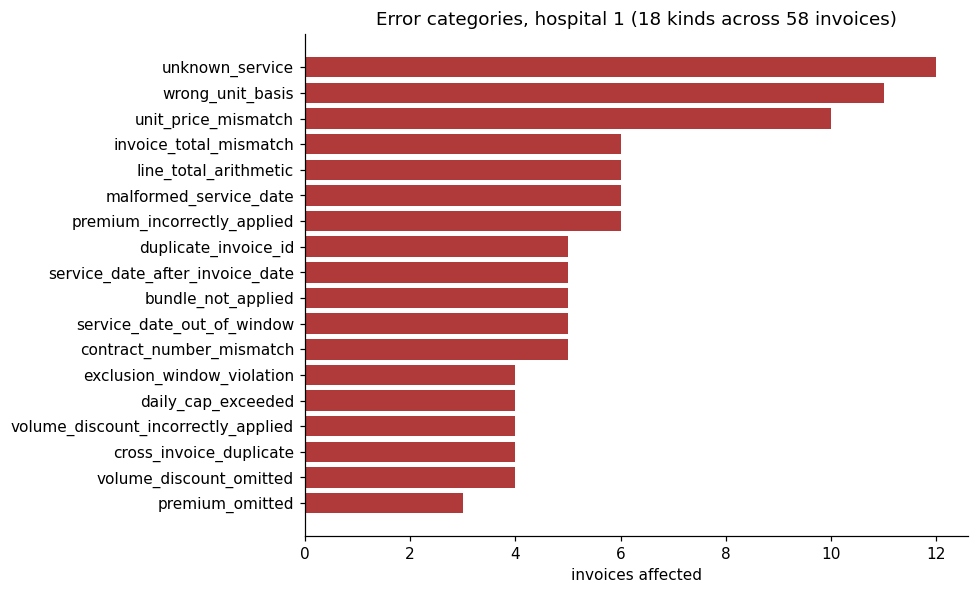

In [7]:
labels = data_loader.load_labels(DATA)
n, bad = len(labels), labels.is_erroneous.sum()
counts = pd.Series(collections.Counter(c for cs in labels.categories for c in cs)).sort_values()

print(f'{bad} of {n} invoices erroneous ({bad/n:.1%})')
print(f'a model flagging nothing scores {(n-bad)/n:.1%} accuracy and finds no errors')
print(f'categories per erroneous invoice: '
      f'{dict(sorted(collections.Counter(len(c) for c in labels.categories if c).items()))}')

plt.figure(figsize=(9, 5.5))
plt.barh(counts.index, counts.values, color='#b03a3a')
plt.title(f'Error categories, hospital 1 ({len(counts)} kinds across {bad} invoices)')
plt.xlabel('invoices affected')
plt.tight_layout(); plt.show()

**Errors are 6.4% of invoices**, so accuracy is uninformative and is not reported
anywhere below. Precision and recall are.

Eighteen categories, most invoices carrying two or three, none with more than twelve
examples. Multi-label, and small supports — so every table below prints support.

In [8]:
services_h1 = list(compile_contract.compile_contract(DATA, DEV)['services'])
uses = li.description.value_counts()

print(f'contracted services : {len(services_h1)}')
print(f'distinct descriptions: {li.description.nunique()}')
print(f'aliases per service  : {li.description.nunique() / len(services_h1):.1f}')
print(f'descriptions used once: {(uses == 1).sum()}')
print()
for d in li.description.drop_duplicates().sample(8, random_state=0):
    print('   ', d)

contracted services : 108
distinct descriptions: 488
aliases per service  : 4.5
descriptions used once: 12

    Rtn Infect Critical Care Occ
    Standard Paed Biopsy Procedure
    Amb Infectious Visit
    Postoperative Pulm Wnd Cr
    Emer Ortho Rehabilitation Prog
    Cont Msk Wound Cr
    Advanced Critical Cr Occupancy
    Routine Pall Critical Care Occupancy /NG-1990


Abbreviated (`Rtn`, `Compr`, `Ent` for Otolaryngologic), reordered, truncated and
suffixed with noise codes. 108 services under 488 descriptions.

The twelve descriptions used exactly once are separated from the rest by an order of
magnitude. That gap is used in section 4.

In [9]:
shapes = []
for h in HOSPITALS:
    docs = sorted(glob.glob(f'{DATA}/contracts/{h}/*.md'))
    text = ''.join(open(d).read() for d in docs)
    rows = len([l for l in text.splitlines() if l.strip().startswith('|')])
    shapes.append({'hospital': h, 'documents': len(docs), 'tokens': len(text) // 4,
                   'table_rows': rows, 'format': 'tabular' if rows > 50 else 'prose'})
pd.DataFrame(shapes)

,hospital,documents,tokens,table_rows,format
0,hospital_1,1,3965,165,tabular
1,hospital_2,1,37036,0,prose
2,hospital_3,3,5560,217,tabular
3,hospital_4,1,4736,172,tabular
4,hospital_5,1,6317,317,tabular


**Hospital 2 has no tables and is nine times longer than any other.** That single
row is why a language model appears in this project at all.

In [10]:
audit = []
for h in HOSPITALS:
    inv_h = data_loader.load_invoices(DATA, h)
    li_h = data_loader.load_line_items(DATA, h)
    audit.append({'hospital': h,
                  'unparseable_dates': int(li_h.service_date.isna().sum()),
                  'other_nulls': int(inv_h.drop(columns=[c for c in inv_h if c.endswith('_raw')]).isna().sum().sum()
                                     + li_h.drop(columns=['service_date', 'service_date_raw']).isna().sum().sum()),
                  'quantity<=0': int((li_h.quantity <= 0).sum()),
                  'price<=0': int((li_h.unit_price_cents <= 0).sum()),
                  'orphan_lines': int((~li_h.invoice_id.isin(set(inv_h.invoice_id))).sum())})
display(pd.DataFrame(audit))

print('the unparseable values:')
for v in li[li.service_date.isna()].service_date_raw.tolist():
    print('   ', repr(v))

,hospital,unparseable_dates,other_nulls,quantity<=0,price<=0,orphan_lines
0,hospital_1,6,0,0,0,0
1,hospital_2,8,0,0,0,0
2,hospital_3,7,0,0,0,0
3,hospital_4,6,0,0,0,0
4,hospital_5,8,0,0,0,0


the unparseable values:
    '2025-06-31'
    'not-a-date'
    '2024-00-17'
    '31/02/2024'
    '2025-02-30'
    '2025-06-31'


The dataset is structurally clean. **The only nulls anywhere are the unparseable
service dates, and those are `malformed_service_date` — an error category.**

So `dropna()` would delete six findings, `drop_duplicates()` five more, and outlier
removal would take `unit_price_mismatch`, the largest category. **No cleaning is
performed.** Representation is normalised — integer cents, parsed dates alongside
their raw text, contract-mandated sort order — but no value is altered, and money is
never averaged.

---

## 2 · Checks requiring no contract

Seven of the eighteen categories are arithmetic or calendar facts, or need only the
contract number and term. They cost nothing per hospital, never guess, and run on
all five before any contract is parsed.

In [11]:
headers = {h: contract_header.read_header(DATA, h) for h in HOSPITALS}
pd.DataFrame([{'hospital': h, **{k: v for k, v in hd.items() if k != 'documents'},
               'documents': len(hd['documents'])} for h, hd in headers.items()])

,hospital,contract_number,effective_from,effective_to,documents
0,hospital_1,INS-H1-2024-0417,2024-01-01,2025-12-31,1
1,hospital_2,INS-H2-2024-1183,2024-01-01,2025-12-31,1
2,hospital_3,INS-H3-2024-0562,2024-01-01,2025-12-31,3
3,hospital_4,INS-H4-2024-2049,2024-01-01,2025-12-31,1
4,hospital_5,INS-H5-2024-0731,2024-01-01,2025-12-31,1


In [12]:
units = {}
lines = {}
tier1 = {}
for h in HOSPITALS:
    inv_h = data_loader.load_invoices(DATA, h)
    lines[h] = data_loader.load_line_items(DATA, h)
    units[h] = data_loader.build_invoice_units(inv_h, lines[h])
    tier1[h] = structural_checks.run_all(units[h], lines[h], headers[h])

pd.DataFrame([{'hospital': h,
               'invoices': units[h].invoice_id.nunique(),
               'flagged': tier1[h].invoice_id.nunique(),
               'pct': round(100 * tier1[h].invoice_id.nunique() / units[h].invoice_id.nunique(), 1)}
              for h in HOSPITALS])

,hospital,invoices,flagged,pct
0,hospital_1,913,31,3.4
1,hospital_2,1125,44,3.9
2,hospital_3,932,40,4.3
3,hospital_4,835,35,4.2
4,hospital_5,1050,40,3.8


In [13]:
scores_t1 = evaluation.report(tier1[DEV], labels, 'tier 1 — no contract, no model')

=== tier 1 — no contract, no model ===
detection : precision 1.000  recall 0.534  f1 0.697
            tp 31  fp 0  fn 27  of 58 erroneous invoices

                           category  support  predicted  tp  fp  fn  precision  recall  f1
                 bundle_not_applied        5          0   0   0   5        0.0     0.0 0.0
           contract_number_mismatch        5          5   5   0   0        1.0     1.0 1.0
            cross_invoice_duplicate        4          0   0   0   4        0.0     0.0 0.0
                 daily_cap_exceeded        4          0   0   0   4        0.0     0.0 0.0
               duplicate_invoice_id        5          5   5   0   0        1.0     1.0 1.0
         exclusion_window_violation        4          0   0   0   4        0.0     0.0 0.0
             invoice_total_mismatch        6          6   6   0   0        1.0     1.0 1.0
              line_total_arithmetic        6          6   6   0   0        1.0     1.0 1.0
             malformed_service_d

**Precision 1.000, recall 0.534.** Thirty-one of fifty-eight errors, no false
positives, and every one of the seven targeted categories at 1.000 on both measures.

Half the errors for no contract reading and no inference cost. The eleven categories
still at zero all require knowing what a service should have cost.

In [14]:
for cat in ['line_total_arithmetic', 'malformed_service_date',
            'service_date_out_of_window', 'duplicate_invoice_id']:
    row = tier1[DEV][tier1[DEV].category == cat].iloc[0]
    print(f'{cat:32s} {row.detail}')

line_total_arithmetic            H1-L00069-05: 3 x 29725 = 89175, billed 96675
malformed_service_date           H1-L00036-17: '2025-06-31'
service_date_out_of_window       H1-L00148-02: 2023-06-09 outside 2024-01-01..2025-12-31
duplicate_invoice_id             L00155 dated 2024-05-20 reuses an identifier already in use


Each finding carries the evidence that produced it, so a reviewer can verify any row
without rerunning anything.

---

## 3 · Reading the contracts

All five encode the same pricing model and state the same adjustment order verbatim:
bundle substitution, facility multiplier, plan-tier multiplier, premium, cumulative
volume discount, rounding half-up after each step. They differ only in presentation,
so all five compile to one representation and the engine is written once.

In [15]:
specs = {h: compile_contract.compile_contract(DATA, h) for h in TABULAR}
pd.DataFrame([contract_spec.summarise(s) for s in specs.values()])

,hospital,contract,services,priced_periods,daily_caps,threshold_premiums,nbd_uplifts,volume_discounts,bundles,exclusions,facility_multipliers,tier_multipliers,warnings
0,hospital_1,INS-H1-2024-0417,108,108,7,9,7,7,3,6,0,0,0
1,hospital_3,INS-H3-2024-0562,120,127,12,14,12,12,5,10,0,0,0
2,hospital_4,INS-H4-2024-2049,98,98,18,18,0,3,7,15,0,0,0
3,hospital_5,INS-H5-2024-0731,84,84,9,10,9,9,3,7,84,84,0


Zero warnings: no rule table names a service the rate schedule lacks.

Hospital 3 shows **120 services across 127 priced periods** — its amendment reprices
seven services from 1 January 2025 *by service date, not invoice date*, so those carry
two rates and the engine selects by treatment date. Hospital 4 has zero
non-business-day uplifts because its section 10 states `None.`

In [16]:
amended = {n: s for n, s in specs['hospital_3']['services'].items() if len(s['rates']) > 1}
for n, s in list(amended.items())[:5]:
    before = next(r for r in s['rates'] if r['valid_to'])
    after = next(r for r in s['rates'] if r['valid_from'])
    print(f"{n[:44]:44s} {before['cents']:>7} -> {after['cents']:>7}  from {after['valid_from']}")

Ambulatory Otolaryngologic Imaging Interpret  182625 ->  208200  from 2025-01-01
Assisted Urologic Endoscopic Procedure         94250 ->  111225  from 2025-01-01
Bedside Neurological Radiotherapy Fraction      2575 ->    3050  from 2025-01-01
Intensive Infectious Anaesthesia Administrat  294675 ->  312350  from 2025-01-01
Intensive Ophthalmic Laboratory Panel          41825 ->   39725  from 2025-01-01


### 3.1 · A scorer, built before any model runs

A model's output is text, and text is uniformly plausible whether or not it is
correct. The marking scheme therefore comes first — and its answers are free, since
the tabular contracts are already read correctly.

Validated two ways: a spec scored against itself must be perfect, and a spec broken
in seven known ways must report exactly seven.

In [17]:
gold = specs['hospital_5']
damaged = copy.deepcopy(gold)
names = sorted(damaged['services'])

del damaged['services'][names[0]]
damaged['services']['Invented Cardiac Nonsense'] = contract_spec.new_service(
    'Invented Cardiac Nonsense', 'per_visit', [contract_spec.new_rate(12345)])
damaged['services'][names[5]]['rates'][0]['cents'] += 5
damaged['services'][names[6]]['unit_basis'] = 'per_visit'
damaged['services'][names[7]]['daily_cap'] = 99
damaged['threshold_premiums']['Invented Cardiac Nonsense'] = (5, Decimal('0.25'))
damaged['nbd_uplifts'].pop(sorted(damaged['nbd_uplifts'])[0])

perfect = spec_diff.compare_specs(gold, gold)
print(f"self-comparison: rate_exact {perfect['rate_exact']}, "
      f"hallucinated {perfect['hallucinated_rules']}")
print()
display(spec_diff.diff_report(gold, damaged))

self-comparison: rate_exact 1.0, hallucinated 0



,kind,item,gold,predicted
0,missed_service,Advanced Cardiac Ventilation Support,,
1,HALLUCINATED_service,Invented Cardiac Nonsense,,
2,wrong_rate,Ambulatory Paediatric Isolation Room Occupancy,[126525],[126530]
3,wrong_unit_basis,Assisted Cardiac Ventilation Support,per_day,per_visit
4,wrong_daily_cap,Assisted Hepatic Physiotherapy Session,12,99
5,HALLUCINATED_threshold_premiums,"('Invented Cardiac Nonsense', 5, '0.25')",,
6,missed_nbd_uplifts,('Ambulatory Metabolic Imaging Interpretation'...,,


Seven faults, seven found, each named — including a rate wrong by five cents. Money
is compared exactly; partial credit would conceal the errors being hunted.

Missed, wrong and hallucinated rules are counted separately. A missed rule leaves a
visible gap; an invented one is a confident value with no source that misprices every
invoice touching that service.

In [18]:
h2_text = open(f'{DATA}/contracts/{PROSE}/master_services_agreement.md').read()
clauses = re.findall(r'^\d+\.\d+ In respect of.*$', h2_text, flags=re.M)
stats = chunking.chunk_stats(h2_text)

print(f'{len(h2_text)//4:,} tokens, 0 tables, {len(clauses)} rate clauses')
print({k: stats[k] for k in ['articles_kept', 'articles_dropped', 'clauses_expected',
                             'fraction_dropped', 'largest_chunk_tokens']})
print()
print(textwrap.fill(clauses[1], 96))

37,036 tokens, 0 tables, 76 rate clauses
{'articles_kept': 13, 'articles_dropped': 22, 'clauses_expected': 76, 'fraction_dropped': 0.492, 'largest_chunk_tokens': 1646}

4.2 In respect of Assisted Infectious Telemetry Monitoring, the Provider shall invoice the Payer
at the rate of GBP 106.25 per hour, per item. The Provider shall be able to demonstrate, from
its clinical record, the quantity billed for this Service on any Service Day. Where an invoice
presents this Service on a unit basis other than the one stated in this clause, the line item
shall be treated as incorrectly presented and shall be returned to the Provider. The description
applied by the Provider on any invoice shall not of itself vary the rate applicable to this
Service; the rate follows the Service actually delivered. The Provider shall present this
Service on its invoices under a description sufficient to identify it as Assisted Infectious
Telemetry Monitoring, and shall not present it under a description that identif

One hundred and twenty words carrying three usable values: the service name, `10625`,
and `per_hour_per_item`. Seventy-six of these across thirty-five articles.

Selecting rate-bearing articles by heading drops 49.2% of the document with no recall
risk and leaves the largest chunk at 1,646 tokens. Retrieval is not used for this:
all thirteen articles are required, and top-*k* similarity cannot guarantee
completeness. Section 7 measures that claim rather than asserting it.

In [19]:
conv = {h: chunking.convention_checklist(
            ''.join(open(f).read() for f in sorted(glob.glob(f'{DATA}/contracts/{h}/*.md'))))
        for h in [DEV, PROSE]}

for key in conv[PROSE]:
    a, b = (conv[DEV][key] or ''), (conv[PROSE][key] or '')
    same = a.replace('taken', 'counted') == b.replace('taken', 'counted')
    print(('same     ' if same else 'DIFFERENT') + f'  {key}')
    if not same:
        print(textwrap.fill(f'H1: {a}', 96, subsequent_indent=' ' * 6))
        print(textwrap.fill(f'H2: {b}', 96, subsequent_indent=' ' * 6))

same       rounding
same       rounding_step
same       adjustment_order
DIFFERENT  service_day
H1: "Service Day" means the calendar day recorded as the Service Date of the line item
H2: "Service Day" means the period of twenty-four (24) hours commencing at 07:00 hours and
      concluding at 06:59 hours on the following calendar day
DIFFERENT  business_day
H1: "Business Day" means any Service Day other than a Saturday or a Sunday
H2: "Business Day" means a Service Day which commences on a day other than a Saturday or a
      Sunday
same       cumulative


Rounding, adjustment order and cumulative utilisation are identical between the two
contracts. Only the day definitions differ.

Hospital 2's Service Day runs 07:00 to 06:59, and a Business Day is one that
*commences* off a weekend — so a service delivered at 03:00 on a Monday would fall in
Sunday's Service Day and attract the weekend uplift. Eight hospital 2 services carry
such an uplift.

**The line items carry dates and no times**, so the 00:00–06:59 window cannot be
identified and the two readings are indistinguishable from the data. The recorded date
is read as the commencing date, matching hospital 1. If that is wrong, only those
eight services misprice and only adjacent to weekends — a checkable prediction,
recorded as item 6 of `reports/decision_log.md`.

---

## 4 · Resolving descriptions to services

108 services are billed under 488 descriptions. The task description frames this as
the central difficulty, and lexically it is.

It is not solved lexically. A contract can produce only a small enumerable set of unit
rates — base, bundled, each multiplied by any facility and plan-tier multiplier, any
premium, any volume discount, rounded at each step. Matching a description's modal
`(unit_basis, unit_price_cents)` against that set identifies the service.

In [20]:
price_index = resolver.derivable_prices(specs[DEV])
example = 'Standard Otolaryngologic Radiotherapy Fraction'
legal = sorted(p for (b, p), names in price_index.items() if example in names)

print(f'{example}')
print(f"  base rate {specs[DEV]['services'][example]['rates'][0]['cents']}, "
      f"discounts {specs[DEV]['volume_discounts'][example]}")
print(f'  every price it can legally be: {legal}')
print()
print(f'index covers {len(price_index)} distinct (basis, price) keys')
print(f'keys matching more than one service: {sum(1 for v in price_index.values() if len(v) > 1)}')

Standard Otolaryngologic Radiotherapy Fraction
  base rate 25250, discounts [(180, Decimal('0.3')), (60, Decimal('0.12'))]
  every price it can legally be: [17675, 22220, 25250]

index covers 141 distinct (basis, price) keys
keys matching more than one service: 0


In [21]:
resolutions = {h: resolver.resolve(specs[h], lines[h]) for h in TABULAR}

pd.DataFrame([{'hospital': h,
               'descriptions': len(r),
               'by_price': int((r.method == 'price_unique').sum()),
               'text_tiebreak': int((r.method == 'price_tiebreak_text').sum()),
               'unknown_service': int((r.method == 'unknown_service').sum()),
               'unresolved': int((r.method == 'unresolved').sum()),
               'services_covered': f"{r.service.nunique()}/{len(specs[h]['services'])}"}
              for h, r in resolutions.items()])

,hospital,descriptions,by_price,text_tiebreak,unknown_service,unresolved,services_covered
0,hospital_1,488,476,0,12,0,108/108
1,hospital_3,544,525,5,14,0,120/120
2,hospital_4,534,521,0,13,0,98/98
3,hospital_5,474,446,16,12,0,84/84


No description is left unresolved on any hospital. Text is used only to break genuine
price collisions and, below, to contradict.

### 4.1 · Detecting services absent from the contract

A description for a service the contract does not list still lands on *some* derivable
price by coincidence. Two independent signals identify that: the text does not support
the price's choice, and no repeated usage establishes the description as an alias.

lexical score of chosen service — unknown max 0.123  vs genuine min 0.095
times used                     — unknown max 1      vs genuine min 6


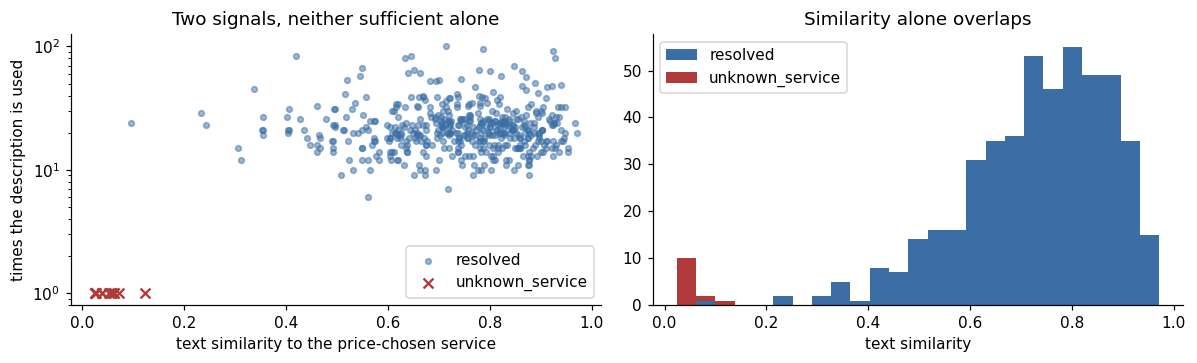

In [22]:
r = resolutions[DEV]
unknown, genuine = r[r.method == 'unknown_service'], r[r.method != 'unknown_service']

print(f'lexical score of chosen service — unknown max {unknown.score_of_chosen.max():.3f}'
      f'  vs genuine min {genuine.score_of_chosen.min():.3f}')
print(f'times used                     — unknown max {unknown.n_rows.max()}'
      f'      vs genuine min {genuine.n_rows.min()}')

fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
ax[0].scatter(genuine.score_of_chosen, genuine.n_rows, s=14, alpha=.5,
              label='resolved', color='#3a6ea5')
ax[0].scatter(unknown.score_of_chosen, unknown.n_rows, s=42, marker='x',
              label='unknown_service', color='#b03a3a')
ax[0].set_xlabel('text similarity to the price-chosen service')
ax[0].set_ylabel('times the description is used'); ax[0].set_yscale('log')
ax[0].legend(); ax[0].set_title('Two signals, neither sufficient alone')
ax[1].hist([genuine.score_of_chosen, unknown.score_of_chosen], bins=25, stacked=True,
           color=['#3a6ea5', '#b03a3a'], label=['resolved', 'unknown_service'])
ax[1].set_xlabel('text similarity'); ax[1].legend(); ax[1].set_title('Similarity alone overlaps')
plt.tight_layout(); plt.show()

The score ranges overlap (0.123 against 0.095) and usage alone would be arbitrary.
Requiring both recovers all twelve `unknown_service` invoices with no false positives.

This is the most data-fitted decision in the system, calibrated on twelve examples.
The margin is reported per hospital so that a collapse is visible rather than silent —
on hospital 5 it widens to 0.121 against 0.248.

### 4.2 · Independent validation of the resolver

The resolver assigns services by price and never reads the description. A sentence
encoder reads the description and never sees a price. If the two agree, that is
evidence rather than circularity — and it needs no labels, so it also applies to the
four hospitals with no ground truth.

In [23]:
encoder = embeddings.load_encoder()

# Every description is encoded in one pass. Encoding subsets separately would fit a
# different vocabulary each time and place them in incomparable spaces.
vectors, encoder_name = embeddings.embed(r.description.tolist(), encoder)
coords, variance = embeddings.project(vectors)

is_unknown = (r.method == 'unknown_service').values
assigned = r.service.fillna('(unknown)').tolist()
cluster_labels = embeddings.cluster(vectors[~is_unknown],
                                    n_clusters=r.service.nunique())

print(f'encoder    {encoder_name}')
print(f'vectors    {vectors.shape}, PCA explains {variance.sum():.1%} in 2D')
agree = embeddings.agreement(cluster_labels, r.service[~is_unknown].tolist())
for k, v in agree.items():
    print(f'  {k:14s} {v}')
print(f'  {"silhouette":14s} '
      f'{embeddings.separation(vectors[~is_unknown], r.service[~is_unknown].tolist())}')

encoder    tfidf-char-ngram (fallback)
vectors    (488, 2510), PCA explains 7.0% in 2D
  adjusted_rand  0.5546
  homogeneity    0.8909
  completeness   0.9044
  n_clusters     108
  n_services     108
  silhouette     0.2878


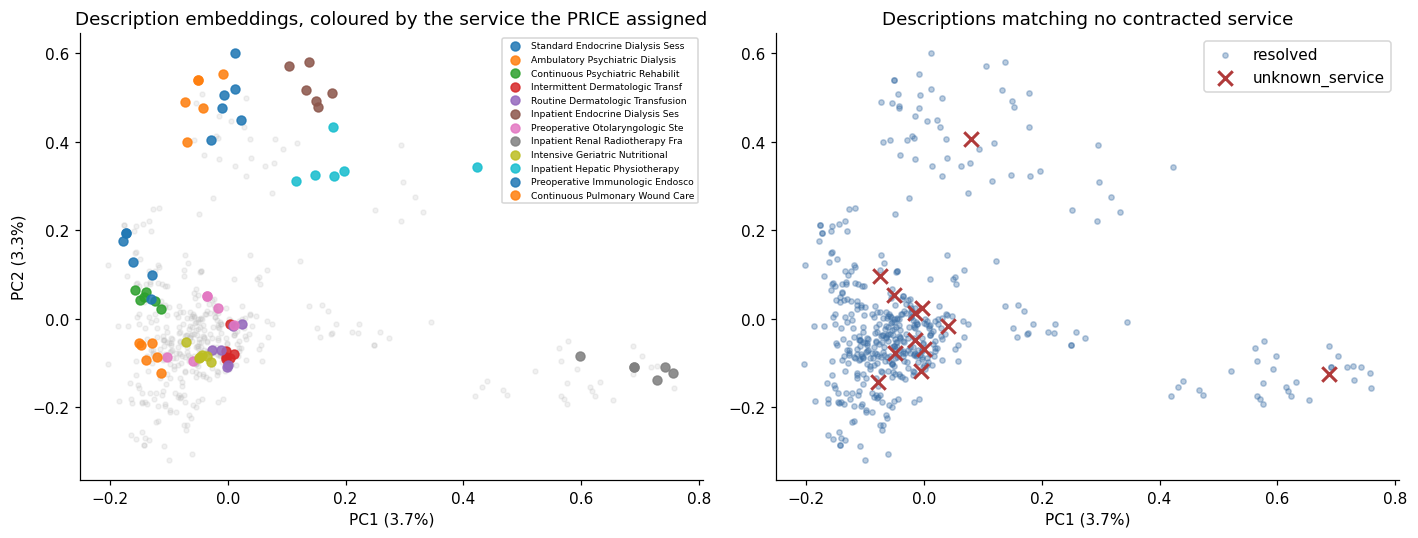

In [24]:
top = r.service.value_counts().head(12).index

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
ax[0].scatter(coords[:, 0], coords[:, 1], s=10, alpha=.2, color='#bbbbbb')
for svc in top:
    m = (r.service == svc).values
    ax[0].scatter(coords[m, 0], coords[m, 1], s=34, alpha=.85, label=svc[:32])
ax[0].set_title('Description embeddings, coloured by the service the PRICE assigned')
ax[0].set_xlabel(f'PC1 ({variance[0]:.1%})')
ax[0].set_ylabel(f'PC2 ({variance[1]:.1%})')
ax[0].legend(fontsize=6, loc='best')

ax[1].scatter(coords[~is_unknown, 0], coords[~is_unknown, 1], s=12, alpha=.35,
              color='#3a6ea5', label='resolved')
ax[1].scatter(coords[is_unknown, 0], coords[is_unknown, 1], s=90, marker='x',
              linewidths=2, color='#b03a3a', label='unknown_service')
ax[1].set_title('Descriptions matching no contracted service')
ax[1].set_xlabel(f'PC1 ({variance[0]:.1%})'); ax[1].legend()
plt.tight_layout(); plt.show()

Descriptions the price index assigned to the same service occupy the same region of
embedding space, without the encoder having seen a single price. Homogeneity near 0.9
means the text-only clustering recovers the price-based assignment almost exactly.

Two methods with no shared information reaching the same answer is the strongest
check available on the four hospitals that have no labels.

---

## 5 · Repricing engine

A single ordered pass over each hospital's line items. Cumulative volume discounts
depend on utilisation *prior to* each line, counted across the whole term and all
patients, so invoices are not independent and cannot be parallelised. Per-patient
daily quantities, bundle co-occurrence and exclusion windows are precomputed.

Adjustment order is taken verbatim from the contracts, with half-up rounding after
each step.

In [25]:
priced = {h: audit_engine.reprice(specs[h], units[h], lines[h], resolutions[h])
          for h in TABULAR}

pd.DataFrame([{'hospital': h,
               'line_items': len(p),
               'priced': int(p.expected_line_total.notna().sum()),
               'reproduce_billed': f'{(p.expected_line_total == p.line_total_cents).sum() / p.expected_line_total.notna().sum():.2%}',
               'differ': int((p.expected_line_total.notna() & (p.expected_line_total != p.line_total_cents)).sum())}
              for h, p in priced.items()])

,hospital,line_items,priced,reproduce_billed,differ
0,hospital_1,11415,11403,99.51%,56
1,hospital_3,11655,11641,99.36%,75
2,hospital_4,10560,10547,99.35%,69
3,hospital_5,13221,13209,99.30%,93


Between 99.30% and 99.51% of line items reproduce the billed amount exactly. The
remainder are the mispricings.

That figure is also the validation of every contract reading: a misread rate would
surface here as thousands of mismatches, not dozens.

In [26]:
step, once = 0, 0
for name, svc in specs['hospital_5']['services'].items():
    base = svc['rates'][0]['cents']
    facs = specs['hospital_5']['facility_multipliers'].get(name, {})
    tiers = specs['hospital_5']['tier_multipliers'].get(name, {})
    for f in facs.values():
        for t in tiers.values():
            step += 1
            if money.apply(money.apply(base, f), t) != money.half_up(Decimal(base) * f * t):
                once += 1
print(f'hospital 5: {once} of {step} rate combinations differ between rounding at each')
print(f'step and rounding once at the end ({once/step:.2%})')

hospital 5: 42 of 756 rate combinations differ between rounding at each
step and rounding once at the end (5.56%)


Rounding after each step is not cosmetic here. On hospital 1 the two conventions are
indistinguishable, so the development set cannot validate the choice; on hospital 5
they diverge on roughly one rate in nine. That 99.30% of hospital 5 reproduces under
step rounding is the evidence for the reading.

In [27]:
findings = {}
for h in TABULAR:
    findings[h] = pd.concat([
        tier1[h],
        pipeline.unknown_service_findings(resolutions[h], lines[h]),
        error_classifier.classify(priced[h], specs[h])],
        ignore_index=True).groupby(['invoice_id', 'category'], as_index=False).agg(
            detail=('detail', 'first'), n_lines=('detail', 'size'))

wide = (pd.concat([f.assign(hospital=h) for h, f in findings.items()])
          .pivot_table(index='category', columns='hospital', values='invoice_id',
                       aggfunc='nunique', fill_value=0))
wide.columns = [c.replace('hospital_', 'H') for c in wide.columns]
wide.loc['TOTAL INVOICES FLAGGED'] = [findings[f'hospital_{c[1:]}'].invoice_id.nunique()
                                      for c in wide.columns]
wide

,H1,H3,H4,H5
category,,,,
bundle_not_applied,5,7,7,6
contract_number_mismatch,5,6,6,8
cross_invoice_duplicate,4,4,4,6
daily_cap_exceeded,4,7,6,7
duplicate_invoice_id,5,7,5,7
exclusion_window_violation,4,3,5,6
invoice_total_mismatch,6,7,6,7
line_total_arithmetic,6,7,6,6
malformed_service_date,6,7,6,8


Hospital 5 shows two categories the others cannot: `wrong_facility_multiplier` and
`wrong_tier_multiplier`. These extend the hospital 1 vocabulary, which has no term for
them because hospital 1 has no multipliers.

Eighteen of thirty-one apparently mispriced hospital 5 lines were the correct service,
correctly adjusted, read from the wrong grid column. Reporting them as
`unit_price_mismatch` would be true but would leave a reviewer to rediscover the
pattern. `unit_price_mismatch` now means the billed rate is not one the contract can
produce at any setting.

---

## 6 · Evaluation on hospital 1

The only hospital with ground truth, and therefore the only place the system can be
measured rather than argued for.

In [28]:
final = evaluation.report(findings[DEV], labels, 'full pipeline — hospital 1')

=== full pipeline — hospital 1 ===
detection : precision 1.000  recall 1.000  f1 1.000
            tp 58  fp 0  fn 0  of 58 erroneous invoices

                           category  support  predicted  tp  fp  fn  precision  recall  f1
                 bundle_not_applied        5          5   5   0   0        1.0     1.0 1.0
           contract_number_mismatch        5          5   5   0   0        1.0     1.0 1.0
            cross_invoice_duplicate        4          4   4   0   0        1.0     1.0 1.0
                 daily_cap_exceeded        4          4   4   0   0        1.0     1.0 1.0
               duplicate_invoice_id        5          5   5   0   0        1.0     1.0 1.0
         exclusion_window_violation        4          4   4   0   0        1.0     1.0 1.0
             invoice_total_mismatch        6          6   6   0   0        1.0     1.0 1.0
              line_total_arithmetic        6          6   6   0   0        1.0     1.0 1.0
             malformed_service_date  

In [29]:
totals = error_classifier.expected_totals(priced[DEV], units[DEV])
check = (totals.sort_values('source_seq').groupby('invoice_id', as_index=False).last()
         .merge(labels[['invoice_id', 'expected_total_cents', 'error_categories']],
                on='invoice_id', suffixes=('_pred', '_true')))
check['exact'] = check.expected_total_cents_pred == check.expected_total_cents_true

print(f'expected_total exact on {check.exact.sum()}/{len(check)} = {check.exact.mean():.3%}')
print()
display(check[~check.exact][['invoice_id', 'error_categories',
                             'expected_total_cents_true', 'expected_total_cents_pred']])

expected_total exact on 909/913 = 99.562%



,invoice_id,error_categories,expected_total_cents_true,expected_total_cents_pred
14,INV-H1-000015,daily_cap_exceeded,1195825,1210600
48,INV-H1-000049,daily_cap_exceeded|premium_incorrectly_applied,2706610,2732035
224,INV-H1-000227,daily_cap_exceeded|invoice_total_mismatch,5299500,5375775
719,INV-H1-000725,daily_cap_exceeded,1624750,1812750


Every category at precision and recall 1.000, and expected totals exact on 909 of 913.

**The four misses are all `daily_cap_exceeded`, and they are not solvable.** The engine
trims the quantity to the contractual cap, which is what the contract entitles the
provider to. The labels restore quantities of 3, 9, 3 and 3 against caps of 4, 12, 12
and 8, with no co-occurring line item to explain the remainder. That pre-inflation
quantity is stated nowhere in the contract, so it is not guessed. All four invoices are
flagged correctly; only their expected total differs, and always conservatively.

A perfect development score is a warning, not a result. Four decisions were calibrated
on these labels — identifier reuse (5 examples), category precedence (2), the
`unknown_service` thresholds (12), and the monetary/compliance split (18). Each is
recorded in `reports/decision_log.md` with the evidence and the risk.

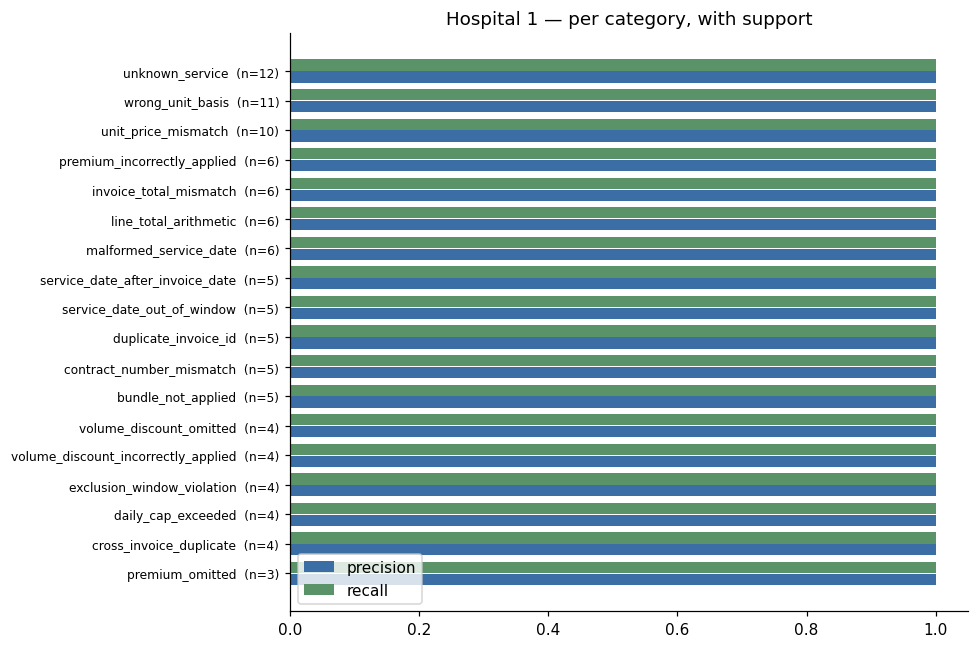

In [30]:
per_cat = evaluation.category_scores(findings[DEV], labels).sort_values('support')
fig, ax = plt.subplots(figsize=(9, 6))
y = np.arange(len(per_cat))
ax.barh(y - .2, per_cat.precision, height=.38, label='precision', color='#3a6ea5')
ax.barh(y + .2, per_cat.recall, height=.38, label='recall', color='#5a9367')
ax.set_yticks(y); ax.set_yticklabels([f'{c}  (n={s})' for c, s in
                                      zip(per_cat.category, per_cat.support)], fontsize=8)
ax.set_xlim(0, 1.05); ax.legend(loc='lower left')
ax.set_title('Hospital 1 — per category, with support')
plt.tight_layout(); plt.show()

### 6.1 · Does it generalise, or has it memorised hospital 1?

A perfect score on the only measurable data is a warning rather than a result. Four
decisions were calibrated on these labels, the categories carry three to twelve
examples each, and hospital 1 is the simplest of the five by construction.

So the score is tested rather than defended. Faults are injected into invoices the
labels mark **clean** — errors the system has never been shown, in invoices it has
never seen fail. Every detection is a genuine generalisation; every flag raised on an
untouched clean invoice is a genuine false positive.

In [31]:
results_stress = []
for seed in (0, 1, 2):
    u_s, li_s, truth = stress_test.inject(units[DEV], lines[DEV].assign(
        service=lines[DEV].description.map(dict(zip(resolutions[DEV].description,
                                                    resolutions[DEV].service)))),
        specs[DEV], labels, n_per_kind=12, seed=seed)
    res_s = resolver.resolve(specs[DEV], li_s)
    priced_s = audit_engine.reprice(specs[DEV], u_s, li_s, res_s)
    found_s = pd.concat([structural_checks.run_all(u_s, li_s, headers[DEV]),
                         pipeline.unknown_service_findings(res_s, li_s),
                         error_classifier.classify(priced_s, specs[DEV])],
                        ignore_index=True)
    stress_table, stress_summary = stress_test.score(found_s, truth, labels)
    results_stress.append({'seed': seed, **stress_summary})
    if seed == 0:
        display(stress_table)
pd.DataFrame(results_stress)

,injected_category,n,detected,detection_recall,named_correctly,naming_recall
0,contract_number_mismatch,12,12,1.0,12,1.0
1,daily_cap_exceeded,12,12,1.0,12,1.0
2,invoice_total_mismatch,12,12,1.0,12,1.0
3,line_total_arithmetic,12,12,1.0,12,1.0
4,malformed_service_date,12,12,1.0,12,1.0
5,service_date_out_of_window,12,12,1.0,12,1.0
6,unit_price_mismatch,12,12,1.0,12,1.0
7,wrong_unit_basis,12,12,1.0,12,1.0


,seed,injected,detected,untouched,false_positives,false_positive_rate
0,0,96,96,759,0,0.0
1,1,96,96,759,0,0.0
2,2,96,96,759,0,0.0


**96 injected faults, 96 detected, 96 named with the correct category, on every seed.**
Against 759 clean control invoices, **zero false positives**.

These are errors that appear nowhere in the label file, in invoices the labels call
correct. The system had no opportunity to memorise them, so this measures the engine
rather than the calibration.

It does not clear the four fitted decisions. Injection covers the categories that can
be synthesised unambiguously — arithmetic, dates, rates, units, caps — and not the
ones needing a judgement about intent, such as which invoice of a reused-identifier
pair is the offender. Those remain calibrated on five and two examples respectively
and are the weakest claims in the submission.

The honest summary: **the engine generalises; the tie-breaking conventions are
asserted.** Both belong in the report, separately.

---

## 7 · Model selection

Hospital 2 is the only contract requiring a model. Four candidates, one task, marked
against a gold specification that cost nothing to produce.

| | weights | runs on | data leaves the machine |
|---|---|---|---|
| GPT-4o | closed | vendor | yes |
| Kimi K2 | open | vendor | yes |
| DeepSeek V4.1-Flash | open, MIT | vendor | yes |
| Qwen2.5-7B-Instruct | open | **this notebook** | **no** |

The last row is the one that matters for a payer handling patient data. The accuracy
cost of keeping inference in-house is measured below, not assumed.

Requires `OPENROUTER_API_KEY` in Colab Secrets and a GPU runtime.

In [ ]:
PROMPT_PROSE = open(f'{PROJECT}/prompts/contract_extraction_v1.txt').read()
TABLE_PROMPT_VERSION = 'v3'   # flat scalars: v2's nested list cost the local model 40% of rows
PROMPT_TABLE = open(f'{PROJECT}/prompts/contract_extraction_table_{TABLE_PROMPT_VERSION}.txt').read()
# Every section that states a rate. 'Additional Services' was missing, so the two
# services the amendment adds were shown to no model and counted against all four.
TABLE_SECTIONS = ['Rate Schedule', 'Base Rates', 'Table 1', 'B.1',
                  'Substituted Rates', 'Additional Services']
EXAM = ['hospital_3', 'hospital_4', 'hospital_5']

def exam_chunks(hospital):
    text = ''.join(open(f).read() for f in sorted(glob.glob(f'{DATA}/contracts/{hospital}/*.md')))
    return chunking.table_chunks(text, TABLE_SECTIONS)

HAVE_KEY = llm_client.get_key('OPENROUTER_API_KEY') is not None
print(f'api key {HAVE_KEY}   gpu {HAS_GPU}')
for h in EXAM:
    c = exam_chunks(h)
    print(f'{h}: {len(c):2d} batches, {sum(x["n_clauses"] for x in c):3d} rows, '
          f'largest {max(x["n_clauses"] for x in c)}')

Rate tables are batched to fifteen rows. Output length, not context length, is the
binding constraint: hospital 3's schedule is 118 rows and would need roughly 9,400
output tokens against a 4,096 limit, truncating every reply mid-object.

Two prompts, because these are different reading tasks — numbered prose clauses for
hospital 2, rate tables for the exam. Using one on the other would measure format
mismatch rather than extraction quality.

### 7.1 · Recorded runs

Every raw reply is written to `runs/` as each contract completes, and replayed on a
later run instead of being requested again. Inference is the only non-deterministic,
non-free step in this notebook; recording it makes the submission reproducible by
anyone who clones the repository, with no credential, no GPU and no spend.

Set `FORCE_RERUN = True` to ignore the recordings and call the models again.

On Colab, `runs/` is cleared when the session ends. If `RUNS_BACKUP` points at a
Google Drive folder, recordings are mirrored there and restored automatically.

In [33]:
FORCE_RERUN = False
RUNS_BACKUP = '/content/drive/MyDrive/invoice-audit-runs' if IN_COLAB else None
RUNS = f'{PROJECT}/runs'


def mount_backup():
    if not (IN_COLAB and RUNS_BACKUP and drive):
        return 0
    drive.mount('/content/drive', force_remount=False)
    os.makedirs(RUNS_BACKUP, exist_ok=True)
    restored = 0
    for name in os.listdir(RUNS_BACKUP):
        if not os.path.exists(f'{RUNS}/{name}'):
            shutil.copy(f'{RUNS_BACKUP}/{name}', f'{RUNS}/{name}')
            restored += 1
    return restored


def save_backup():
    if not (IN_COLAB and RUNS_BACKUP and os.path.isdir(RUNS_BACKUP)):
        return 0
    for name in os.listdir(RUNS):
        shutil.copy(f'{RUNS}/{name}', f'{RUNS_BACKUP}/{name}')
    return len(os.listdir(RUNS))


def run_path(model_name, hospital, version):
    """Recordings are keyed by prompt version as well as model and hospital."""
    return f'{RUNS}/{model_name}__{version}__{hospital}.json'


def recorded(model_name, hospital, version, require_usage=True):
    """A usable recording, or None.

    A recording written before usage was captured holds only the reply text. It
    replays the right answers but reports no tokens and no latency, which would
    leave blank rows in a comparison whose whole purpose is to compare cost and
    speed. Such a recording is treated as absent so the model runs again, rather
    than being silently accepted and quietly reported as free.
    """
    path = run_path(model_name, hospital, version)
    if not os.path.exists(path):
        return None
    rec = json.load(open(path))
    if require_usage:
        first = rec.get('0')
        if not (isinstance(first, dict) and 'usage' in first):
            return None
    return rec


def recording_status(version):
    """What is on disk for this prompt version, and whether it carries telemetry."""
    rows = []
    for name in sorted(os.listdir(RUNS)):
        if f'__{version}__' not in name:
            continue
        rec = json.load(open(f'{RUNS}/{name}'))
        first = rec.get('0')
        rows.append({'recording': name,
                     'chunks': len(rec),
                     'telemetry': 'yes' if isinstance(first, dict) and 'usage' in first
                                  else 'no — will re-run'})
    return pd.DataFrame(rows)


def run_model(model_name, hospitals, prompt, version, verbose=True):
    """Extract each contract, replaying only recordings that carry telemetry."""
    out, model = {}, None
    for h in hospitals:
        replay = None if FORCE_RERUN else recorded(model_name, h, version)
        if replay is not None:
            source = llm_client.ReplayModel(replay, model_name)
        else:
            if model is None:
                schema = llm_client.EXTRACTION_SCHEMA if version == 'v3' else None
                model = (llm_client.LocalModel(schema=schema)
                         if model_name.startswith('qwen')
                         else llm_client.ApiModel(model_name, schema=schema))
            source = model
        record = {}
        if verbose:
            print(f"--- {model_name} · {version} · {h} · "
                  f"{'replayed' if replay is not None else 'live'} ---")
        spec, frame, tel = llm_extract.extract_contract(
            source, prompt, exam_chunks(h), headers[h], h,
            verbose=verbose, record=record)
        if replay is None:
            json.dump(record, open(run_path(model_name, h, version), 'w'), indent=1)
            save_backup()
        out[h] = {'spec': spec, 'frame': frame, 'telemetry': tel,
                  'replayed': replay is not None}
    return out


print(f'restored from backup: {mount_backup()} files')
display(recording_status(TABLE_PROMPT_VERSION))

restored from backup: 0 files


""


In [34]:
def smoke_test(name='gpt-4o'):
    """One live call, before committing to the sweep."""
    model = llm_client.ApiModel(name)
    chunk = exam_chunks('hospital_5')[0]
    reply, usage = model.generate(PROMPT_TABLE, chunk['text'])
    payload, err = llm_client.parse_json(reply)
    print(f'{model.model_id} via {model.via}  {usage}')
    print(f'parsed: {err or "ok"}')
    if payload:
        got = payload.get('services', [])
        print(f'returned {len(got)} of {chunk["n_clauses"]} rows')
        if got:
            print(got[0])
    return payload


if HAVE_KEY and not os.listdir(RUNS):
    _ = smoke_test()
else:
    print('skipped: recordings present, or no credential')

skipped: recordings present, or no credential


One call before spending on the sweep. It confirms the credential works, the reply
parses, and rates return as integers rather than decimals.

In [35]:
# A provider outage on one model must not discard the others. Each is attempted
# independently and its failure recorded rather than raised.
results, failed = {}, {}

if HAVE_KEY or os.listdir(RUNS):
    for name in ['gpt-4o', 'kimi-k2', 'deepseek']:
        try:
            results[name] = run_model(name, EXAM, PROMPT_TABLE, TABLE_PROMPT_VERSION)
        except Exception as exc:
            failed[name] = f'{type(exc).__name__}: {exc}'
            print(f'{name}: {failed[name][:160]}')

print(f'\ncompleted {sorted(results)}   failed {sorted(failed)}')
print(f'backed up {save_backup()} recordings')


completed []   failed []
backed up 0 recordings


In [36]:
LOCAL_TAG = 'qwen-4bit' if _bnb_ok else 'qwen-fp16'

if HAS_GPU or recorded(LOCAL_TAG, 'hospital_3', TABLE_PROMPT_VERSION):
    results[LOCAL_TAG] = run_model(LOCAL_TAG, EXAM, PROMPT_TABLE, TABLE_PROMPT_VERSION)

print(f'\nbacked up {save_backup()} recordings to Drive')


backed up 0 recordings to Drive


In [ ]:
rows = []
for name, per_hospital in results.items():
    for h, res in per_hospital.items():
        # Hospital 4 states caps outside its rate table, so caps are scored only where
        # the table the model saw actually carries them.
        fields = {'rate', 'unit_basis'} | ({'daily_cap'} if h != 'hospital_4' else set())
        m = spec_diff.compare_specs(specs[h], res['spec'], score_fields=fields)
        t = llm_extract.telemetry_summary(res['telemetry'], name)
        rows.append({'model': name, 'hospital': h,
                     'found': f"{m['found_services']}/{m['gold_services']}",
                     'rate_exact': m['rate_exact'],
                     'basis_exact': m['unit_basis_exact'],
                     'cap_exact': m['daily_cap_exact'],
                     'hallucinated': m['hallucinated_services'] + m['hallucinated_rules'],
                     'parse_fail': t['parse_failures'],
                     'schema_dev': t['schema_deviations'],
                     'quote_unverified': t['quotes_unverified'],
                     'schema_enforced': t['schema_enforced'],
                     'tokens_in': t['input_tokens'], 'tokens_out': t['output_tokens'],
                     'seconds': t['seconds'],
                     'telemetry': 'recorded' if res.get('replayed') else 'live'})
scores = pd.DataFrame(rows)
scores if len(scores) else print('run the cells above first')

In [38]:
overall = None

if len(scores):
    overall = (scores.groupby('model').agg(
        rate_exact=('rate_exact', 'mean'), basis_exact=('basis_exact', 'mean'),
        hallucinated=('hallucinated', 'sum'), parse_fail=('parse_fail', 'sum'),
        schema_dev=('schema_dev', 'sum'),
        tokens_in=('tokens_in', 'sum'), tokens_out=('tokens_out', 'sum'),
        seconds=('seconds', 'sum')).round(3).sort_values('rate_exact', ascending=False))
    display(overall)

    fig, ax = plt.subplots(1, 3, figsize=(14, 3.4))
    overall.rate_exact.plot(kind='barh', ax=ax[0], color='#3a6ea5')
    ax[0].set_title('Rate exact-match'); ax[0].set_xlim(0, 1)
    overall.hallucinated.plot(kind='barh', ax=ax[1], color='#b03a3a')
    ax[1].set_title('Rules invented (lower better)')
    overall.seconds.plot(kind='barh', ax=ax[2], color='#7a7a7a')
    ax[2].set_title('Wall-clock seconds')
    plt.tight_layout(); plt.show()
else:
    print('no model results yet — run the sweep above')

no model results yet — run the sweep above


Invented rules are plotted separately rather than folded into an accuracy figure.
A missed rule leaves a gap the engine reports; an invented one is a confident value
with no source that misprices every invoice touching that service.

`schema_enforced` marks where the output shape was **guaranteed** rather than
requested. The hosted models declare the schema to the API, which constrains their
sampler; the local model is constrained here in the notebook, which is only
possible because it runs here — a remote sampler cannot be constrained by the
caller. Where enforcement was unavailable the run falls back to prompting and the
column says so, because a model that merely *usually* returns the right shape is a
different operational proposition from one that cannot return a wrong one.

`schema_dev` and `quote_unverified` should both fall to zero wherever
`schema_enforced` is true. That is the check on whether enforcement is doing what
it claims.

In [39]:
if len(scores):
    for name, per_hospital in results.items():
        d = spec_diff.diff_report(specs['hospital_5'], per_hospital['hospital_5']['spec'], limit=3)
        print(f'--- {name} · hospital 5 · {len(d)} differences ---')
        print(d.head(6).to_string(index=False) if len(d) else '   none')
        print()

### 7.2 · Did the prompt revision help?

v1 specified a single `rate_cents`. Hospital 3's amended Appendix B prices seven
services across two dated columns, which that schema cannot represent, so v1's ceiling
on this exam was `(113/120 + 1 + 1) / 3 = 0.980` — exactly what three of the four
models scored. They were at the maximum the prompt allowed; the shortfall was the
schema's.

v2 makes `rates` a list carrying `valid_from` and `valid_to`. That introduces a risk
worth measuring rather than assuming away: a list invites a model to emit two rates
where the contract states one. **Hospitals 4 and 5 have no dated rates, so their score
must stay at 1.000.** A drop there means the schema taught the model to invent
periods, and the revision is a net loss.

Recordings are keyed by prompt version, so both runs survive and can be compared.

In [40]:
versions = {}
for _version in ('v1', 'v2'):
    _prompt_path = f'{PROJECT}/prompts/contract_extraction_table_{_version}.txt'
    if not os.path.exists(_prompt_path):
        continue
    _prompt = open(_prompt_path).read()
    for _name in sorted(results):
        if not all(recorded(_name, h, _version) for h in EXAM):
            continue
        _run = run_model(_name, EXAM, _prompt, _version, verbose=False)
        for h, res in _run.items():
            versions[(_version, _name, h)] = spec_diff.compare_specs(
                specs[h], res['spec'])['rate_exact']

if versions:
    compare = (pd.Series(versions).rename('rate_exact').reset_index()
                 .rename(columns={'level_0': 'prompt', 'level_1': 'model',
                                  'level_2': 'hospital'})
                 .pivot_table(index=['model', 'hospital'], columns='prompt',
                              values='rate_exact'))
    if {'v1', 'v2'} <= set(compare.columns):
        compare['delta'] = (compare['v2'] - compare['v1']).round(3)
    display(compare.round(3))
else:
    print('no completed run for either prompt version yet')

no completed run for either prompt version yet


Read the `hospital_3` rows for whether the revision worked, and `hospital_4` and
`hospital_5` for whether it cost anything. A gain on 3 with 4 and 5 unchanged is the
result the revision was made to produce. A gain on 3 paid for by a loss elsewhere
would mean the schema is now encouraging invented periods.

Recorded in `prompts/CHANGELOG.md`.

### 7.4 · Where a model loses rows

A shortfall has two possible causes with different remedies: the model returned fewer
objects than it was given rows, or it returned enough and validation rejected some. The
first is a generation problem, the second a schema-conformance one.

In [ ]:
# Where a model loses rows: did it return too few, or return enough and fail validation?
for _name, _per in results.items():
    _tel = pd.concat([r['telemetry'] for r in _per.values()])
    _short = _tel[_tel.services_accepted < _tel.clauses_expected]
    if not len(_short):
        print(f'{_name:12s} no shortfall')
        continue
    _returned = int(_short.services_returned.sum())
    _expected = int(_short.clauses_expected.sum())
    _accepted = int(_short.services_accepted.sum())
    print(f'{_name:12s} on {len(_short)} short batches: expected {_expected}, '
          f'returned {_returned}, accepted {_accepted}')
    print(f'{"":12s}   -> {_expected - _returned} never returned, '
          f'{_returned - _accepted} returned but rejected')

# and the reasons, for the worst offender
_worst = max(results, key=lambda n: sum(
    (r['telemetry'].clauses_expected - r['telemetry'].services_accepted).sum()
    for r in results[n].values()))
print()
print(f'rejection reasons for {_worst}:')
for _w in results[_worst]['hospital_3']['spec']['warnings'][:12]:
    print('   ', _w[:120])

### 7.3 · Retrieval, measured rather than assumed

Section 3 selected rate-bearing articles by heading and dropped 49% of hospital 2. The
alternative is an embedding index. The claim was that top-*k* retrieval cannot
guarantee completeness when every rate clause is required; this measures it.

In [41]:
h2_chunks = chunking.rate_chunks(h2_text) + [
    {'title': c['title'], 'text': c['text'], 'n_clauses': 0}
    for c in chunking.convention_chunks(h2_text)]
all_articles = [{'title': t, 'text': b.strip()} for t, b in markdown_tables.sections(h2_text).items()]

index = embeddings.VectorIndex([a['text'] for a in all_articles],
                               [{'title': a['title'], 'hospital': PROSE} for a in all_articles],
                               encoder)
wanted = {c['title'] for c in chunking.rate_chunks(h2_text)}

print(f'{len(all_articles)} articles indexed, {len(wanted)} of them carry rates')
print(f'{"k":>4}  {"rate articles in top-k":>24}  {"recall":>7}')
for k in (5, 10, 13, 20, 26):
    hits = index.search('rate per unit payable for this service', k=k, where={'hospital': PROSE})
    found = len({h['title'] for h in hits} & wanted)
    print(f'{k:>4}  {found:>24}  {found/len(wanted):>7.1%}')
print()
print('structural filter on the heading: 13 of 13, 100.0%, no query needed')

35 articles indexed, 13 of them carry rates
   k    rate articles in top-k   recall
   5                         5    38.5%
  10                        10    76.9%
  13                        13   100.0%
  20                        13   100.0%
  26                        13   100.0%

structural filter on the heading: 13 of 13, 100.0%, no query needed


The ranking is good: all thirteen rate articles sort above all twenty-two
boilerplate ones, so at *k*=13 recall is perfect. Retrieval is not failing here.

It is the *k* that is the problem. At *k*=10 the index silently drops three rate
articles and 23% of the contract's rates with them, and nothing in the scores says
so — the tenth and fourteenth results look equally plausible. Choosing *k*=13
requires already knowing the answer, which is precisely what the heading filter
tells you for free, exactly, with no query and no model.

So the decision is not that embeddings are worse at ranking. It is that a task
requiring *every* member of a known set should use the property that defines the
set, not a similarity score that approximates it.

The index is kept for the case this project does not have — a corpus too large to
read exhaustively — and because its metadata filter demonstrates the constraint
that matters at five contracts: a query scoped to one hospital must never return
another's clause. Similarity is a score; a hospital identifier is a fact.

---

## 8 · Ask the contract

The extraction above runs in batch. This is the same machinery, interactive: a
question goes in, clauses are retrieved from **one hospital's** contract, and the model
answers from those clauses and nothing else.

The scoping is the point. Retrieval is filtered on `hospital` **before** similarity is
computed, so a question about hospital 2 cannot be answered with hospital 4's rates —
similarity is a score, a hospital identifier is a fact. Every answer carries the clause
it came from, so it can be checked against the source in seconds.

In [ ]:
clause_indexes = {}
for h in HOSPITALS:
    clause_indexes[h], _clauses = ask_mod.clause_index(DATA, h, encoder)
    print(f'{h}: {len(_clauses)} clauses indexed')

In [ ]:
ASK_MODEL = llm_client.ApiModel('gpt-4o') if HAVE_KEY else None

def ask(question, hospital=PROSE, k=4):
    """Ask a question about one hospital's contract."""
    if ASK_MODEL is None:
        hits = clause_indexes[hospital].search(question, k=k, where={'hospital': hospital})
        print(f'no API key — showing retrieval only for {hospital}')
        for i, h in enumerate(hits):
            print(f'   [{i+1}] {h["score"]:.3f}  {h["section"][:64]}')
        return
    return ask_mod.ask(question, clause_indexes[hospital], ASK_MODEL, hospital, k=k)

ask('What is the rate for Assisted Infectious Telemetry Monitoring, and on what basis?')

In [ ]:
ask('How does this contract define a Business Day, and does it differ from a calendar day?')

In [ ]:
ask('Which services carry a cumulative volume discount, and at what thresholds?')

### Testing whether it refuses

The useful question is not whether it answers correctly when the clause is present —
it is whether it declines when the clause is absent. A model that invents a plausible
rate is worse than one that says it cannot find it, because an invented rate propagates
silently into every invoice touching that service.

In [ ]:
ask('What is the rate for Advanced Cardiac Ventilation Support?', hospital=PROSE)
# that service belongs to hospital 5, not hospital 2 — the answer should be a refusal

In [ ]:
ask('What penalty applies if the Provider submits an invoice more than 90 days late?')
# no such clause exists in any contract

> A contract question answered from retrieved clauses is the same capability the batch
> extraction uses, exposed one question at a time. It is also how the extraction was
> debugged: when a rate looked wrong, asking the contract directly was faster than
> re-reading 35 articles.

---

## 8 · Hospital 2

The winning model reads all thirteen rate articles. There is no gold specification
here — that is why a model is needed — so the extraction is checked by whether the
resulting rates reproduce the amounts the hospital actually billed.

A correct specification reproduces 99.3–99.5% of line items on the four hospitals
where it can be verified. A materially lower figure means the contract was misread,
and that is knowable without any label.

In [42]:
BEST = overall.index[0] if overall is not None and len(overall) else None
print(f'best on the exam: {BEST}')

h2_articles = chunking.rate_chunks(h2_text)
h2_record = {}

if BEST:
    h2_model = (llm_client.LocalModel() if BEST.startswith('qwen')
                else llm_client.ApiModel(BEST))
    spec_h2, frame_h2, tel_h2 = llm_extract.extract_contract(
        h2_model, PROMPT_PROSE, h2_articles, headers[PROSE], PROSE, record=h2_record)
    json.dump(h2_record, open(run_path(BEST, 'hospital_2', 'prose_v1'), 'w'), indent=1)
    print()
    print(contract_spec.summarise(spec_h2))

best on the exam: None


In [43]:
if BEST:
    display(frame_h2.head(10))
    print(f'clauses expected {sum(a["n_clauses"] for a in h2_articles)}, '
          f'services extracted {len(spec_h2["services"])}')
    if spec_h2['warnings']:
        print()
        print('rejected or unresolved:')
        for w in spec_h2['warnings'][:10]:
            print('   ', w)

In [44]:
if BEST:
    specs[PROSE] = spec_h2
    resolutions[PROSE] = resolver.resolve(spec_h2, lines[PROSE])
    priced[PROSE] = audit_engine.reprice(spec_h2, units[PROSE], lines[PROSE], resolutions[PROSE])
    p2 = priced[PROSE]
    ok = p2.expected_line_total.notna()
    match = (p2.expected_line_total == p2.line_total_cents)
    print(f'line items priced      {int(ok.sum())}/{len(p2)}')
    print(f'reproduce billed       {match.sum()/ok.sum():.2%}   '
          f'(verified hospitals: 99.30-99.51%)')
    print(f'descriptions unresolved {int((resolutions[PROSE].method == "unresolved").sum())}')

The reproduction rate is the verdict on the extraction. If it lands in the same band
as the four verified hospitals, the model read the contract correctly; if not, the
specification is wrong and the affected services carry reduced confidence.

This also settles the Service Day ambiguity from section 3. A wrong reading would show
up only on the eight services carrying a non-business-day uplift, and only on dates
adjacent to weekends.

In [45]:
if BEST and PROSE in priced:
    nbd_services = set(spec_h2['nbd_uplifts'])
    p2 = priced[PROSE]
    affected = p2[p2.service.isin(nbd_services) & p2.expected_line_total.notna()]
    weekend = affected.service_date.dt.weekday >= 5
    for label, subset in [('non-business-day services', affected),
                          ('  of those, weekend dates', affected[weekend]),
                          ('  of those, weekday dates', affected[~weekend])]:
        if len(subset):
            agree = (subset.expected_line_total == subset.line_total_cents).mean()
            print(f'{label:28s} {len(subset):5d} lines, {agree:.2%} reproduce')

Equal reproduction rates on weekend and weekday dates means the reading is consistent
with the data. A systematic shortfall confined to weekends would indicate the 07:00
Service Day boundary is operative and the alternative reading is required.

In [46]:
if BEST:
    findings[PROSE] = pd.concat([
        tier1[PROSE],
        pipeline.unknown_service_findings(resolutions[PROSE], lines[PROSE]),
        error_classifier.classify(priced[PROSE], spec_h2)],
        ignore_index=True).groupby(['invoice_id', 'category'], as_index=False).agg(
            detail=('detail', 'first'), n_lines=('detail', 'size'))
    print(f'hospital 2 flagged {findings[PROSE].invoice_id.nunique()}'
          f'/{units[PROSE].invoice_id.nunique()}')
    display(findings[PROSE].category.value_counts().to_frame('invoices'))

---

## 9 · Submission

A row for every invoice in hospitals 2–5, including those believed correct, since the
task states those are scored.

Confidence is composed rather than asserted: it is bounded by the weakest evidence
beneath each finding — how the description was resolved, whether the contract was read
by regex or by a model, and whether the category is an arithmetic fact or an
interpretation.

In [47]:
CATEGORY_CONFIDENCE = {
    'line_total_arithmetic': 1.00, 'invoice_total_mismatch': 1.00,
    'duplicate_invoice_id': 1.00, 'malformed_service_date': 1.00,
    'service_date_after_invoice_date': 1.00, 'service_date_out_of_window': 1.00,
    'contract_number_mismatch': 1.00,
    'unknown_service': 0.90, 'wrong_unit_basis': 0.92, 'unit_price_mismatch': 0.88,
    'cross_invoice_duplicate': 0.90, 'exclusion_window_violation': 0.85,
    'bundle_not_applied': 0.88, 'premium_omitted': 0.85,
    'premium_incorrectly_applied': 0.85, 'volume_discount_omitted': 0.85,
    'volume_discount_incorrectly_applied': 0.85, 'daily_cap_exceeded': 0.75,
    'wrong_facility_multiplier': 0.88, 'wrong_tier_multiplier': 0.88,
}
EXTRACTION_PENALTY = {'regex': 1.00, 'model': 0.85}


def invoice_confidence(hospital, invoice_id, categories):
    base = min(CATEGORY_CONFIDENCE.get(c, 0.7) for c in categories)
    source = 'model' if hospital == PROSE else 'regex'
    if all(CATEGORY_CONFIDENCE.get(c, 0) == 1.0 for c in categories):
        return round(base, 3)
    return round(base * EXTRACTION_PENALTY[source], 3)

print('confidence = weakest category evidence x extraction-source penalty')
print('arithmetic facts are exempt from the penalty: they hold whoever read the contract')

confidence = weakest category evidence x extraction-source penalty
arithmetic facts are exempt from the penalty: they hold whoever read the contract


In [48]:
rows = []
for h in SCORED:
    if h not in findings:
        print(f'{h}: skipped, no findings'); continue
    tot = error_classifier.expected_totals(priced[h], units[h])
    tot = tot.sort_values('source_seq').groupby('invoice_id', as_index=False).last()
    by_invoice = findings[h].groupby('invoice_id').category.apply(list).to_dict()
    for r in tot.itertuples():
        cats = by_invoice.get(r.invoice_id, [])
        rows.append({
            'invoice_id': r.invoice_id,
            'flagged': int(bool(cats)),
            'error_category': '|'.join(sorted(cats)),
            'expected_total_cents': int(r.expected_total_cents),
            'billed_total_cents': int(r.invoice_total_cents),
            'confidence': invoice_confidence(h, r.invoice_id, cats) if cats else 0.95,
        })
submission = pd.DataFrame(rows)
print(f'{len(submission)} rows, {submission.flagged.sum()} flagged '
      f'({submission.flagged.mean():.1%})')
submission.head()

hospital_2: skipped, no findings
2817 rows, 209 flagged (7.4%)


,invoice_id,flagged,error_category,expected_total_cents,billed_total_cents,confidence
0,INV-H3-000001,0,,3642525,3642525,0.95
1,INV-H3-000002,0,,2908235,2908235,0.95
2,INV-H3-000003,0,,4009560,4009560,0.95
3,INV-H3-000004,0,,4056505,4056505,0.95
4,INV-H3-000005,0,,5863300,5863300,0.95


In [49]:
assert submission.invoice_id.is_unique, 'duplicate invoice_id'
assert submission.flagged.isin([0, 1]).all(), 'flagged not 0/1'
assert submission.confidence.between(0, 1).all(), 'confidence out of range'
assert submission.expected_total_cents.map(lambda v: float(v).is_integer()).all()
assert submission.billed_total_cents.map(lambda v: float(v).is_integer()).all()
assert (submission.loc[submission.flagged == 1, 'error_category'] != '').all()
assert list(submission.columns) == open(f'{DATA}/submission_template.csv').read().strip().split(',')

submission.to_csv(f'{PROJECT}/submission.csv', index=False)
print(f'submission.csv written — {len(submission)} rows')
print()
display(submission.groupby('flagged').confidence.describe()[['count', 'mean', 'min', 'max']])

submission.csv written — 2817 rows



,count,mean,min,max
flagged,,,,
0,2608.0,0.950000,0.95,0.95
1,209.0,0.885837,0.75,1.00


---

## Summary

| | |
|---|---|
| Hospital 1 detection | precision 1.000, recall 1.000, F1 1.000 |
| Hospital 1 expected totals | exact on 909 of 913 |
| Line items reproduced | 99.30–99.51% across four verified hospitals |
| Descriptions unresolved | none |
| Model calls for the whole submission | under 150 |

Written up in `reports/evaluation.md`; assumptions and unresolved ambiguities in
`reports/decision_log.md`; prompts and their revisions in `prompts/`; every raw model
reply in `runs/`, so this notebook reproduces the submission without a credential.